# Statistical Decision Theory and the Bias–Variance Trade-off

In Practical 1 a model was a weight vector `w` and a prediction was `Phi @ w`. In Practical 2 a model was
a prior and a set of likelihoods, and a prediction was the class with the largest posterior. Both times we
built a model and measured how well it did. Neither time did we ask the two questions this practical is
about:

1. **What is the best any model could possibly do?** If we knew *everything* about how the data is
   generated, which prediction would we make, and how many mistakes would we still make?
2. **Why do real, trained models fall short of that best, and how does model complexity affect the gap?**

The first question is answered by **statistical decision theory**. The second by the **bias–variance
trade-off**. The trick that makes both questions answerable in a classroom is simple: **we generate the
data ourselves from distributions we choose**, so the "truth" that is normally hidden is known exactly and
every model can be compared against it.

The practical has five parts:

1. **Decision theory in one page**: loss functions, expected loss, and why "pick the most probable class"
   is the optimal rule under 0–1 loss.
2. **The Bayes classifier in one dimension**: the optimal threshold, the Bayes error rate as an *area*,
   and proof by experiment that no other threshold does better.
3. **The Bayes classifier in two dimensions**: the Bayes decision boundary, the Bayes error rate computed
   three different ways, and a comparison against three *trained* classifiers.
4. **Regression: the conditional mean is optimal**: verifying empirically that $E[Y \mid X]$ minimises
   the expected squared error, and that nothing can get below the irreducible noise.
5. **The bias–variance trade-off**: fitting polynomials of increasing degree to hundreds of resampled
   datasets, measuring bias², variance and irreducible error, and plotting the famous U-shaped curve.

Everything is plain NumPy, pandas and matplotlib, exactly as in the first two practicals, so every quantity
stays a visible array of numbers.

**Notation used throughout**

| symbol | reads as | meaning in this notebook |
|---|---|---|
| $L(y, \hat{y})$ | loss | the cost of predicting $\hat{y}$ when the truth is $y$ |
| $R(h) = E[L(Y, h(X))]$ | risk, expected loss | the average cost of a prediction rule $h$ over the whole world |
| $P(c \mid x)$ | posterior | probability of class $c$ given the features $x$ (Practical 2) |
| $h^*(x)$ | Bayes classifier | the rule with the smallest possible risk |
| $R^*$ | Bayes error rate | the error rate of $h^*$: the lowest error rate any classifier can reach |
| $f(x) = E[Y \mid X = x]$ | conditional mean, regression function | the average value of $Y$ among all points with features $x$ |
| $\sigma^2$ | noise variance | the part of $Y$ that no model can predict: the **irreducible error** |
| $\hat{f}_D(x)$ | trained model | the prediction at $x$ of a model trained on dataset $D$ |
| $\bar{f}(x) = E_D[\hat{f}_D(x)]$ | average model | the prediction at $x$ averaged over many training sets |
| $\text{bias}^2$ | squared bias | $\big(\bar{f}(x) - f(x)\big)^2$: how far the *average* model is from the truth |
| variance | variance | $E_D\big[(\hat{f}_D(x) - \bar{f}(x))^2\big]$: how much the model changes from one training set to another |

In [37]:
import numpy as np                      # arrays, random sampling, all the numerical work
import pandas as pd                     # tables, so results print with readable labels
import matplotlib.pyplot as plt         # every plot in this notebook

%matplotlib inline

rng = np.random.default_rng(42)         # one seeded generator: rerunning gives identical numbers
np.set_printoptions(precision=4, suppress=True)   # 4 decimals, no scientific notation
pd.set_option("display.precision", 4)             # same idea for DataFrames
plt.rcParams["figure.figsize"] = (6, 4)           # default plot size in inches
plt.rcParams["figure.dpi"] = 300                  # default resolution

**Line by line**

- The three imports are the same as in Practical 2. No machine-learning library is used anywhere: every
  classifier and every regression model below is written out in a few lines of NumPy, so nothing is hidden.
- `%matplotlib inline` : tells Jupyter to draw plots directly underneath the cell that made them.
- `np.random.default_rng(42)` : one random-number generator with a fixed **seed**. This practical draws a
  *lot* of random numbers (hundreds of datasets in Part 5), and the seed guarantees that everyone in the room
  gets exactly the same numbers and plots, as long as the cells are run **from top to bottom**. If you re-run
  a single cell in the middle, its numbers will change slightly, because the generator has moved on. That is
  normal; use *Kernel → Restart & Run All* to get back to the reference numbers.
- `precision=4` : one more decimal than in Practical 2, because error rates in this practical often differ
  only in the third decimal place (0.117 versus 0.119), and we want to see those differences.
- The two `plt.rcParams` lines set a default size and sharpness for every figure.

---
## Part 1: Statistical decision theory in one page

Every prediction problem, classification or regression, has the same three ingredients.

1. **A world.** The data comes from some joint distribution $p(x, y)$. In real life this distribution is
   unknown; that is the whole reason we need machine learning. In this practical we *choose* it, so we know it
   exactly.
2. **A loss function** $L(y, \hat{y})$ that says how much a wrong prediction costs. Different problems need
   different losses: predicting a price 10 000 too high is a small mistake, while calling a malignant tumour
   benign is a very expensive one.
3. **A decision rule** (also called a *predictor* or a *hypothesis*) $\hat{y} = h(x)$ that turns features into
   a prediction.

The goal of decision theory is to find the rule $h$ with the smallest **risk**, the expected loss over the
whole world:

$$R(h) = E\big[L(Y, h(X))\big]$$

**The key trick: decide one point at a time.** The risk is an average over all $x$. We can make that average
as small as possible by making the expected loss as small as possible *at every single $x$ separately*. At a
fixed point $x$ the only thing we are unsure about is the label $Y$, and its uncertainty is described by the
posterior $P(c \mid x)$. So the expected cost of choosing decision $a$ at that point is

$$R(a \mid x) = \sum_{c} L(c, a)\, P(c \mid x)$$

and the optimal rule simply picks the cheapest decision: $h^*(x) = \arg\min_a R(a \mid x)$.

This practical uses the two most common losses:

| task | loss | formula | optimal rule $h^*(x)$ | name of the optimal rule |
|---|---|---|---|---|
| classification | **0–1 loss** | $L(y, \hat y) = 0$ if $\hat y = y$, else $1$ | $\arg\max_c P(c \mid x)$ | **Bayes classifier** |
| regression | **squared loss** | $L(y, \hat y) = (y - \hat y)^2$ | $E[Y \mid X = x]$ | **regression function** (conditional mean) |

Parts 2 and 3 verify the first row. Part 4 verifies the second row. Let us first see the decision-theory
recipe work on a single point.

### 1a. The expected loss of each decision, at one point

For a two-class problem the loss function is a $2 \times 2$ table, the **loss matrix**. Row = the true class,
column = the decision we make. Under 0–1 loss the diagonal (correct decisions) costs 0 and every mistake
costs 1.

Because $R(a \mid x) = \sum_c L(c, a)\,P(c \mid x)$ is "multiply pairwise, then add up", the expected losses of
*all* decisions at once are a single vector–matrix product: `posterior @ loss_matrix`.

In [38]:
LOSS_01 = np.array([[0.0, 1.0],          # row 0 = truth is class 0: deciding 0 costs 0, deciding 1 costs 1
                    [1.0, 0.0]])         # row 1 = truth is class 1: deciding 0 costs 1, deciding 1 costs 0


def conditional_risk(posterior, loss_matrix):
    '''Expected loss of every possible decision at ONE point x.

    posterior   : (k,)   array, P(C = c | x), must sum to 1
    loss_matrix : (k, k) array, entry [c, a] = cost of deciding a when the truth is c
    returns     : (k,)   array, entry [a] = sum over c of loss[c, a] * P(c | x)
    '''
    return posterior @ loss_matrix       # (k,) @ (k, k) -> (k,): one expected cost per decision


rows = []
for p1 in [0.10, 0.40, 0.50, 0.70, 0.95]:            # a few possible values of P(C = 1 | x)
    posterior = np.array([1.0 - p1, p1])             # the full posterior at this point: sums to 1
    risks = conditional_risk(posterior, LOSS_01)     # expected loss of deciding 0 and of deciding 1
    rows.append({
        "P(C=0|x)": posterior[0],
        "P(C=1|x)": posterior[1],
        "risk if we decide 0": risks[0],
        "risk if we decide 1": risks[1],
        "cheapest decision": int(risks.argmin()),    # decision theory: pick the smallest expected loss
        "most probable class": int(posterior.argmax()),
    })

pd.DataFrame(rows)

,P(C=0|x),P(C=1|x),risk if we decide 0,risk if we decide 1,cheapest decision,most probable class
0,0.90,0.10,0.10,0.90,0,0
1,0.60,0.40,0.40,0.60,0,0
2,0.50,0.50,0.50,0.50,0,0
3,0.30,0.70,0.70,0.30,1,1
4,0.05,0.95,0.95,0.05,1,1


**Line by line**

- `LOSS_01` : the loss matrix. Reading it row by row: "if the truth is 0, deciding 0 is free and deciding 1
  costs 1", and the same for truth 1. Keeping the convention **row = truth, column = decision** fixed matters
  when you build your own loss matrix in Exercise 1.
- `posterior @ loss_matrix` : the `@` operator from Practical 1. Entry `a` of the result is
  `posterior[0] * loss[0, a] + posterior[1] * loss[1, a]`, which is exactly the formula
  $\sum_c L(c, a) P(c \mid x)$. One line computes the expected cost of every decision.
- `np.array([1.0 - p1, p1])` : a two-class posterior is fully described by one number, because the two
  entries must add to 1.
- `risks.argmin()` : the **index** of the smallest expected loss, which is the optimal decision. Note the
  *min*: we minimise a cost. In Practical 2 we used `argmax` because we maximised a probability. The table
  shows these are the same thing here.
- `int(...)` : `argmin` returns a NumPy integer; `int` turns it into a plain Python number so the table prints
  cleanly.

**Reading the table.** Look at the two risk columns: the risk of deciding 0 always equals $P(C=1 \mid x)$ and
the risk of deciding 1 always equals $P(C=0 \mid x)$. Under 0–1 loss, the expected cost of a decision is
simply **the probability that it is wrong**, $1 - P(a \mid x)$. Minimising "the probability of being wrong"
is the same as maximising "the probability of being right", so the last two columns always agree.

That is the whole derivation of the Bayes classifier:

$$h^*(x) = \arg\min_a \big(1 - P(a \mid x)\big) = \arg\max_a P(a \mid x) = \arg\max_a P(x \mid a)\,P(a)$$

It is the **MAP rule from Practical 2**. What decision theory adds is the *reason*: MAP is not just a
sensible idea, it is the provably optimal rule under 0–1 loss. There is one important difference, though.
In Practical 2 the prior and likelihoods were *estimated* from data. The **Bayes classifier** uses the
**true** prior and the **true** likelihoods, which is only possible when we know how the data was generated.
Its error rate, the **Bayes error rate**, is therefore a property of the world, not of any algorithm.

(The row with $P(C=1 \mid x) = 0.5$ is a tie: both decisions cost the same. `argmin` breaks ties by picking
the first index, 0. Either choice is optimal.)

---
## Part 2: The Bayes classifier in one dimension

One feature is the easiest place to *see* everything, because the class-conditional densities are curves we
can draw and the Bayes error rate is an area we can shade.

### 2a. A world we control

The generative story, exactly like Part 0 of Practical 2:

1. Draw the class $C \in \{0, 1\}$ from the prior $P(C = 0) = 0.6$, $P(C = 1) = 0.4$.
2. Given the class, draw one feature $X$ from a Gaussian: $X \mid C=0 \sim \mathcal{N}(0, 1)$ and
   $X \mid C=1 \sim \mathcal{N}(2.5, 1)$.

**The Bayes rule for this world.** Decide class 1 whenever $P(C=1)\,p(x \mid C=1) > P(C=0)\,p(x \mid C=0)$.
Taking logs of both sides and using the Gaussian formula, the $x^2$ terms cancel because the two classes
share the same standard deviation $\sigma$, and what is left is a straight comparison of $x$ with one
number, the **Bayes threshold**:

$$t^* = \frac{\mu_0 + \mu_1}{2} + \frac{\sigma^2}{\mu_1 - \mu_0}\,\ln\frac{P(C=0)}{P(C=1)}$$

Decide class 1 if $x > t^*$, class 0 otherwise. The first term is the midpoint between the two means; the
second term shifts the threshold **towards the rarer class**, exactly the prior effect you saw in Part 4d of
Practical 2.

In [39]:
PRIOR_1D = np.array([0.6, 0.4])          # P(C=0), P(C=1): the TRUE prior of this world
MU_1D = np.array([0.0, 2.5])             # mean of X within class 0 and within class 1
SIGMA_1D = 1.0                           # both classes share the same standard deviation


def gaussian_pdf(x, mu, sigma):
    '''Density of N(mu, sigma^2) at x, elementwise (the same helper as in Practical 2).'''
    norm_const = 1.0 / np.sqrt(2.0 * np.pi * sigma ** 2)     # the 1 / sqrt(2 pi sigma^2) factor
    exponent = -((x - mu) ** 2) / (2.0 * sigma ** 2)         # the -(x - mu)^2 / (2 sigma^2) term
    return norm_const * np.exp(exponent)


x_grid = np.linspace(-4, 7, 2001)                                     # a fine grid of x values
weighted_0 = PRIOR_1D[0] * gaussian_pdf(x_grid, MU_1D[0], SIGMA_1D)   # P(C=0) p(x | C=0) at every x
weighted_1 = PRIOR_1D[1] * gaussian_pdf(x_grid, MU_1D[1], SIGMA_1D)   # P(C=1) p(x | C=1) at every x

t_bayes = ((MU_1D[0] + MU_1D[1]) / 2                                  # midpoint of the two means ...
           + SIGMA_1D ** 2 / (MU_1D[1] - MU_1D[0])                    # ... plus a shift that depends on
           * np.log(PRIOR_1D[0] / PRIOR_1D[1]))                       #     how unequal the prior is

between = (x_grid > MU_1D[0]) & (x_grid < MU_1D[1])                   # search only between the two means
t_numeric = x_grid[between][np.argmin(np.abs(weighted_0 - weighted_1)[between])]   # where the curves cross

t_ml = (MU_1D[0] + MU_1D[1]) / 2                                      # the threshold if the prior is ignored

print(f"Bayes threshold from the formula        t* = {t_bayes:.4f}")
print(f"where the two weighted curves cross        = {t_numeric:.4f}")
print(f"maximum-likelihood threshold (no prior)    = {t_ml:.4f}")

Bayes threshold from the formula        t* = 1.4122
where the two weighted curves cross        = 1.4120
maximum-likelihood threshold (no prior)    = 1.2500


**Line by line**

- `PRIOR_1D`, `MU_1D`, `SIGMA_1D` : the **true** parameters of the world, written in capitals as a reminder
  that they are constants we chose, not estimates. A real dataset never tells you these numbers.
- `gaussian_pdf` : copied from Practical 2, split into a normalising constant and an exponent so it can be
  checked against the formula.
- `PRIOR_1D[0] * gaussian_pdf(...)` : the **prior times the likelihood**, $P(c)\,p(x \mid c)$, evaluated at all
  2001 grid points at once. These two curves are the only things the Bayes classifier compares.
- `t_bayes = ...` : the formula from the markdown cell, split over three lines. The brackets make Python treat
  it as one expression.
- `between = (x_grid > MU_1D[0]) & (x_grid < MU_1D[1])` : a boolean mask that keeps only grid points between
  the two class means. Restricting the search like this is the same safety measure used in Practical 2: it
  makes sure we find the crossing we care about and not some meaningless point far out in the tails where both
  curves are almost zero.
- `x_grid[between][np.argmin(np.abs(weighted_0 - weighted_1)[between])]` : the "find the nearest" idiom from
  Practical 2. Take the absolute gap between the two curves, find where it is smallest, and read off the $x$
  value there. This is a numerical check of the formula.
- `t_ml` : the threshold that maximum likelihood would use. It ignores the prior, so it sits exactly halfway
  between the means.

**Reading the output.** The formula and the numerical crossing agree to the resolution of the grid (0.0055),
so the formula is right. The Bayes threshold $t^* \approx 1.41$ sits to the **right** of the midpoint 1.25:
class 1 is rarer, so the evidence has to be a little stronger before we are willing to call a point class 1.

### 2b. The Bayes error rate is an area

The Bayes classifier makes a mistake whenever a point from one class lands on the other class's side of the
threshold. Adding up those two kinds of mistake:

$$R^* = \underbrace{P(C=0)\,P(X > t^* \mid C=0)}_{\text{class 0 points we call 1}} \;+\; \underbrace{P(C=1)\,P(X \le t^* \mid C=1)}_{\text{class 1 points we call 0}}$$

There is a neater way to write this. At every $x$ the Bayes classifier picks the *taller* of the two weighted
curves, so the probability of an error at that $x$ is the *shorter* one. Adding over all $x$:

$$R^* = \int \min\big(P(C=0)\,p(x \mid C=0),\;\; P(C=1)\,p(x \mid C=1)\big)\, dx$$

**The Bayes error rate is the area of the overlap between the two weighted curves.** If the classes did not
overlap at all it would be zero; the more they overlap, the larger it is. No classifier can remove this
overlap, because in the overlap region the *same* $x$ genuinely comes from both classes.

Bayes error rate (area of the overlap)         = 0.1027
  class-0 points called 1  (blue shaded area)  = 0.0471
  class-1 points called 0  (red shaded area)   = 0.0556
  sum of the two pieces                        = 0.1027


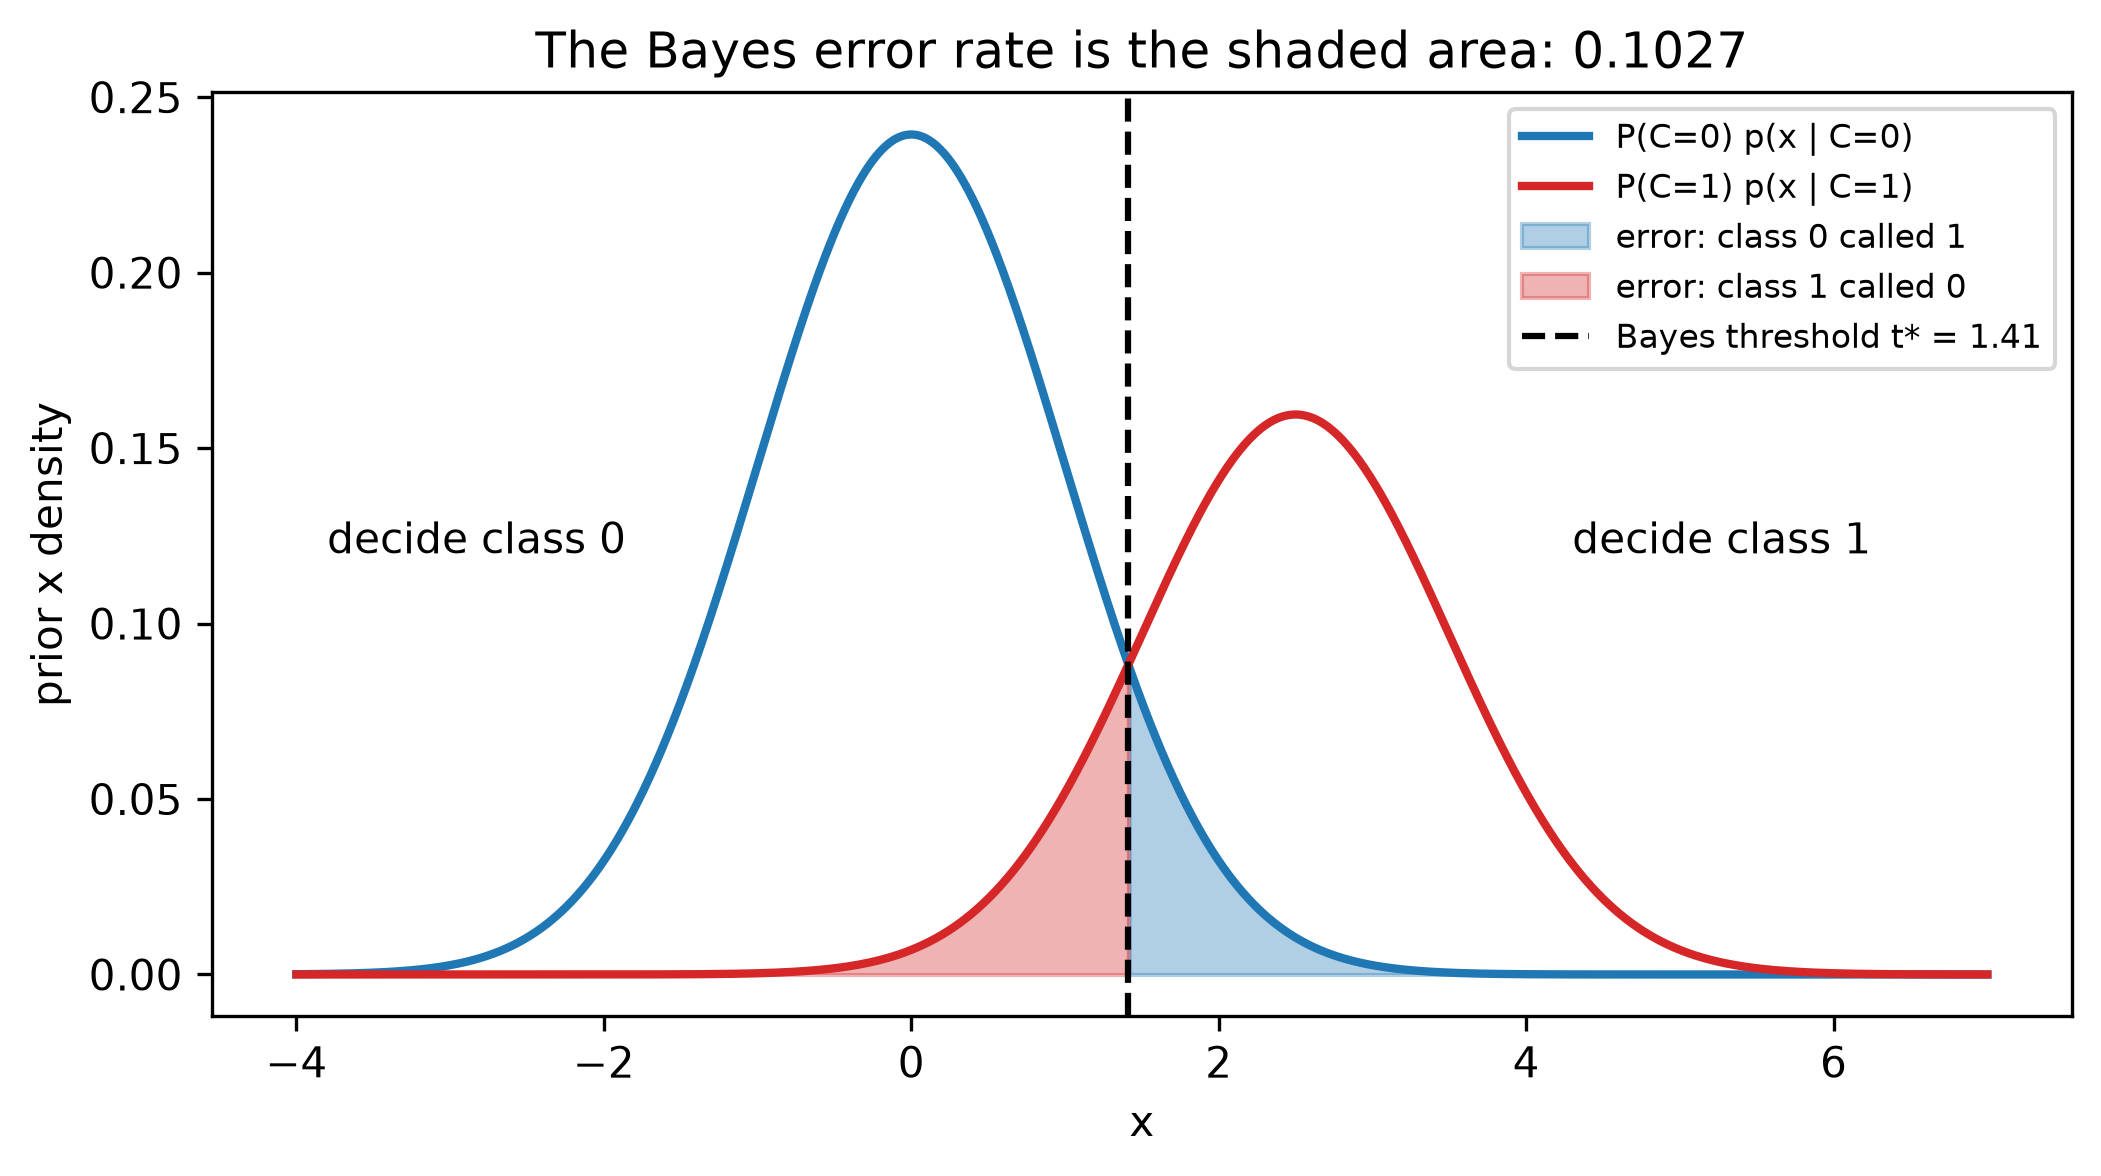

In [40]:
overlap = np.minimum(weighted_0, weighted_1)              # the shorter of the two curves at every x
bayes_error_1d = np.trapezoid(overlap, x_grid)            # area under it: the Bayes error rate

right_of_t = x_grid > t_bayes                             # boolean mask: the region where we decide class 1
error_from_class_0 = np.trapezoid(weighted_0 * right_of_t, x_grid)     # class 0 mass that we call 1
error_from_class_1 = np.trapezoid(weighted_1 * ~right_of_t, x_grid)    # class 1 mass that we call 0

print(f"Bayes error rate (area of the overlap)         = {bayes_error_1d:.4f}")
print(f"  class-0 points called 1  (blue shaded area)  = {error_from_class_0:.4f}")
print(f"  class-1 points called 0  (red shaded area)   = {error_from_class_1:.4f}")
print(f"  sum of the two pieces                        = {error_from_class_0 + error_from_class_1:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_grid, weighted_0, color="tab:blue", lw=2, label="P(C=0) p(x | C=0)")
ax.plot(x_grid, weighted_1, color="tab:red", lw=2, label="P(C=1) p(x | C=1)")
ax.fill_between(x_grid, 0, weighted_0, where=right_of_t,              # shade class 0 to the right of t*
                color="tab:blue", alpha=0.35, label="error: class 0 called 1")
ax.fill_between(x_grid, 0, weighted_1, where=~right_of_t,             # shade class 1 to the left of t*
                color="tab:red", alpha=0.35, label="error: class 1 called 0")
ax.axvline(t_bayes, color="black", ls="--", lw=1.5, label=f"Bayes threshold t* = {t_bayes:.2f}")
ax.text(-3.8, 0.12, "decide class 0", fontsize=10)          # label the two decision regions
ax.text(4.3, 0.12, "decide class 1", fontsize=10)
ax.set_xlabel("x")
ax.set_ylabel("prior x density")
ax.set_title(f"The Bayes error rate is the shaded area: {bayes_error_1d:.4f}")
ax.legend(fontsize=8, loc="upper right")
plt.show()

**Line by line**

- `np.minimum(weighted_0, weighted_1)` : the **elementwise** minimum of two arrays. Do not confuse it with
  `np.min`, which returns the single smallest number in one array. `np.minimum(a, b)` compares `a[i]` with `b[i]`
  for every `i` and keeps the smaller one, so the result is a whole curve: the lower envelope of the two.
- `np.trapezoid(overlap, x_grid)` : the area under that envelope, using the trapezoidal rule from Practical 2.
  **This single number is the Bayes error rate.**
- `weighted_0 * right_of_t` : multiplying a float array by a boolean array turns `True` into 1 and `False` into
  0, so the curve is kept on the right of $t^*$ and set to zero on the left. Integrating the result gives the
  area of the blue shaded region only.
- `~right_of_t` : the `~` operator flips every `True` to `False` and vice versa, so this is the mask "left of
  $t^*$".
- `ax.fill_between(x, 0, y, where=mask)` : shades the region between the x-axis and the curve `y`, but only
  where `mask` is `True`. That is how the two error regions are coloured separately.
- `alpha=0.35` makes the shading semi-transparent so the curves remain visible.

**Reading the plot.** The Bayes error rate of this world is about **0.103**: even the perfect classifier,
knowing the true distributions, is wrong on roughly 1 point in 10. Look at the two shaded pieces: they sit on
either side of the dashed line and together they fill exactly the region underneath *both* curves. Where the
blue curve is taller, a point is more likely to be class 0, so calling it class 0 is the best we can do, and
the red area underneath is the unavoidable price of that choice.

Notice also that the two pieces are **not equal** (about 0.047 and 0.056). The Bayes rule does not try to
balance the two kinds of error; it minimises their **sum**.

### 2c. Checking the Bayes error rate by counting mistakes

The area above is a calculation. A good habit is to check every calculation with an experiment. Draw a
large sample from the world, apply the Bayes threshold, and simply count how often it is wrong. The fraction
of mistakes should be close to the area.

In [41]:
N_MC = 200_000                                                  # a very large sample: 200 000 points

y_mc = rng.choice([0, 1], size=N_MC, p=PRIOR_1D)                # step 1: classes from the prior
x_mc = rng.normal(MU_1D[y_mc], SIGMA_1D)                        # step 2: one Gaussian draw per point

pred_bayes_mc = (x_mc > t_bayes).astype(int)                    # the Bayes rule: class 1 if x > t*
error_mc = np.mean(pred_bayes_mc != y_mc)                       # fraction of mistakes
std_error = np.sqrt(error_mc * (1 - error_mc) / N_MC)           # how uncertain that fraction is

print(f"Bayes error rate by integration       : {bayes_error_1d:.4f}")
print(f"Bayes error rate by counting mistakes : {error_mc:.4f}   (+/- {std_error:.4f})")

Bayes error rate by integration       : 0.1027
Bayes error rate by counting mistakes : 0.1025   (+/- 0.0007)


**Line by line**

- `200_000` : Python allows underscores inside numbers purely for readability. `200_000` is the same as
  `200000`.
- `rng.normal(MU_1D[y_mc], SIGMA_1D)` : a compact trick. `MU_1D[y_mc]` uses the 200 000 labels as **indices**
  into the two-element array of means, producing an array of 200 000 means, one per point (0.0 for class 0,
  2.5 for class 1). `rng.normal` then draws one value around each of them. This replaces the
  `for c in (0, 1)` loop with masks used in Practical 2.
- `(x_mc > t_bayes).astype(int)` : a boolean array (`True` where $x > t^*$) converted to 0s and 1s. That is a
  complete classifier in one line.
- `np.mean(pred != y)` : the fraction of mistakes, i.e. the **error rate**. Counting and dividing again.
- `std_error` : the **standard error** of an estimated proportion, $\sqrt{p(1-p)/n}$. It tells you how much the
  counted error rate would wobble if you repeated the experiment with a fresh sample. Two estimates that differ
  by less than about two standard errors are consistent with each other.

**Reading the output.** The counted error rate lands within about one standard error of the integral. Two
completely different methods, one mathematical and one experimental, agree. This "calculate, then check by
simulation" pattern is used for every result in the rest of the practical.

### 2d. No other threshold does better

The claim of decision theory is that $t^*$ is **optimal**: every other rule has a larger error rate. We can
test that claim directly. For a one-feature problem, every sensible rule is "decide 1 if $x > t$" for some
threshold $t$. So try hundreds of thresholds, count the mistakes of each on the big sample, and see where the
error curve bottoms out.

best threshold found by brute force : 1.430   error = 0.1022
Bayes threshold t* (the formula)    : 1.412   error = 0.1025
ML threshold (ignores the prior)    : 1.250   error = 0.1053


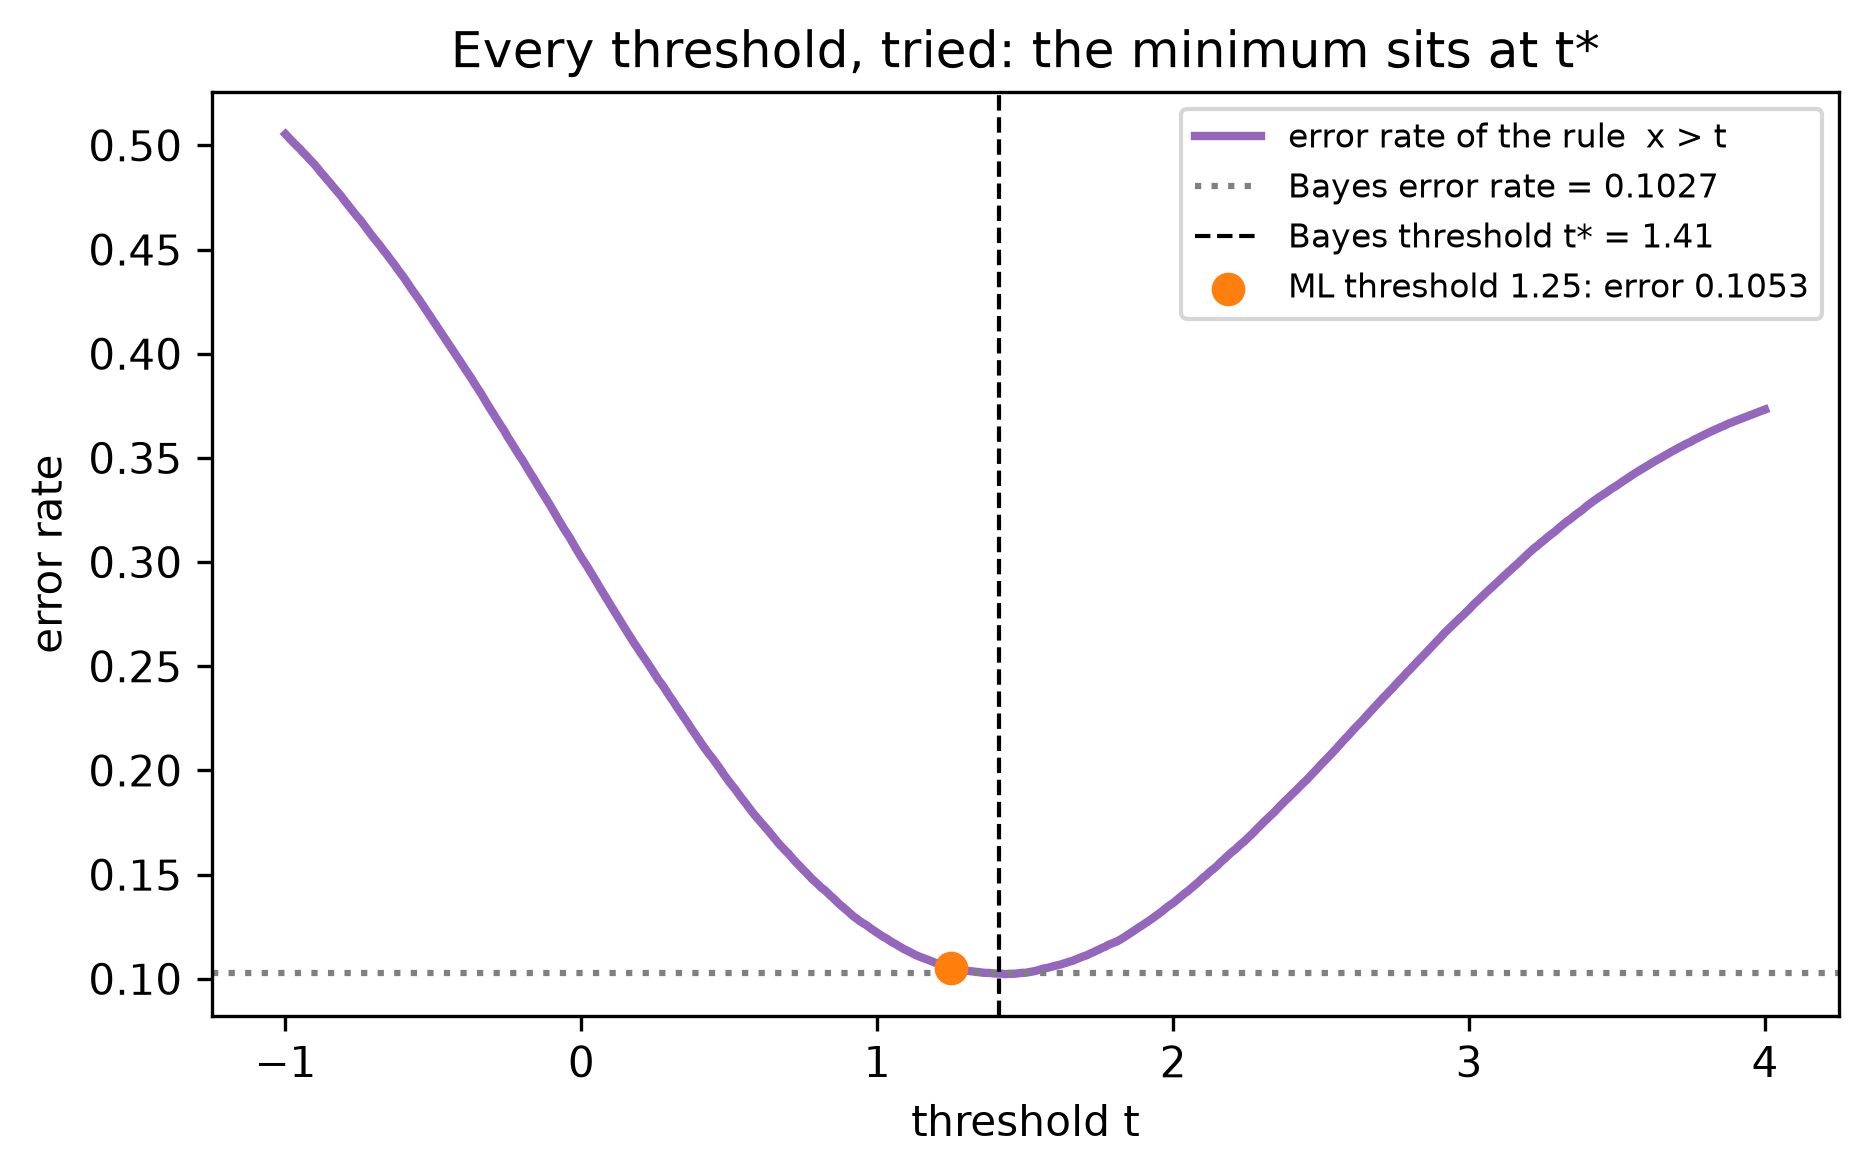

In [42]:
thresholds = np.linspace(-1.0, 4.0, 501)                         # 501 candidate thresholds to try

error_of_threshold = np.array([                                  # one error rate per threshold
    np.mean((x_mc > t).astype(int) != y_mc)                      # apply rule "x > t" and count mistakes
    for t in thresholds
])

best_t = thresholds[np.argmin(error_of_threshold)]               # threshold with the fewest mistakes
error_at_ml = np.mean((x_mc > t_ml).astype(int) != y_mc)         # the maximum-likelihood threshold

print(f"best threshold found by brute force : {best_t:.3f}   error = {error_of_threshold.min():.4f}")
print(f"Bayes threshold t* (the formula)    : {t_bayes:.3f}   error = {error_mc:.4f}")
print(f"ML threshold (ignores the prior)    : {t_ml:.3f}   error = {error_at_ml:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, error_of_threshold, color="tab:purple", lw=2, label="error rate of the rule  x > t")
ax.axhline(bayes_error_1d, color="grey", ls=":", label=f"Bayes error rate = {bayes_error_1d:.4f}")
ax.axvline(t_bayes, color="black", ls="--", lw=1, label=f"Bayes threshold t* = {t_bayes:.2f}")
ax.scatter([t_ml], [error_at_ml], color="tab:orange", zorder=3, s=50,
           label=f"ML threshold {t_ml:.2f}: error {error_at_ml:.4f}")
ax.set_xlabel("threshold t")
ax.set_ylabel("error rate")
ax.set_title("Every threshold, tried: the minimum sits at t*")
ax.legend(fontsize=8)
plt.show()

**Line by line**

- `np.linspace(-1.0, 4.0, 501)` : 501 evenly spaced thresholds, from well left of class 0's mean to well right
  of class 1's.
- The list comprehension builds and scores one classifier per threshold. Each `np.mean(... != y_mc)` is the
  same mistake-counting line as in 2c, repeated 501 times.
- `thresholds[np.argmin(error_of_threshold)]` : `argmin` gives the *position* of the smallest error; using it
  as an index into `thresholds` gives the threshold *value* at that position.
- `zorder=3` : draws the orange dot on top of the lines instead of underneath them.

**Reading the plot.** The error curve is a valley. Far to the left we call almost everything class 1 and the
error rate approaches $P(C=0) = 0.6$; far to the right we call everything class 0 and it approaches
$P(C=1) = 0.4$. The bottom of the valley sits at $t^*$ (the brute-force search lands within a few hundredths
of it; the valley is very flat at the bottom, so sampling noise decides the exact grid point) and its height is
the Bayes error rate. **This is decision theory verified by experiment: no threshold beats the Bayes
threshold.**

A careful reader will spot that the brute-force winner's error (0.1022) is a hair *below* the error of $t^*$
on the same sample (0.1025). That is not a contradiction. The brute-force threshold was *chosen* on this very
sample, so it has been tuned to this sample's random quirks; on a fresh sample it would lose that tiny
advantage. Choosing something on the data and then measuring it on the same data always flatters it a little.
Hold on to that idea: it returns in a much bigger way in Part 5.

The maximum-likelihood threshold is only slightly worse here, because the prior is only mildly unequal
(0.6 versus 0.4). The flatness of the valley near its bottom is worth remembering: small mistakes in the
threshold cost very little, large ones cost a lot.

---
## Part 3: The Bayes classifier in two dimensions, and real classifiers against it

With two features the decision rule becomes a **boundary**: a curve that splits the plane into a region where
we say class 0 and a region where we say class 1. This part draws the Bayes boundary, computes the Bayes error
rate, and then trains three ordinary classifiers on a small sample to see how close they get.

### 3a. The world: two Gaussian classes with different shapes

The generative story is the same two steps as before, but each class now produces a **2-D point** from a
**multivariate Gaussian**. A 2-D Gaussian is described by a mean vector (its centre) and a $2 \times 2$
**covariance matrix** (its shape):

$$\Sigma = \begin{bmatrix} \text{var}(x_1) & \text{cov}(x_1, x_2) \\ \text{cov}(x_1, x_2) & \text{var}(x_2) \end{bmatrix}$$

The diagonal entries say how spread out the cloud is along each axis. The off-diagonal entry says whether the
cloud is **tilted**: positive means "when $x_1$ is large, $x_2$ tends to be large too", negative means the
opposite.

We make the two classes deliberately different: class 0 is a **small, tight** cloud and class 1 is a
**large, wide** cloud that surrounds it and leans the other way. That difference in shape is what will make the
Bayes boundary curved.

In [43]:
PRIORS = np.array([0.6, 0.4])                    # true P(C=0), P(C=1)

MEANS = [np.array([0.0, 0.0]),                   # true centre of class 0
         np.array([1.5, 1.0])]                   # true centre of class 1

COVS = [np.array([[0.5, 0.2],                    # class 0: small variances, slight positive tilt
                  [0.2, 0.5]]),
        np.array([[2.5, -0.6],                   # class 1: large variances, negative tilt
                  [-0.6, 2.0]])]

CLASS_COLORS = ["tab:blue", "tab:red"]           # one colour per class, used in every plot below


def sample_world(n, priors=PRIORS, means=MEANS, covs=COVS):
    '''Draw n labelled points from a two-class Gaussian world: first the class, then the features.'''
    y = rng.choice([0, 1], size=n, p=priors)             # step 1: n class labels from the prior
    X = np.empty((n, 2))                                 # container for the n two-dimensional points
    for c in (0, 1):                                     # fill in one class at a time
        mask = y == c                                    # boolean array: rows that belong to class c
        X[mask] = rng.multivariate_normal(means[c], covs[c], size=mask.sum())   # step 2: features given class
    return X, y


X_train, y_train = sample_world(200)             # a small, realistic training set
X_test, y_test = sample_world(50_000)            # a huge test set, used ONLY to measure error rates

print("training set :", X_train.shape, " class counts:", np.bincount(y_train))
print("test set     :", X_test.shape, " class counts:", np.bincount(y_test))
print("\nfirst 5 training points:")
pd.DataFrame({"x1": X_train[:5, 0], "x2": X_train[:5, 1], "class": y_train[:5]})

training set : (200, 2)  class counts: [120  80]
test set     : (50000, 2)  class counts: [30185 19815]

first 5 training points:


,x1,x2,class
0,-0.6241,-0.3275,0
1,3.9447,0.6297,1
2,-0.2397,-0.5697,0
3,-0.2431,-0.0625,0
4,4.2256,-0.1081,1


**Line by line**

- `PRIORS`, `MEANS`, `COVS` : the true parameters of the 2-D world. `MEANS` and `COVS` are Python **lists**
  with one entry per class, so `MEANS[1]` is the centre of class 1 and `COVS[1]` its covariance matrix.
- Every covariance matrix must be **symmetric** (the two off-diagonal entries equal) and **positive definite**
  (roughly: every direction has a positive spread). Both of ours are. An invalid covariance matrix makes
  `multivariate_normal` complain.
- `def sample_world(n, priors=PRIORS, means=MEANS, covs=COVS)` : the three extra arguments have **default
  values**, so `sample_world(200)` uses the true world, while `sample_world(200, covs=my_covs)` generates data
  from a different world. You will use that in Exercise 2.
- `rng.multivariate_normal(mean, cov, size=k)` : draws `k` points from a multivariate Gaussian and returns a
  `(k, 2)` array. It is the 2-D version of `rng.normal`.
- `X[mask] = ...` : writes those `k` rows into the positions that belong to class `c`, the same boolean-mask
  pattern as Part 0 of Practical 2.
- **Why two datasets of such different sizes?** The 200 training points are what a classifier is allowed to
  learn from, a realistic amount. The 50 000 test points are never used for training; they exist only so that
  every error rate we measure is precise. With 50 000 points the standard error of an error rate is about
  0.0014, so differences in the third decimal place are real and not noise.
- `np.bincount(y)` : counts how many 0s and how many 1s. The proportions should be close to 0.6 and 0.4.

### 3b. The multivariate Gaussian density

To run the Bayes classifier we need $p(x \mid c)$ for a 2-D point $x$. The formula generalises the 1-D
Gaussian by replacing "distance from the mean divided by the standard deviation" with the **Mahalanobis
distance**, which accounts for the spread *and* the tilt of the cloud:

$$p(x) = \frac{1}{(2\pi)^{d/2}\,|\Sigma|^{1/2}} \exp\!\Big(-\tfrac{1}{2}\underbrace{(x - \mu)^\top \Sigma^{-1} (x - \mu)}_{\text{squared Mahalanobis distance}}\Big)$$

Here $d = 2$ is the number of features, $|\Sigma|$ is the determinant of the covariance matrix (a measure of the
cloud's total area) and $\Sigma^{-1}$ is its inverse. As in Practical 2, we compute the **log** of the density
directly, because it never underflows:

$$\log p(x) = -\tfrac{1}{2}\Big(d \log(2\pi) + \log|\Sigma| + (x - \mu)^\top \Sigma^{-1} (x - \mu)\Big)$$

In [44]:
def log_mvn_pdf(X, mean, cov):
    '''log of the multivariate Gaussian density N(mean, cov), evaluated at every row of X.

    X    : (n, d) array of points, one point per row
    mean : (d,)   centre of the Gaussian
    cov  : (d, d) covariance matrix
    returns (n,) array: log p(x) for every row
    '''
    d = len(mean)                                        # number of features (2 in this practical)
    diff = X - mean                                      # (n, d): every point minus the centre
    cov_inv = np.linalg.inv(cov)                         # (d, d): inverse of the covariance matrix
    mahal_sq = np.sum((diff @ cov_inv) * diff, axis=1)   # (n,): squared Mahalanobis distance of every row
    log_det = np.log(np.linalg.det(cov))                 # log |cov|: larger for more spread-out clouds
    return -0.5 * (d * np.log(2.0 * np.pi) + log_det + mahal_sq)


# check 1: with d = 1 the formula must agree with the 1-D gaussian_pdf from Part 2
x_check = np.array([[-1.0], [0.5], [2.0]])               # three 1-D points, shaped (3, 1)
print("1-D check, log_mvn_pdf  :", log_mvn_pdf(x_check, np.array([0.5]), np.array([[4.0]])))
print("1-D check, gaussian_pdf :", np.log(gaussian_pdf(x_check[:, 0], 0.5, 2.0)))

# check 2: a density must integrate to 1 over the whole plane
g = np.linspace(-9, 11, 500)                             # a wide grid along each axis
G1, G2 = np.meshgrid(g, g)                               # two (500, 500) coordinate arrays
grid_points = np.column_stack([G1.ravel(), G2.ravel()])  # (250000, 2): every grid point as a row
cell_area = (g[1] - g[0]) ** 2                           # area of one small square of the grid
for c in (0, 1):
    total = np.exp(log_mvn_pdf(grid_points, MEANS[c], COVS[c])).sum() * cell_area
    print(f"class {c}: density summed over the plane = {total:.4f}")

1-D check, log_mvn_pdf  : [-1.8933 -1.6121 -1.8933]
1-D check, gaussian_pdf : [-1.8933 -1.6121 -1.8933]
class 0: density summed over the plane = 1.0000
class 1: density summed over the plane = 1.0000


**Line by line**

- `diff = X - mean` : `X` is `(n, 2)` and `mean` is `(2,)`, so broadcasting subtracts the centre from every
  row at once.
- `np.linalg.inv(cov)` : the matrix inverse $\Sigma^{-1}$. For a covariance matrix it always exists (that is
  what "positive definite" guarantees).
- `np.sum((diff @ cov_inv) * diff, axis=1)` : **the one tricky line**, worth reading slowly. For a single
  point the Mahalanobis term is $(x-\mu)^\top \Sigma^{-1} (x-\mu)$, a row vector times a matrix times a column
  vector. For all `n` points at once:
  - `diff @ cov_inv` is `(n, 2) @ (2, 2) -> (n, 2)`: row `i` is $(x_i - \mu)^\top \Sigma^{-1}$.
  - `* diff` multiplies that elementwise by row `i` of `diff` again.
  - `np.sum(..., axis=1)` adds the two columns, finishing the dot product for every row.

  The result is one number per point: how far that point is from the centre, measured in "standard deviations"
  that respect the cloud's shape. Along the long axis of a stretched cloud a point can be far away in ordinary
  distance but close in Mahalanobis distance.
- `np.log(np.linalg.det(cov))` : the log-determinant. A wide cloud spreads its probability over a large area,
  so its density is lower everywhere; this term is how the formula accounts for that.
- **Check 1** : with one feature the covariance matrix is just $[\sigma^2]$, and the formula must collapse to the
  ordinary Gaussian. Note the variance `4.0` in the first line corresponds to a standard deviation of `2.0` in
  the second line. The two printed rows agree.
- **Check 2** : `np.meshgrid` and `.ravel()` are the "flatten, compute, reshape" recipe from Practical 2. The
  sum of the density times the area of each little grid square approximates the integral over the plane. It
  comes out as 1.0000 for both classes, so the density is correctly normalised.

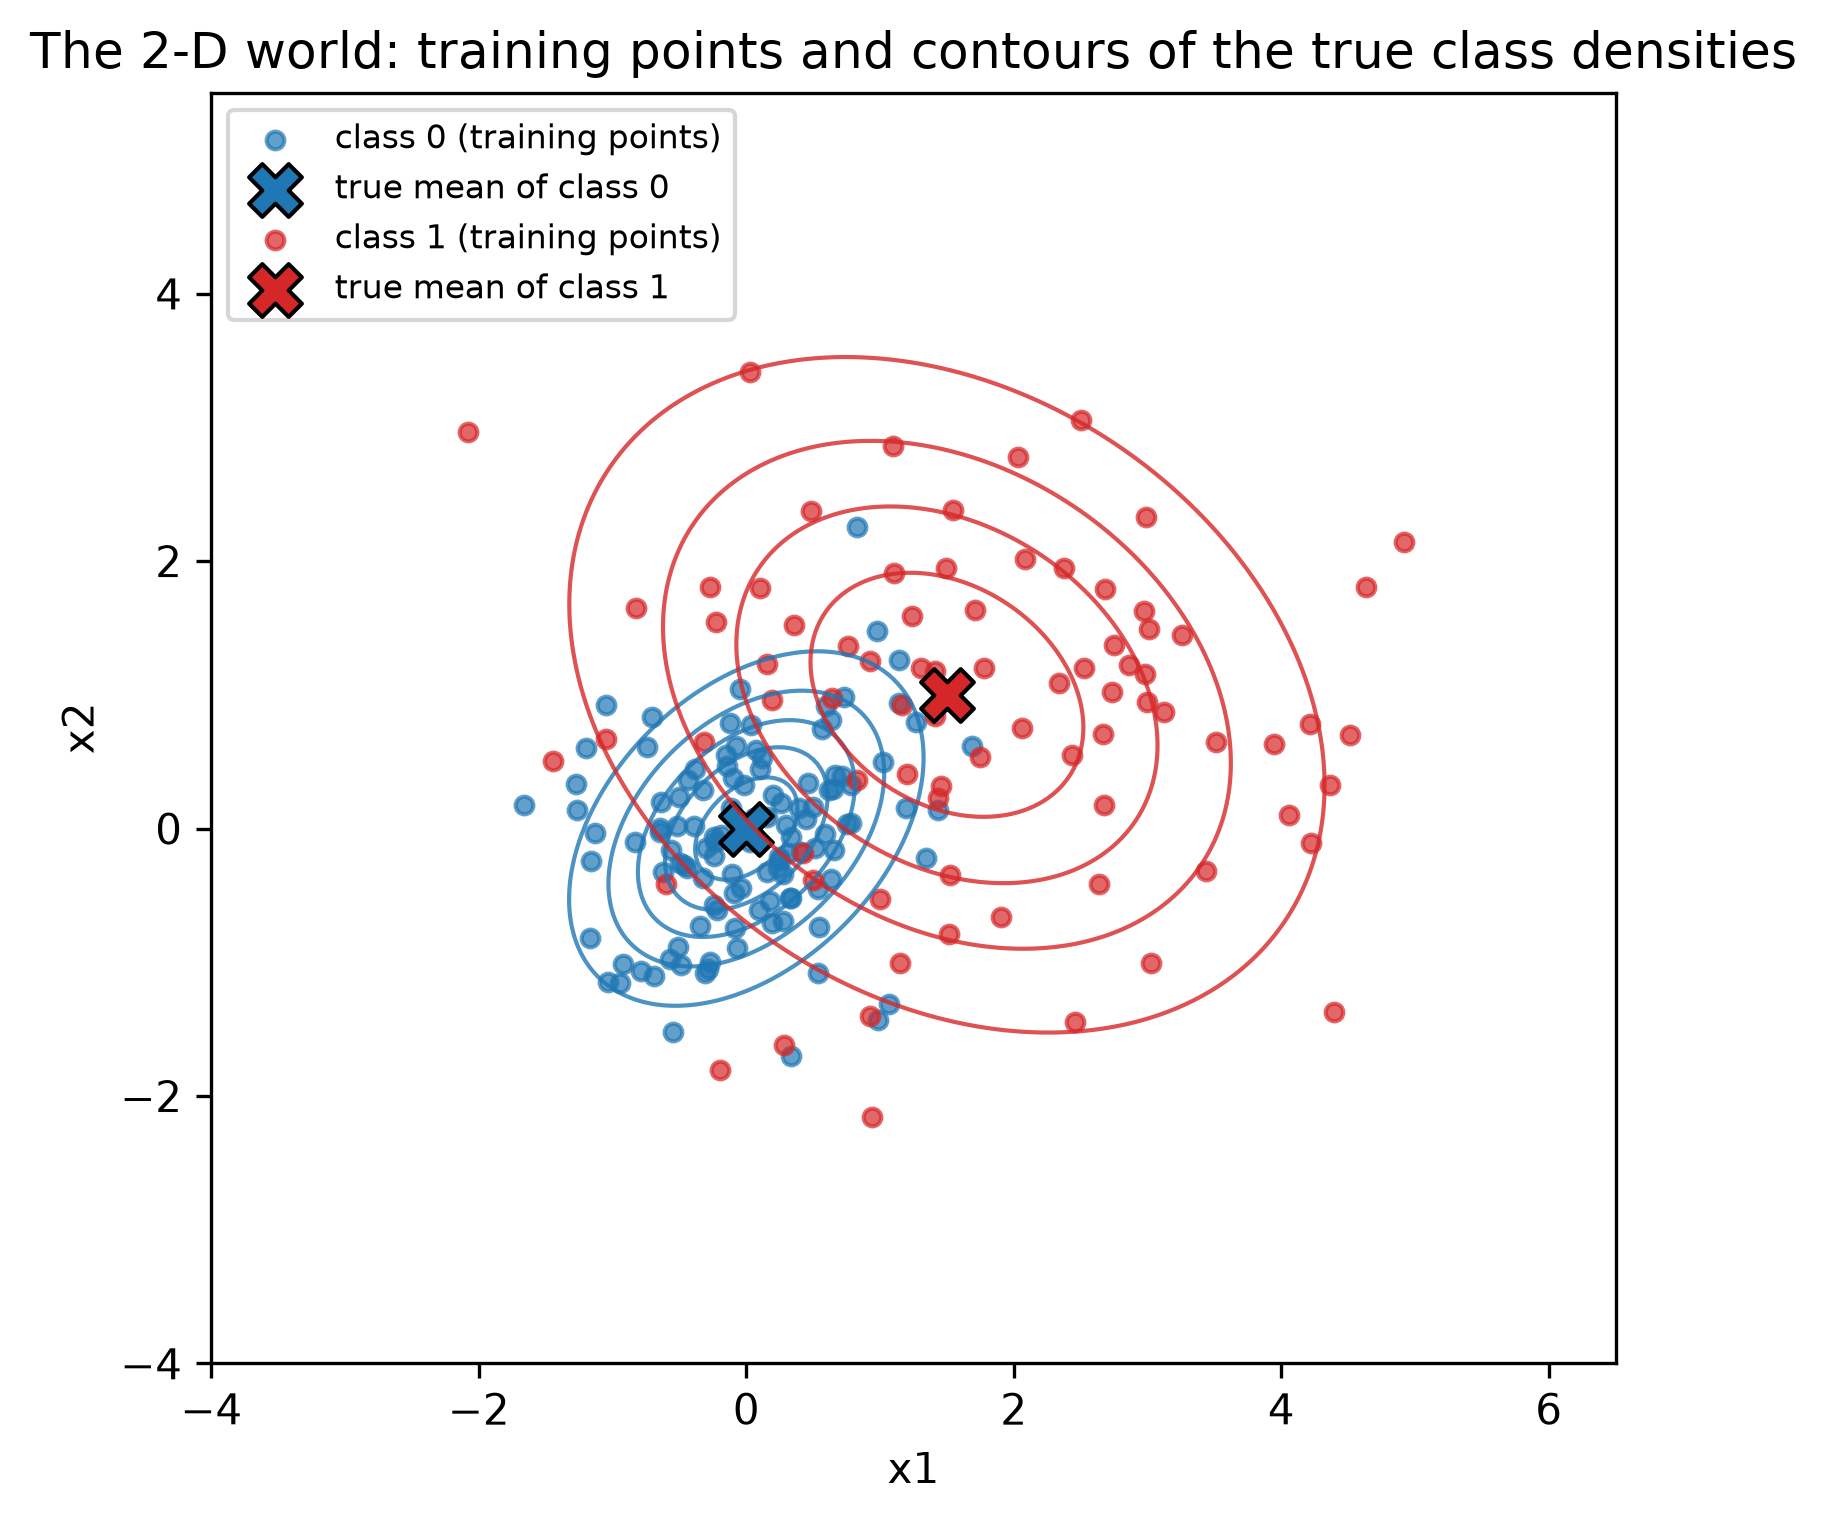

In [45]:
fig, ax = plt.subplots(figsize=(7, 5.5))

plot_g1 = np.linspace(-4, 6.5, 300)                            # plotting window along x1
plot_g2 = np.linspace(-4, 5.5, 300)                            # plotting window along x2
P1, P2 = np.meshgrid(plot_g1, plot_g2)                         # (300, 300) coordinate arrays
plot_points = np.column_stack([P1.ravel(), P2.ravel()])        # (90000, 2) list of points

for c in (0, 1):
    dens = np.exp(log_mvn_pdf(plot_points, MEANS[c], COVS[c])).reshape(P1.shape)   # back to (300, 300)
    ax.contour(P1, P2, dens, levels=5, colors=CLASS_COLORS[c], linewidths=1, alpha=0.8)
    ax.scatter(X_train[y_train == c, 0], X_train[y_train == c, 1],
               color=CLASS_COLORS[c], s=18, alpha=0.7, label=f"class {c} (training points)")
    ax.scatter(*MEANS[c], color=CLASS_COLORS[c], marker="X", s=160, edgecolor="black",
               label=f"true mean of class {c}")

ax.set_xlim(plot_g1[0], plot_g1[-1])                           # keep the view on the plotting window
ax.set_ylim(plot_g2[0], plot_g2[-1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("The 2-D world: training points and contours of the true class densities")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
plt.show()

**Line by line**

- The meshgrid block is the same recipe as the integration check, over a smaller window chosen to frame the
  data.
- `.reshape(P1.shape)` : folds the flat vector of 90 000 densities back into a `(300, 300)` grid so that
  `contour` can draw it.
- `ax.contour(P1, P2, dens, levels=5, ...)` : draws 5 **contour lines**, lines of equal density, like height
  lines on a map. For a Gaussian they are ellipses.
- `X_train[y_train == c, 0]` : rows of class `c`, column 0 (that is, $x_1$). The two-part index from
  Practical 2.
- `ax.scatter(*MEANS[c], ...)` : the `*` **unpacks** the two-element array into two separate arguments, so it
  is the same as `ax.scatter(MEANS[c][0], MEANS[c][1], ...)`.
- `ax.set_xlim(...)` and `ax.set_ylim(...)` : fix the visible window. Without them matplotlib stretches the axes
  to fit every point, and one training point that happens to land far out would leave an empty strip.
- `ax.set_aspect("equal")` : one unit on the x-axis is drawn the same length as one unit on the y-axis.
  Without it, circles look like ellipses and tilts look wrong.

**Reading the plot.** The blue ellipses are small and tilted up-right; the red ones are large and tilted
down-right. Most red points lie away from the blue cloud, but some land right in the middle of it. Those points
are the reason the Bayes error rate cannot be zero.

### 3c. The Bayes decision rule and the Bayes decision boundary

The Bayes classifier is the MAP rule from Practical 2, applied with the **true** parameters:

$$h^*(x) = \arg\max_{c}\; \big[\log P(c) + \log p(x \mid c)\big]$$

We write it as a function that takes the parameters as arguments. That design choice pays off in 3e: a
classifier *trained* on data can then use exactly the same function, with estimated parameters in place of the
true ones.

In [46]:
def gaussian_class_scores(X, priors, means, covs):
    '''Un-normalised log posterior, log P(c) + log p(x | c), for every row of X and both classes.

    returns an (n, 2) array: column c holds the score of class c
    '''
    return np.column_stack([
        np.log(priors[c]) + log_mvn_pdf(X, means[c], covs[c])       # log prior + log likelihood
        for c in (0, 1)
    ])


def scores_to_posterior(scores):
    '''Turn (n, 2) log scores into proper posteriors with the log-sum-exp trick from Practical 2.'''
    shifted = scores - scores.max(axis=1, keepdims=True)            # largest entry in each row becomes 0
    unnormalised = np.exp(shifted)                                  # safe: no exponent is ever positive
    return unnormalised / unnormalised.sum(axis=1, keepdims=True)   # every row now sums to 1


def bayes_classifier(X, priors=PRIORS, means=MEANS, covs=COVS):
    '''The Bayes optimal classifier under 0-1 loss: MAP with the TRUE prior and TRUE likelihoods.'''
    return gaussian_class_scores(X, priors, means, covs).argmax(axis=1)


scores_test = gaussian_class_scores(X_test, PRIORS, MEANS, COVS)    # (50000, 2)
posterior_test = scores_to_posterior(scores_test)                   # (50000, 2), rows sum to 1
pred_bayes_test = bayes_classifier(X_test)                          # (50000,), each entry 0 or 1

pd.DataFrame({
    "x1": X_test[:6, 0],
    "x2": X_test[:6, 1],
    "P(C=0|x)": posterior_test[:6, 0],
    "P(C=1|x)": posterior_test[:6, 1],
    "Bayes decision": pred_bayes_test[:6],
    "true class": y_test[:6],
})

,x1,x2,P(C=0|x),P(C=1|x),Bayes decision,true class
0,0.3918,0.3040,0.9063,0.0937,0,0
1,0.6609,0.0680,0.8762,0.1238,0,0
2,-0.4394,-0.2852,0.9652,0.0348,0,0
3,-0.1427,-0.0184,0.9529,0.0471,0,0
4,-0.7084,0.4665,0.8872,0.1128,0,1
5,1.2662,-0.4391,0.4747,0.5253,1,0


**Line by line**

- `np.column_stack([... for c in (0, 1)])` : computes one column of scores per class and glues the two columns
  side by side into an `(n, 2)` array. The same structure as `joint_log_score` in Practical 2, written more
  compactly.
- `np.log(priors[c]) + log_mvn_pdf(...)` : **addition, because we are in log space**. In probability space this
  would be prior *times* likelihood.
- `scores_to_posterior` : copied from Practical 2. Subtracting the row maximum before `np.exp` prevents overflow
  and does not change the ratios.
- `bayes_classifier` : one line. `argmax(axis=1)` picks, for every row, the column (class) with the larger
  score. The evidence $p(x)$ is never computed, because it is the same for both classes and cannot change which
  one is larger.
- The defaults `priors=PRIORS, means=MEANS, covs=COVS` mean that `bayes_classifier(X)` is the Bayes classifier of
  *our* world, but you can pass a different world's parameters in the exercises.

**Reading the table.** Most rows have one posterior close to 1, and there the Bayes decision is almost
certainly right. Rows where both posteriors are in the middle (say 0.3 to 0.7) are points in the overlap
region. The Bayes classifier still picks the more probable class, but it will be wrong on a sizeable fraction
of such points, and that is unavoidable.

Two of these six rows are already mistakes, and they are mistakes of two different kinds. Row 4 is a class-1
point that landed deep inside the blue cloud: the posterior says 89% class 0, and the Bayes classifier bets on
the 89%. Row 5 is almost a coin toss (0.47 against 0.53) that happened to go the less likely way. **Neither is
a flaw in the classifier.** Betting on the more probable outcome is still the best strategy even when the bet
sometimes loses.

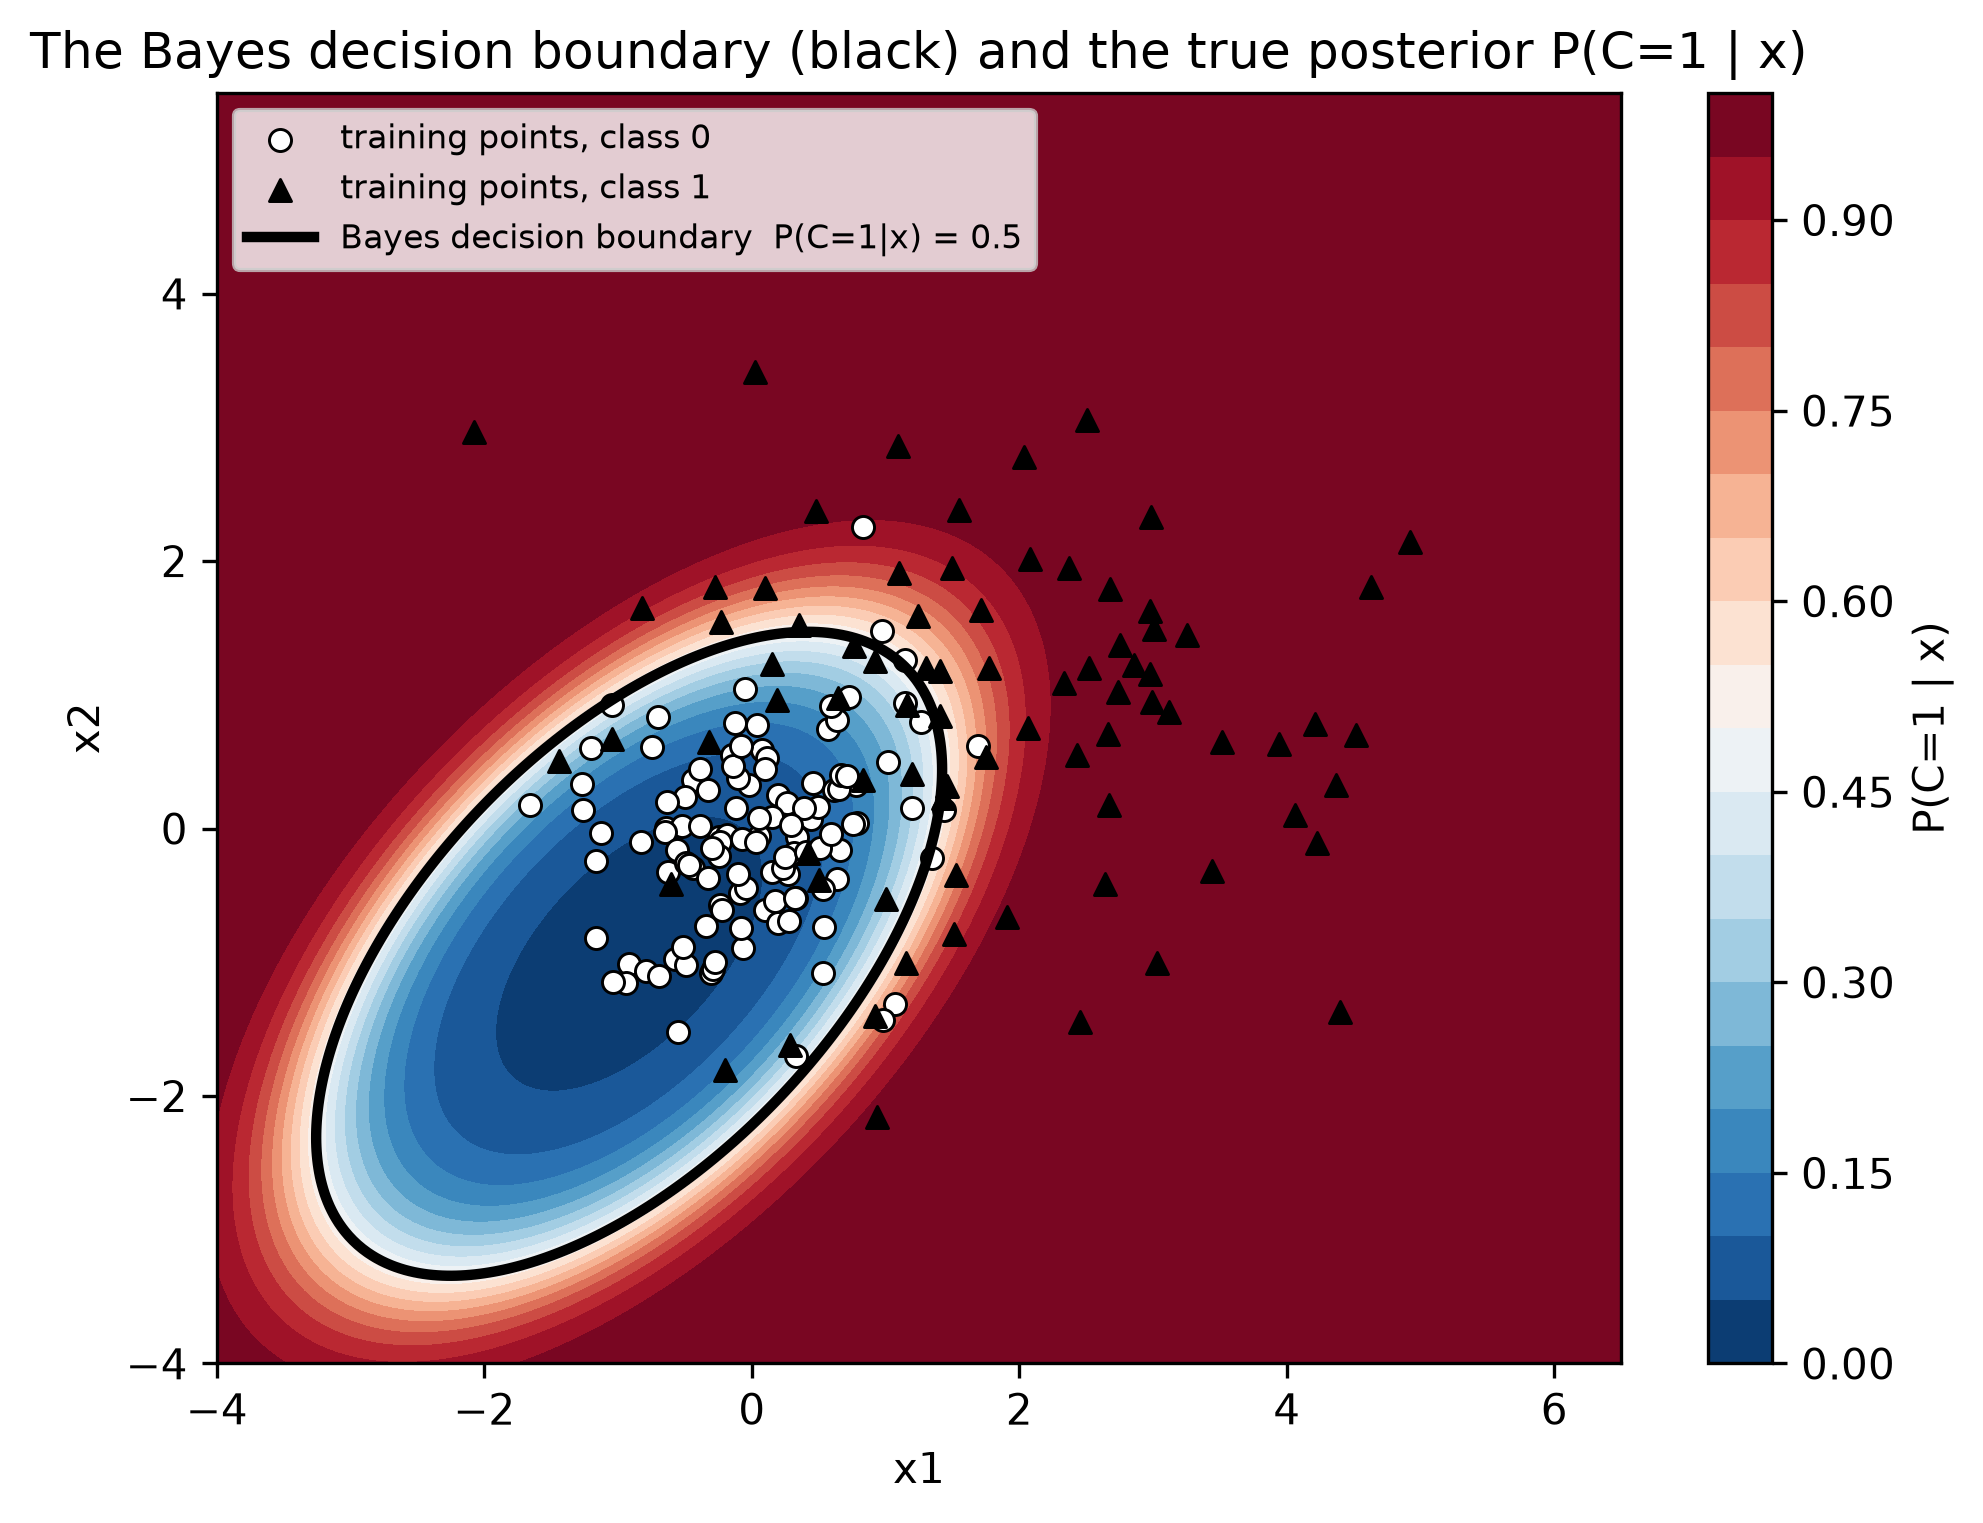

In [47]:
post_grid = scores_to_posterior(gaussian_class_scores(plot_points, PRIORS, MEANS, COVS))[:, 1]
post_grid = post_grid.reshape(P1.shape)                         # P(C=1 | x) on the (300, 300) grid

fig, ax = plt.subplots(figsize=(7.5, 5.5))
filled = ax.contourf(P1, P2, post_grid, levels=20, cmap="RdBu_r", vmin=0, vmax=1)   # colour = P(C=1 | x)
ax.contour(P1, P2, post_grid, levels=[0.5], colors="black", linewidths=2.5)       # the Bayes boundary

for c, marker in ((0, "o"), (1, "^")):
    keep = y_train == c
    ax.scatter(X_train[keep, 0], X_train[keep, 1], marker=marker, facecolor="white" if c == 0 else "black",
               edgecolor="black", s=28, linewidth=0.7, label=f"training points, class {c}")

ax.plot([], [], color="black", lw=2.5, label="Bayes decision boundary  P(C=1|x) = 0.5")   # legend entry only
ax.set_xlim(plot_g1[0], plot_g1[-1])
ax.set_ylim(plot_g2[0], plot_g2[-1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("The Bayes decision boundary (black) and the true posterior P(C=1 | x)")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
plt.colorbar(filled, ax=ax, label="P(C=1 | x)", fraction=0.04)
plt.show()

**Line by line**

- `[:, 1]` : keeps only the second column of the posterior, $P(C=1 \mid x)$, one number per grid point.
- `ax.contourf(..., cmap="RdBu_r", vmin=0, vmax=1)` : **filled** contours, colouring the plane by the true
  posterior: deep blue where class 0 is almost certain, deep red where class 1 is, white where it is a coin
  toss. `vmin` and `vmax` pin the colour scale to the full range 0 to 1.
- `ax.contour(..., levels=[0.5])` : one single line where the posterior equals 0.5. On one side class 1 is more
  probable, on the other side class 0 is. **That line is the Bayes decision boundary.**
- `facecolor="white" if c == 0 else "black"` : a conditional expression, so class 0 is drawn as white circles
  and class 1 as black triangles. Shape and fill stay readable on top of a strongly coloured background.
- `ax.plot([], [], ...)` : plots nothing, but creates a legend entry for the boundary, because `contour` lines
  do not appear in the legend automatically.

**Reading the plot.** The Bayes boundary is a **closed ellipse** around class 0, not a straight line. Inside
the ellipse class 0 wins; everywhere outside it, class 1 wins, even in the far bottom-left corner, which is
nowhere near class 1's centre. Why? Class 0 is a *tight* cloud, so its density falls off very quickly, while
class 1 is *wide* and still has some density far away. Far enough from the centre, the wide class always wins.

The curve appears because the two classes have **different covariance matrices**: the $x^\top \Sigma_c^{-1} x$
terms in the two log scores do not cancel, so the boundary is a quadratic curve. With equal covariance matrices
they would cancel and the boundary would be a straight line; that is the heart of Exercise 2.

Keep the shape of this boundary in mind. A classifier that can only draw straight lines has no hope of
reproducing it.

### 3d. The Bayes error rate, computed three ways

**Way 1: integrate the overlap.** The 1-D formula carries over unchanged, with an area integral instead of a
length integral:

$$R^* = \iint \min\big(P(C=0)\,p(x \mid 0),\; P(C=1)\,p(x \mid 1)\big)\, dx_1\, dx_2$$

**Way 2: count mistakes.** Apply the Bayes classifier to the 50 000 test points and count how many it gets
wrong.

**Way 3: average the posterior.** At a point $x$ the Bayes classifier picks the class with the larger
posterior, so the probability that it is wrong *at that point* is $1 - \max_c P(c \mid x)$. Averaging that over
many points drawn from the world gives the error rate, **without looking at a single label**:

$$R^* = E_X\big[1 - \max_c P(c \mid X)\big]$$

In [48]:
def bayes_error_by_integration(priors, means, covs, lo=-12.0, hi=14.0, n_grid=700):
    '''Bayes error rate of a two-class Gaussian world: the integral of min(prior x density) over the plane.'''
    g = np.linspace(lo, hi, n_grid)                              # grid along each axis
    G1, G2 = np.meshgrid(g, g)
    pts = np.column_stack([G1.ravel(), G2.ravel()])             # every grid point as a row
    area = (g[1] - g[0]) ** 2                                   # area of one grid square
    w0 = priors[0] * np.exp(log_mvn_pdf(pts, means[0], covs[0]))   # P(C=0) p(x | 0) at every point
    w1 = priors[1] * np.exp(log_mvn_pdf(pts, means[1], covs[1]))   # P(C=1) p(x | 1) at every point
    return np.minimum(w0, w1).sum() * area                      # area under the lower envelope


bayes_err_integral = bayes_error_by_integration(PRIORS, MEANS, COVS)          # way 1
bayes_err_counted = np.mean(pred_bayes_test != y_test)                        # way 2
bayes_err_posterior = np.mean(1.0 - posterior_test.max(axis=1))               # way 3

se = np.sqrt(bayes_err_counted * (1 - bayes_err_counted) / len(y_test))      # standard error of way 2

print(f"way 1: integrate the overlap          R* = {bayes_err_integral:.4f}")
print(f"way 2: count mistakes on the test set R* = {bayes_err_counted:.4f}   (+/- {se:.4f})")
print(f"way 3: average of 1 - max posterior   R* = {bayes_err_posterior:.4f}")

BAYES_ERROR = bayes_err_integral        # the exact value, kept for every comparison below

way 1: integrate the overlap          R* = 0.1171
way 2: count mistakes on the test set R* = 0.1180   (+/- 0.0014)
way 3: average of 1 - max posterior   R* = 0.1173


**Line by line**

- `bayes_error_by_integration(...)` : Way 1 packed into a function so that the exercises can reuse it on
  other worlds. The grid runs from -12 to 14, far enough out to catch essentially all of the wide red cloud,
  and `n_grid=700` gives about 490 000 points.
- `np.minimum(w0, w1).sum() * area` : the 2-D version of `np.trapezoid(np.minimum(...))` from Part 2: the
  height of the lower envelope in each grid square times the square's area, added up.
- `np.mean(pred_bayes_test != y_test)` : Way 2, counting mistakes, exactly as in Part 2c.
- `posterior_test.max(axis=1)` : the larger of the two posteriors in every row, i.e. the probability that the
  Bayes decision is **right** at that point. One minus it is the probability that it is wrong. Way 3 never
  touches `y_test`.
- `BAYES_ERROR = ...` : the exact number is stored under a capitalised name because every classifier from now
  on will be compared against it.

**Reading the output.** Three different methods, one geometric, one experimental and one probabilistic, give
the same answer to within the standard error: this world has a Bayes error rate of about **0.117**. Roughly
one test point in nine will be misclassified *by the best possible classifier*, simply because some red points
land in the middle of the blue cloud.

That is the benchmark. Any trained classifier's test error will be compared to 0.117, and the difference is
called its **excess error**: the part of its mistakes that is the model's fault rather than the world's.

### 3e. Three trained classifiers

In real life we do not know `PRIORS`, `MEANS` and `COVS`; we only have the 200 training points. Here are three
ways to build a classifier from them, each representing a different philosophy.

| classifier | philosophy | boundary it can draw |
|---|---|---|
| **plug-in Gaussian** | estimate the prior, means and covariance matrices from the data, then apply the Bayes rule with the estimates "plugged in" | quadratic (ellipses, parabolas, hyperbolas) |
| **logistic regression** | Practical 1: a linear score $w \cdot x$ pushed through a sigmoid, fitted by gradient descent | a straight line only |
| **k-nearest neighbours** (k-NN) | no model at all: label a new point by a majority vote among the $k$ closest training points | any shape; $k$ controls how wiggly |

The plug-in Gaussian is the classifier from Practical 2, but with a full covariance matrix instead of naive
Bayes' independent features. In the literature it is called **quadratic discriminant analysis (QDA)**. It
assumes the *correct* family of distributions, so it has an unfair advantage: its only handicap is having to
estimate parameters from 200 points.

In [49]:
def fit_plugin_gaussian(X, y):
    '''Estimate the prior, the class means and the class covariance matrices from labelled data.'''
    priors_hat = np.bincount(y, minlength=2) / len(y)                          # count and divide
    means_hat = [X[y == c].mean(axis=0) for c in (0, 1)]                        # column means per class
    covs_hat = [np.cov(X[y == c], rowvar=False, bias=True) for c in (0, 1)]     # covariance per class
    return priors_hat, means_hat, covs_hat


params_hat = fit_plugin_gaussian(X_train, y_train)          # a tuple: (priors_hat, means_hat, covs_hat)
priors_hat, means_hat, covs_hat = params_hat                # unpack it into three names

print("               estimated              true")
print(f"prior        {priors_hat.round(3)}          {PRIORS}")
for c in (0, 1):
    print(f"mean  c={c}   {means_hat[c].round(3)}    {MEANS[c]}")
for c in (0, 1):
    print(f"cov   c={c}\n{covs_hat[c].round(3)}\n   true:\n{COVS[c]}")

               estimated              true
prior        [0.6 0.4]          [0.6 0.4]
mean  c=0   [ 0.021 -0.067]    [0. 0.]
mean  c=1   [1.824 0.798]    [1.5 1. ]
cov   c=0
[[0.423 0.107]
 [0.107 0.433]]
   true:
[[0.5 0.2]
 [0.2 0.5]]
cov   c=1
[[ 2.577 -0.197]
 [-0.197  1.421]]
   true:
[[ 2.5 -0.6]
 [-0.6  2. ]]


**Line by line**

- `np.bincount(y, minlength=2) / len(y)` : class counts divided by the total, i.e. the estimated prior.
  `minlength=2` guarantees two entries even in the unlucky case where a small sample contains no points of
  class 1.
- `X[y == c].mean(axis=0)` : keeps only the rows of class `c`, then averages down the rows, giving one mean per
  feature. The same pattern as Part 4c of Practical 2.
- `np.cov(A, rowvar=False, bias=True)` : the covariance matrix of the columns of `A`.
  - `rowvar=False` tells NumPy that **rows are samples and columns are features**, our convention since
    Practical 1. The default (`rowvar=True`) assumes the opposite and would return a 200 × 200 matrix, a very
    common bug.
  - `bias=True` divides by $n$ instead of $n - 1$, giving the maximum-likelihood estimate, the same choice as
    `ddof=0` in Practical 2.
- The function returns a **tuple** of three things; the second line unpacks it into three separate names.

**Reading the output.** The estimates land near the truth but are visibly off, especially the entries of class
1's covariance matrix (a wide cloud needs more data to pin down). With only 80 or so class-1 points that is
expected. **This estimation error is the only thing separating the plug-in classifier from the Bayes
classifier.**

In [50]:
def sigmoid(z):
    '''The logistic function: squashes any real number into the interval (0, 1).'''
    return 1.0 / (1.0 + np.exp(-z))


def fit_logistic(X, y, lr=0.5, epochs=3000):
    '''Logistic regression by gradient descent (Practical 1), with standardisation and a bias column.'''
    mu, sd = X.mean(axis=0), X.std(axis=0)                  # standardisation statistics of the TRAINING data
    Phi = np.column_stack([np.ones(len(X)), (X - mu) / sd]) # bias column + standardised features
    w = np.zeros(Phi.shape[1])                              # start from all-zero weights
    for _ in range(epochs):                                 # repeat the gradient step many times
        p = sigmoid(Phi @ w)                                # current predicted P(C=1 | x) for every row
        grad = Phi.T @ (p - y) / len(y)                     # gradient of the log-loss
        w -= lr * grad                                      # step downhill
    return w, mu, sd


def predict_logistic(X, model):
    '''Class predictions (0 or 1) from a fitted logistic model = (w, mu, sd).'''
    w, mu, sd = model                                       # unpack the three stored pieces
    Phi = np.column_stack([np.ones(len(X)), (X - mu) / sd]) # SAME transformation as in training
    return (sigmoid(Phi @ w) >= 0.5).astype(int)            # threshold the probability at 0.5


logistic_model = fit_logistic(X_train, y_train.astype(float))
print("logistic weights (bias, x1, x2):", logistic_model[0].round(3))

logistic weights (bias, x1, x2): [-0.415  1.988  0.885]


**Line by line**

- `sigmoid` and the gradient-descent loop are the ones from Practical 1, part 2b. Nothing new is happening
  inside them.
- `mu, sd = X.mean(axis=0), X.std(axis=0)` : standardisation, so both features are on the same scale and
  gradient descent converges quickly.
- `np.column_stack([np.ones(len(X)), (X - mu) / sd])` : the **bias trick** from Practical 1, gluing a column of
  ones in front of the standardised features.
- `return w, mu, sd` : the model is not just the weights. To predict on new data we must standardise it with
  the **training** mean and standard deviation, exactly the rule from "Putting it together" in Practical 1. So
  all three are returned together and `predict_logistic` unpacks them again.
- `y_train.astype(float)` : the gradient formula subtracts `y` from probabilities, so `y` should be a float
  array.

**What to notice.** Whatever the weights are, the decision boundary is the set of points where $w \cdot \phi(x) = 0$,
which is a **straight line** in the plane. Look back at the Bayes boundary: an ellipse. We already know,
before measuring anything, that logistic regression is going to lose.

In [51]:
def knn_predict(X_train, y_train, X_query, k):
    '''k-nearest-neighbour classifier: a majority vote among the k closest training points.'''
    sq_dist = (np.sum(X_query ** 2, axis=1)[:, None]        # ||q||^2 as a column       (m, 1)
               + np.sum(X_train ** 2, axis=1)[None, :]      # ||t||^2 as a row          (1, n)
               - 2.0 * X_query @ X_train.T)                 # -2 q.t for every pair     (m, n)
    nearest = np.argsort(sq_dist, axis=1)[:, :k]            # (m, k) indices of the k closest training points
    votes = y_train[nearest].mean(axis=1)                   # fraction of those neighbours that are class 1
    return (votes > 0.5).astype(int)                        # majority vote (k is odd, so no ties)


print("k-NN predictions for the first 6 test points, k = 15:", knn_predict(X_train, y_train, X_test[:6], 15))
print("true classes of those points                       :", y_test[:6])

k-NN predictions for the first 6 test points, k = 15: [0 0 0 0 0 0]
true classes of those points                       : [0 0 0 0 1 0]


**Line by line**

- **The squared-distance line** computes the squared Euclidean distance between *every* query point and
  *every* training point at once, using the identity $\lVert q - t \rVert^2 = \lVert q \rVert^2 + \lVert t \rVert^2 - 2\, q \cdot t$.
  - `np.sum(X_query ** 2, axis=1)[:, None]` : the squared length of each query point, shaped as a column
    `(m, 1)`.
  - `np.sum(X_train ** 2, axis=1)[None, :]` : the squared length of each training point, shaped as a row
    `(1, n)`.
  - `X_query @ X_train.T` : `(m, 2) @ (2, n) -> (m, n)`, all the dot products.
  - Broadcasting a column plus a row gives a full `(m, n)` table. Entry `[i, j]` is the squared distance from
    query point `i` to training point `j`. For the test set that is a 50 000 × 200 table, 10 million
    distances, computed without a single Python loop.
- `np.argsort(sq_dist, axis=1)` : for every row, the column indices that would sort that row from smallest to
  largest. `[:, :k]` keeps the first `k` columns: the indices of the `k` nearest training points.
- `y_train[nearest]` : **fancy indexing** with a 2-D array of indices returns a `(m, k)` array of neighbour
  labels. Its row mean is the fraction of neighbours in class 1.
- `votes > 0.5` : the majority vote. Using odd values of `k` avoids exact ties.

**Why k matters.** With $k = 1$ each point simply copies the label of its single nearest neighbour, so the
classifier memorises the training set, noise and all. With a very large $k$ the vote averages over a huge
neighbourhood and the classifier can no longer follow the shape of the boundary. $k$ is a **complexity knob**:
small $k$ = very flexible, large $k$ = very rigid. Part 5 is entirely about knobs like this one.

### 3f. Comparing every classifier with the Bayes error rate

Six classifiers, one table. For each we measure the error on the training set and on the huge test set, and the
**excess error**, test error minus the Bayes error rate.

In [52]:
classifiers = {                                                           # name -> a function X -> predictions
    "Bayes classifier (true parameters)": lambda X: bayes_classifier(X),
    "plug-in Gaussian (QDA)":             lambda X: gaussian_class_scores(X, *params_hat).argmax(axis=1),
    "logistic regression":                lambda X: predict_logistic(X, logistic_model),
    "k-NN, k = 1":                        lambda X: knn_predict(X_train, y_train, X, k=1),
    "k-NN, k = 15":                       lambda X: knn_predict(X_train, y_train, X, k=15),
    "k-NN, k = 101":                      lambda X: knn_predict(X_train, y_train, X, k=101),
}

rows = []
for name, predict in classifiers.items():                               # loop over (name, function) pairs
    train_err = np.mean(predict(X_train) != y_train)                    # error on the 200 training points
    test_err = np.mean(predict(X_test) != y_test)                       # error on the 50 000 test points
    rows.append({"classifier": name,
                 "train error": train_err,
                 "test error": test_err,
                 "excess over Bayes": test_err - BAYES_ERROR})

comparison = pd.DataFrame(rows).set_index("classifier")
print(f"Bayes error rate of this world (exact): {BAYES_ERROR:.4f}\n")
comparison

Bayes error rate of this world (exact): 0.1171



,train error,test error,excess over Bayes
classifier,,,
Bayes classifier (true parameters),0.125,0.1180,0.0009
plug-in Gaussian (QDA),0.115,0.1207,0.0036
logistic regression,0.150,0.1761,0.0590
"k-NN, k = 1",0.000,0.1827,0.0657
"k-NN, k = 15",0.130,0.1310,0.0140
"k-NN, k = 101",0.205,0.2334,0.1163


**Line by line**

- `classifiers = {...}` : a **dictionary** whose values are functions. Each `lambda X: ...` is a tiny unnamed
  function (Practical 1 used one for `rmse_of`) that takes a matrix of points and returns predictions. Storing
  them like this lets one loop evaluate all six classifiers identically.
- `gaussian_class_scores(X, *params_hat)` : the `*` unpacks the tuple `(priors_hat, means_hat, covs_hat)` into
  three separate arguments. **This is the same function the Bayes classifier uses**; only the parameters
  differ, true versus estimated.
- `for name, predict in classifiers.items()` : `.items()` yields `(key, value)` pairs, so `predict` is the
  function and `predict(X_test)` calls it.
- `"excess over Bayes": test_err - BAYES_ERROR` : how much worse than perfect each classifier is. It should never
  be meaningfully negative.

**Reading the table.** Take it row by row.

- The **Bayes classifier's** test error matches the Bayes error rate (up to sampling noise), as it must.
- The **plug-in Gaussian** is within a few thousandths of it. It assumed the right kind of model and only paid
  for estimating 11 numbers from 200 points.
- **Logistic regression** is stuck well above, around 0.18. More data would not rescue it: no straight line can
  trace an ellipse. This kind of error, built into the model family, is called **approximation error**, and it
  is what Part 5 will call **bias**.
- **k-NN with k = 1** has a training error of exactly **0** (every training point is its own nearest
  neighbour) and yet one of the worst test errors. It has memorised the noise. This is the signature of
  **variance**: the model depends too much on the particular 200 points it saw.
- **k-NN with k = 15** gets within about 0.014 of Bayes: flexible enough to follow the ellipse, smooth enough
  to ignore individual noisy points.
- **k-NN with k = 101** uses half the training set in every vote, is far too rigid, and ends up even worse than
  logistic regression.

Two lessons. First, **no classifier beats the Bayes error rate**: every excess is positive or indistinguishable
from zero. Second, the **training error is a terrible guide**: the classifier with the best training error has
one of the worst test errors.

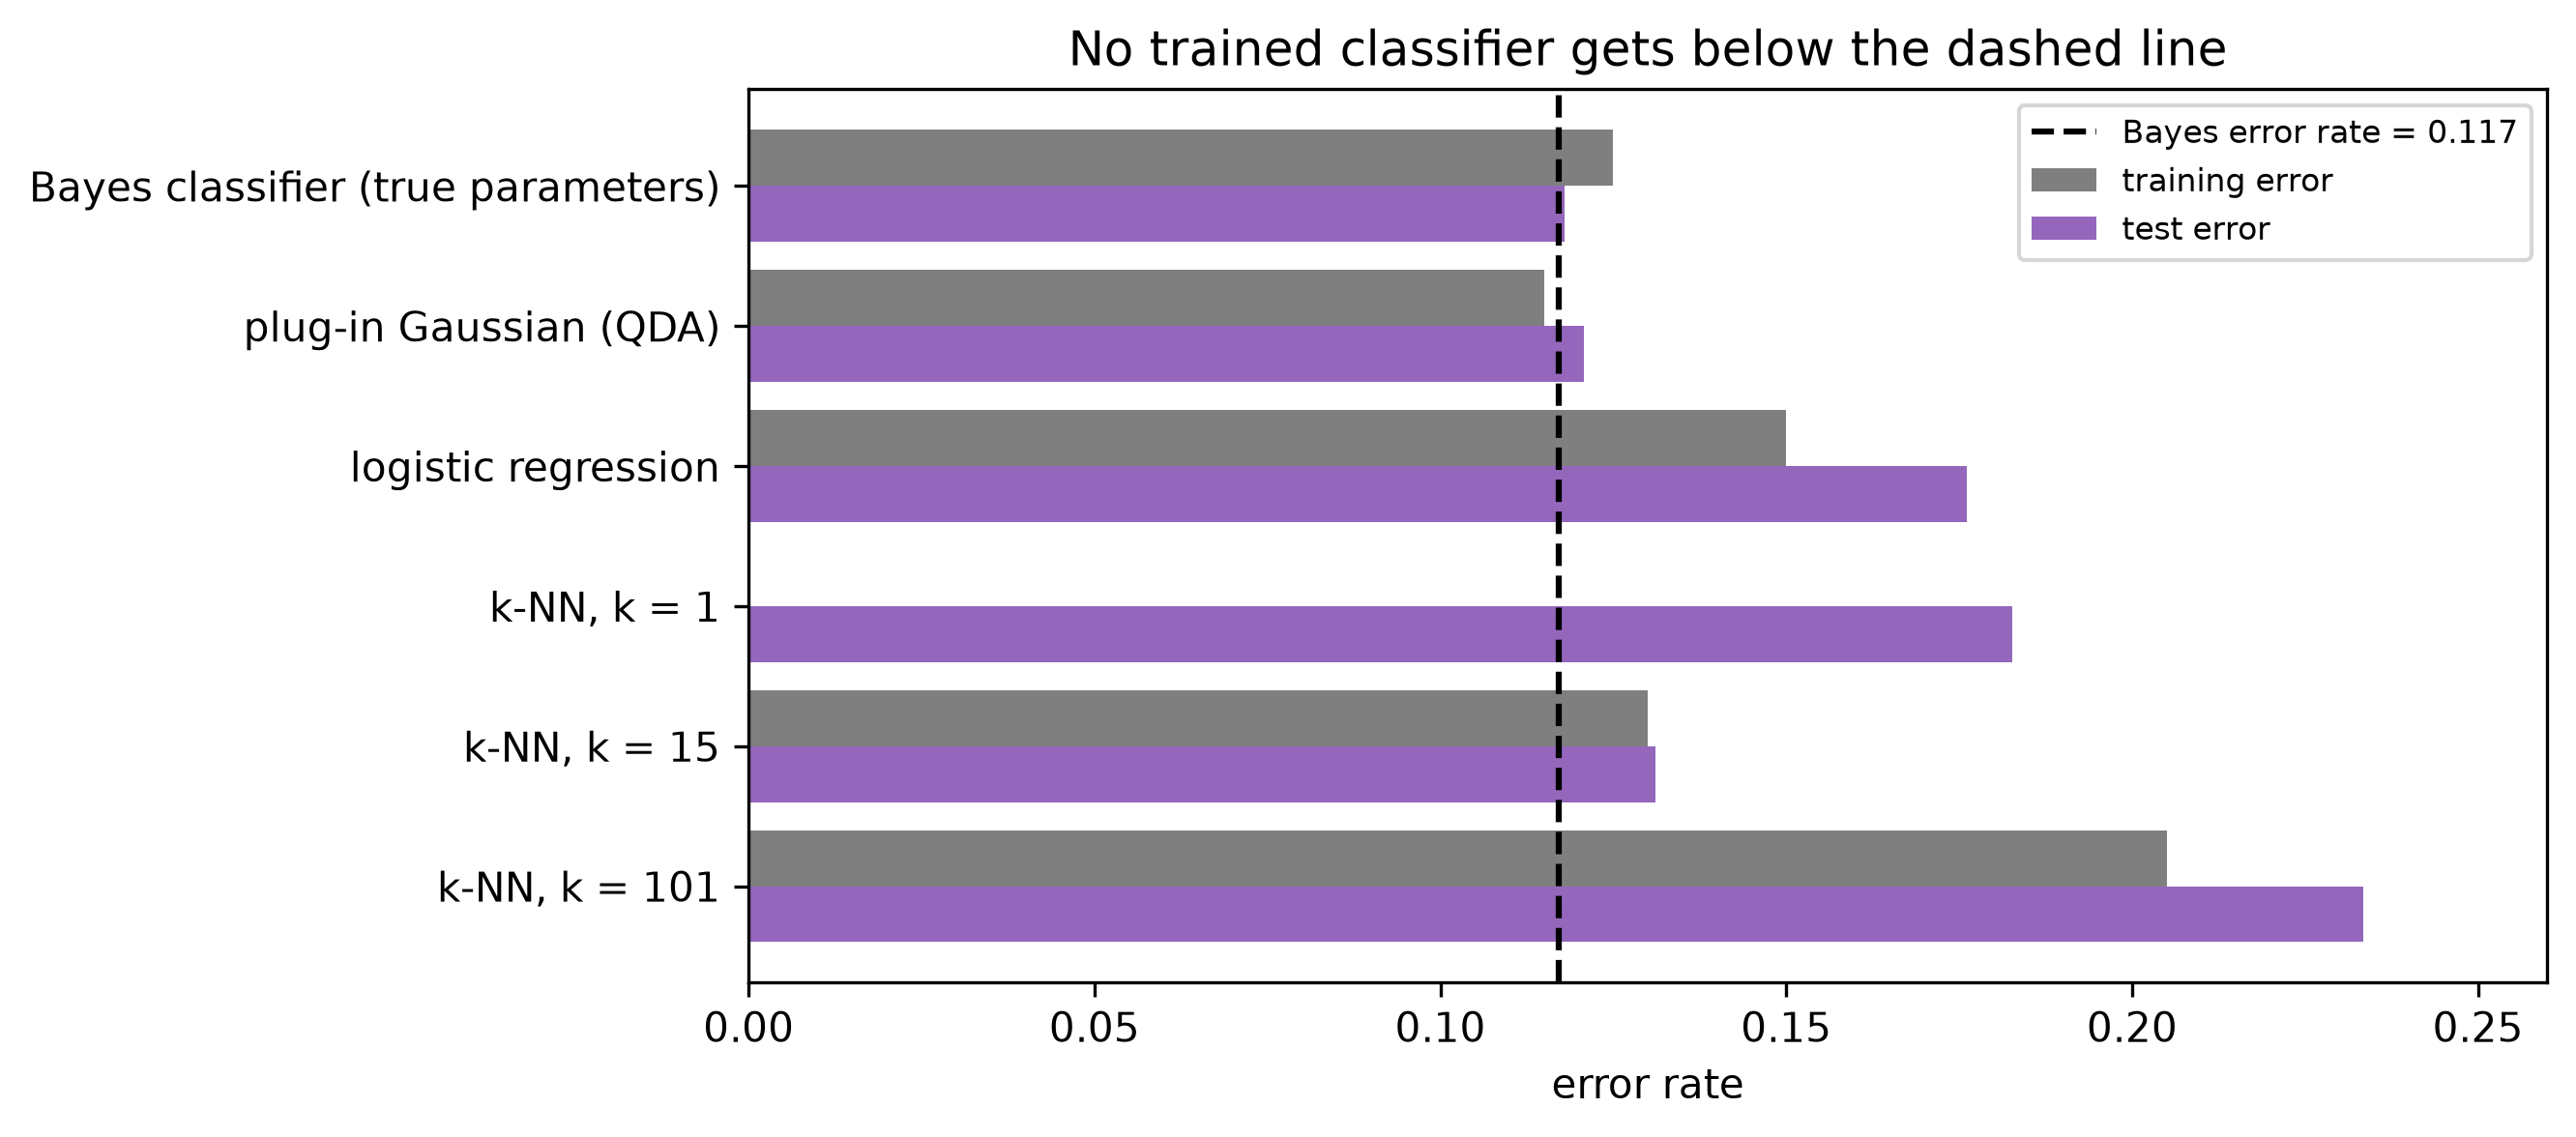

In [53]:
fig, ax = plt.subplots(figsize=(8, 4))
names = comparison.index.tolist()                                      # the six classifier names
y_pos = np.arange(len(names))                                          # one row position per classifier

ax.barh(y_pos - 0.2, comparison["train error"], height=0.4, color="tab:grey", label="training error")
ax.barh(y_pos + 0.2, comparison["test error"], height=0.4, color="tab:purple", label="test error")
ax.axvline(BAYES_ERROR, color="black", ls="--", lw=1.5, label=f"Bayes error rate = {BAYES_ERROR:.3f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.invert_yaxis()                                                      # first classifier at the top
ax.set_xlabel("error rate")
ax.set_title("No trained classifier gets below the dashed line")
ax.set_xlim(0, 0.26)
ax.legend(fontsize=8, loc="upper right")
plt.show()

**Line by line**

- `ax.barh(...)` : horizontal bars, which leave room for long classifier names on the left.
- `y_pos - 0.2` and `y_pos + 0.2` with `height=0.4` : two thin bars side by side for each classifier, grey
  for training error and purple for test error.
- `ax.invert_yaxis()` : bar charts draw the first row at the bottom by default; inverting puts the first
  classifier at the top, matching the table.

**Reading the plot.** Every purple bar reaches the dashed line or goes past it. The grey bars, on the other hand,
are allowed to go below it, and two of them do: k-NN with k = 1 reports a training error of exactly zero, and
the plug-in Gaussian reports 0.115. A training error *far* below the Bayes error rate, like k = 1's zero, is a
sure sign that the classifier has fitted noise, because on fresh data no classifier can do that well. A small
dip below it, like the plug-in's, can also happen by luck when only 200 points are counted (even the Bayes
classifier's training error, 0.125, is off from its true 0.117 by that kind of amount). Either way, the
training error is not a measurement you can trust.

### 3g. How the trained boundaries compare with the Bayes boundary

The numbers above say *how much* each classifier loses. The boundaries say *why*.

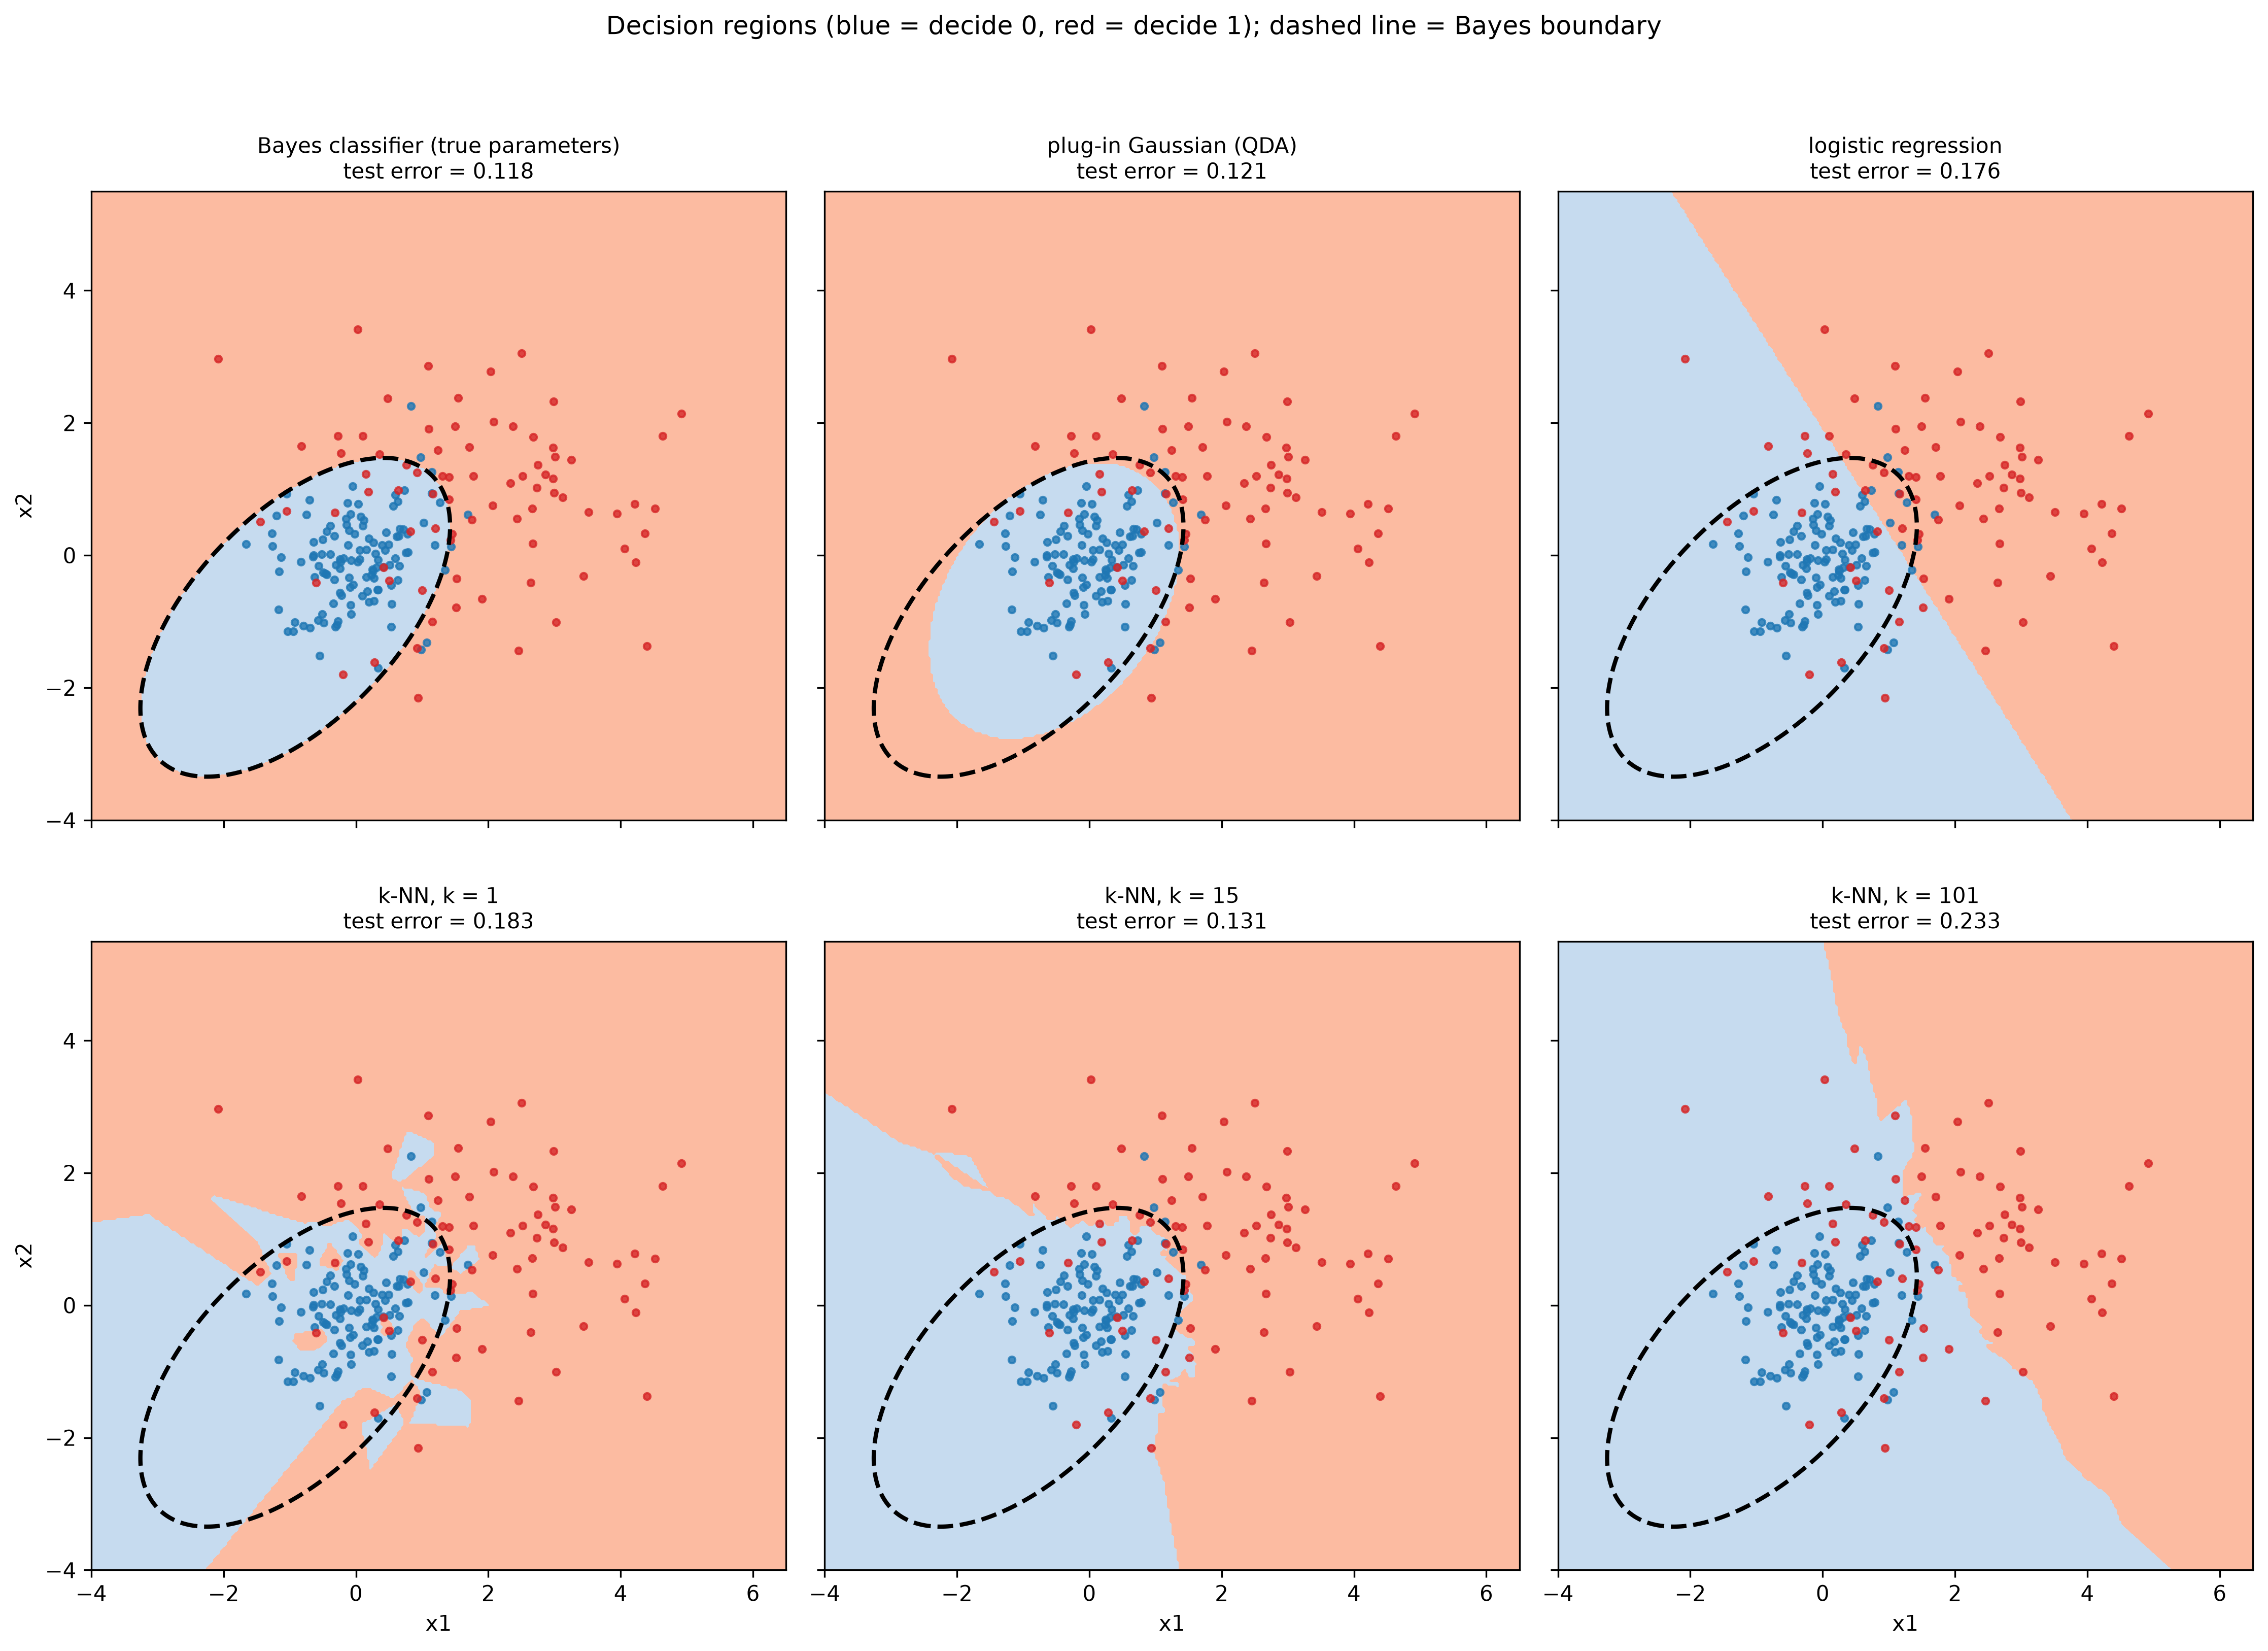

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(15, 11), sharex=True, sharey=True)

for ax, (name, predict) in zip(axes.ravel(), classifiers.items()):       # one panel per classifier
    region = predict(plot_points).reshape(P1.shape)                       # 0 or 1 at every grid point
    ax.contourf(P1, P2, region, levels=[-0.5, 0.5, 1.5],                   # two filled colour regions
                colors=["#c6dbef", "#fcbba1"])
    ax.contour(P1, P2, post_grid, levels=[0.5], colors="black",            # the TRUE Bayes boundary
               linewidths=2, linestyles="--")
    for c in (0, 1):
        keep = y_train == c
        ax.scatter(X_train[keep, 0], X_train[keep, 1], color=CLASS_COLORS[c], s=10, alpha=0.8)
    test_err = comparison.loc[name, "test error"]
    ax.set_title(f"{name}\ntest error = {test_err:.3f}", fontsize=10)
    ax.set_xlim(plot_g1[0], plot_g1[-1])
    ax.set_ylim(plot_g2[0], plot_g2[-1])
    ax.set_aspect("equal")

for ax in axes[1]:
    ax.set_xlabel("x1")
for ax in axes[:, 0]:
    ax.set_ylabel("x2")
plt.suptitle("Decision regions (blue = decide 0, red = decide 1); dashed line = Bayes boundary", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])                                   # leave room for the suptitle
plt.show()

**Line by line**

- `zip(axes.ravel(), classifiers.items())` : `axes` is a 2 × 3 grid of panels; `.ravel()` flattens it into a
  list of 6, which `zip` pairs with the 6 classifiers in order.
- `predict(plot_points).reshape(P1.shape)` : the "flatten, compute, reshape" recipe once more. Every classifier
  labels all 90 000 grid points and the labels are folded back into a grid.
- `ax.contourf(..., levels=[-0.5, 0.5, 1.5], colors=[...])` : with labels that are only 0 or 1, these levels
  create exactly two bands, "below 0.5" and "above 0.5", coloured light blue and light red.
- The dashed contour is the **true** Bayes boundary, drawn on every panel as a reference.
- `sharex=True, sharey=True` : all six panels use the same axis ranges, so the shapes can be compared directly.

**Reading the panels.**

- The **plug-in Gaussian** draws an ellipse in the right place with the right tilt, and matches the dashed one
  closely on the side facing class 1. In the lower-left it is too small, because no training points landed
  there to tell it otherwise. Very few test points ever land there either, so this visible difference costs
  only about 0.004 in error. **Mistakes in regions where data rarely appears are cheap.**
- **Logistic regression** draws a straight line. A line can only cut the plane into two halves, so the part of
  the Bayes ellipse facing class 1 is roughly right, but the whole outer ring on the far side (left and
  bottom-left), which the Bayes rule gives to class 1, is simply out of reach. However much data you give it,
  the line stays a line: this is **bias**.
- **k-NN, k = 1** draws a jagged patchwork with little islands around individual training points. Draw a new
  training set and the islands would be somewhere else entirely: this is **variance**.
- **k-NN, k = 15** follows the Bayes boundary closely where the training points are (the upper-right side of the
  ellipse). Far from the data, in the lower-left, it simply extends whatever the nearest points say, which again
  costs little because few points ever land there.
- **k-NN, k = 101** votes over half the training set. Its boundary degenerates into something close to a
  diagonal line, much like logistic regression's but wobblier, and its error is the worst of all.

These five pictures are the bias–variance trade-off for classification, drawn before we have even named it.

### 3h. More data: who reaches the Bayes error rate?

A classifier's excess error has two sources:

$$\underbrace{\text{test error} - R^*}_{\text{excess error}} \;=\; \underbrace{\text{approximation error}}_{\text{the model family cannot represent the Bayes boundary}} \;+\; \underbrace{\text{estimation error}}_{\text{finite data gives imperfect parameters}}$$

More training data shrinks the estimation error but does nothing to the approximation error. So if we train on
larger and larger samples, the plug-in Gaussian (correct family) should approach the Bayes error rate, while
logistic regression (wrong family) should level off above it. Because a single training set can be lucky or
unlucky, each size is repeated 10 times and the results averaged.

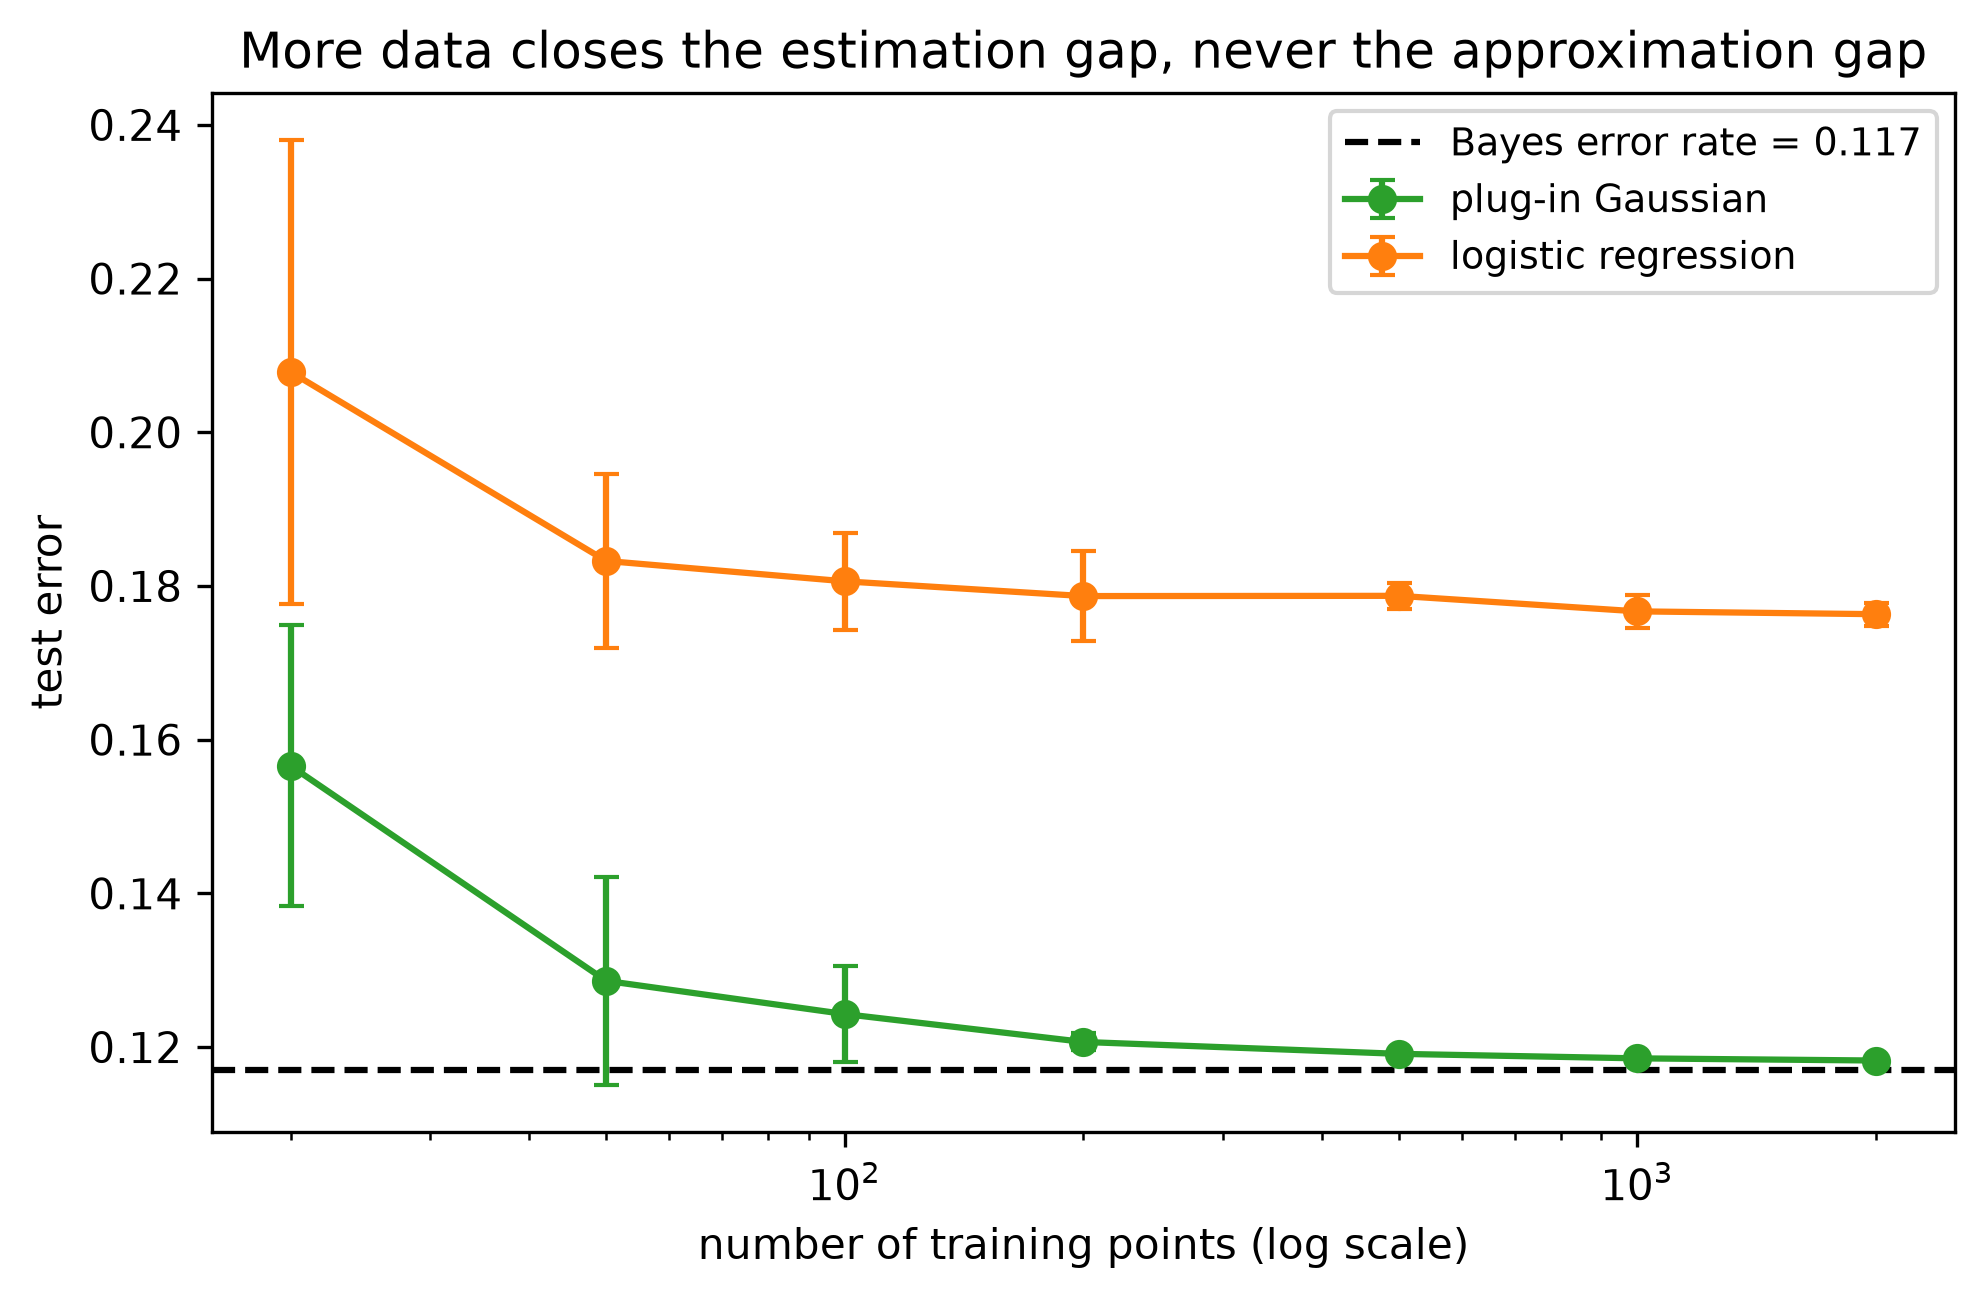

,plug-in Gaussian,logistic regression
n_train,,
20,0.1566,0.2078
50,0.1286,0.1833
100,0.1243,0.1806
200,0.1207,0.1787
500,0.1191,0.1787
1000,0.1185,0.1767
2000,0.1182,0.1763


In [55]:
train_sizes = [20, 50, 100, 200, 500, 1000, 2000]          # training-set sizes to try
n_repeats = 10                                             # independent training sets per size

curve = {"plug-in Gaussian": [], "logistic regression": []}   # mean test error per size
spread = {"plug-in Gaussian": [], "logistic regression": []}  # standard deviation per size

for n in train_sizes:
    errs_plugin, errs_logistic = [], []
    for _ in range(n_repeats):
        X_n, y_n = sample_world(n)                                        # a brand-new training set
        plug = fit_plugin_gaussian(X_n, y_n)
        errs_plugin.append(np.mean(gaussian_class_scores(X_test, *plug).argmax(axis=1) != y_test))
        logit = fit_logistic(X_n, y_n.astype(float))
        errs_logistic.append(np.mean(predict_logistic(X_test, logit) != y_test))
    curve["plug-in Gaussian"].append(np.mean(errs_plugin))
    spread["plug-in Gaussian"].append(np.std(errs_plugin))
    curve["logistic regression"].append(np.mean(errs_logistic))
    spread["logistic regression"].append(np.std(errs_logistic))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, color in (("plug-in Gaussian", "tab:green"), ("logistic regression", "tab:orange")):
    ax.errorbar(train_sizes, curve[name], yerr=spread[name], marker="o", capsize=3, color=color, label=name)
ax.axhline(BAYES_ERROR, color="black", ls="--", label=f"Bayes error rate = {BAYES_ERROR:.3f}")
ax.set_xscale("log")
ax.set_xlabel("number of training points (log scale)")
ax.set_ylabel("test error")
ax.set_title("More data closes the estimation gap, never the approximation gap")
ax.legend(fontsize=9)
plt.show()

pd.DataFrame(curve, index=pd.Index(train_sizes, name="n_train")).round(4)

**Line by line**

- Two nested loops: the outer one over training-set sizes, the inner one over 10 repeats. Every repeat draws a
  **brand-new** training set from the world with `sample_world(n)`, trains both classifiers on it, and measures
  their error on the same big test set.
- `curve[name].append(np.mean(...))` and `spread[name].append(np.std(...))` : for each size we keep the average
  test error over the 10 repeats and how much it varied between them.
- `ax.errorbar(x, y, yerr=...)` : plots the averages with vertical bars showing ± one standard deviation.
  `capsize=3` adds the little horizontal caps.
- `ax.set_xscale("log")` : the sizes grow by factors of 2 to 2.5, so a log axis spaces them evenly.

**Reading the plot.**

- With **20** points both classifiers are poor and very variable (long error bars): a different 20 points gives a
  noticeably different classifier. The plug-in Gaussian has 11 parameters to estimate from those 20 points,
  and its error of about 0.157 is far above the Bayes error rate. It still beats logistic regression here,
  because its model family is the right one.
- As the data grows, the **plug-in Gaussian** slides down onto the dashed line: its estimation error goes to
  zero and it *becomes* the Bayes classifier. At 2000 points its test error (0.118) is the same as the Bayes
  classifier's own measured test error on this test set (also 0.118; the tiny gap to the exact 0.117 is
  test-set noise).
- **Logistic regression** flattens out around 0.18 and stays there. Its error bars shrink (it becomes very
  consistent) but it is consistently wrong by the same amount. That flat gap is its approximation error, and
  no amount of data can close it.
- A small reading tip: where an error bar pokes below the dashed line (the plug-in at 50 points), it does
  **not** mean that some run beat the Bayes classifier. The bar is just "average ± one standard deviation",
  drawn symmetrically, and the spread of errors is lopsided because errors pile up just above the floor.

This picture is the bridge to Part 5. Approximation error is **bias**, estimation error is **variance**, and
choosing a model means balancing the two for the amount of data you actually have.

---
## Part 4: Regression — the conditional mean is the best predictor

For regression the label is a number and the usual loss is the **squared error** $(y - \hat{y})^2$. Decision
theory says: at every $x$, choose the prediction with the smallest expected loss. Part 4 shows by experiment
that this prediction is the **conditional mean** $E[Y \mid X = x]$, and that even this perfect predictor cannot
push the error below the noise.

### 4a. A regression world we control

$$X \sim \text{Uniform}(-1, 1), \qquad Y = f(X) + \varepsilon, \qquad f(x) = 1.5 \sin(3x + 0.6), \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2), \;\; \sigma = 0.5$$

Read it as a story: pick an $x$ anywhere between -1 and 1; the "true" value at that $x$ is $f(x)$; what we
actually observe is $f(x)$ plus a random error $\varepsilon$ that averages to zero. Because the noise averages
to zero, the average of $Y$ at a fixed $x$ is exactly $f(x)$:

$$E[Y \mid X = x] = f(x) + E[\varepsilon] = f(x)$$

So in this world the conditional mean is the function $f$ itself, which is why $f$ is called the
**regression function**. In real life $f$ is unknown and learning it is the whole job. Here we know it, so we
can check every claim.

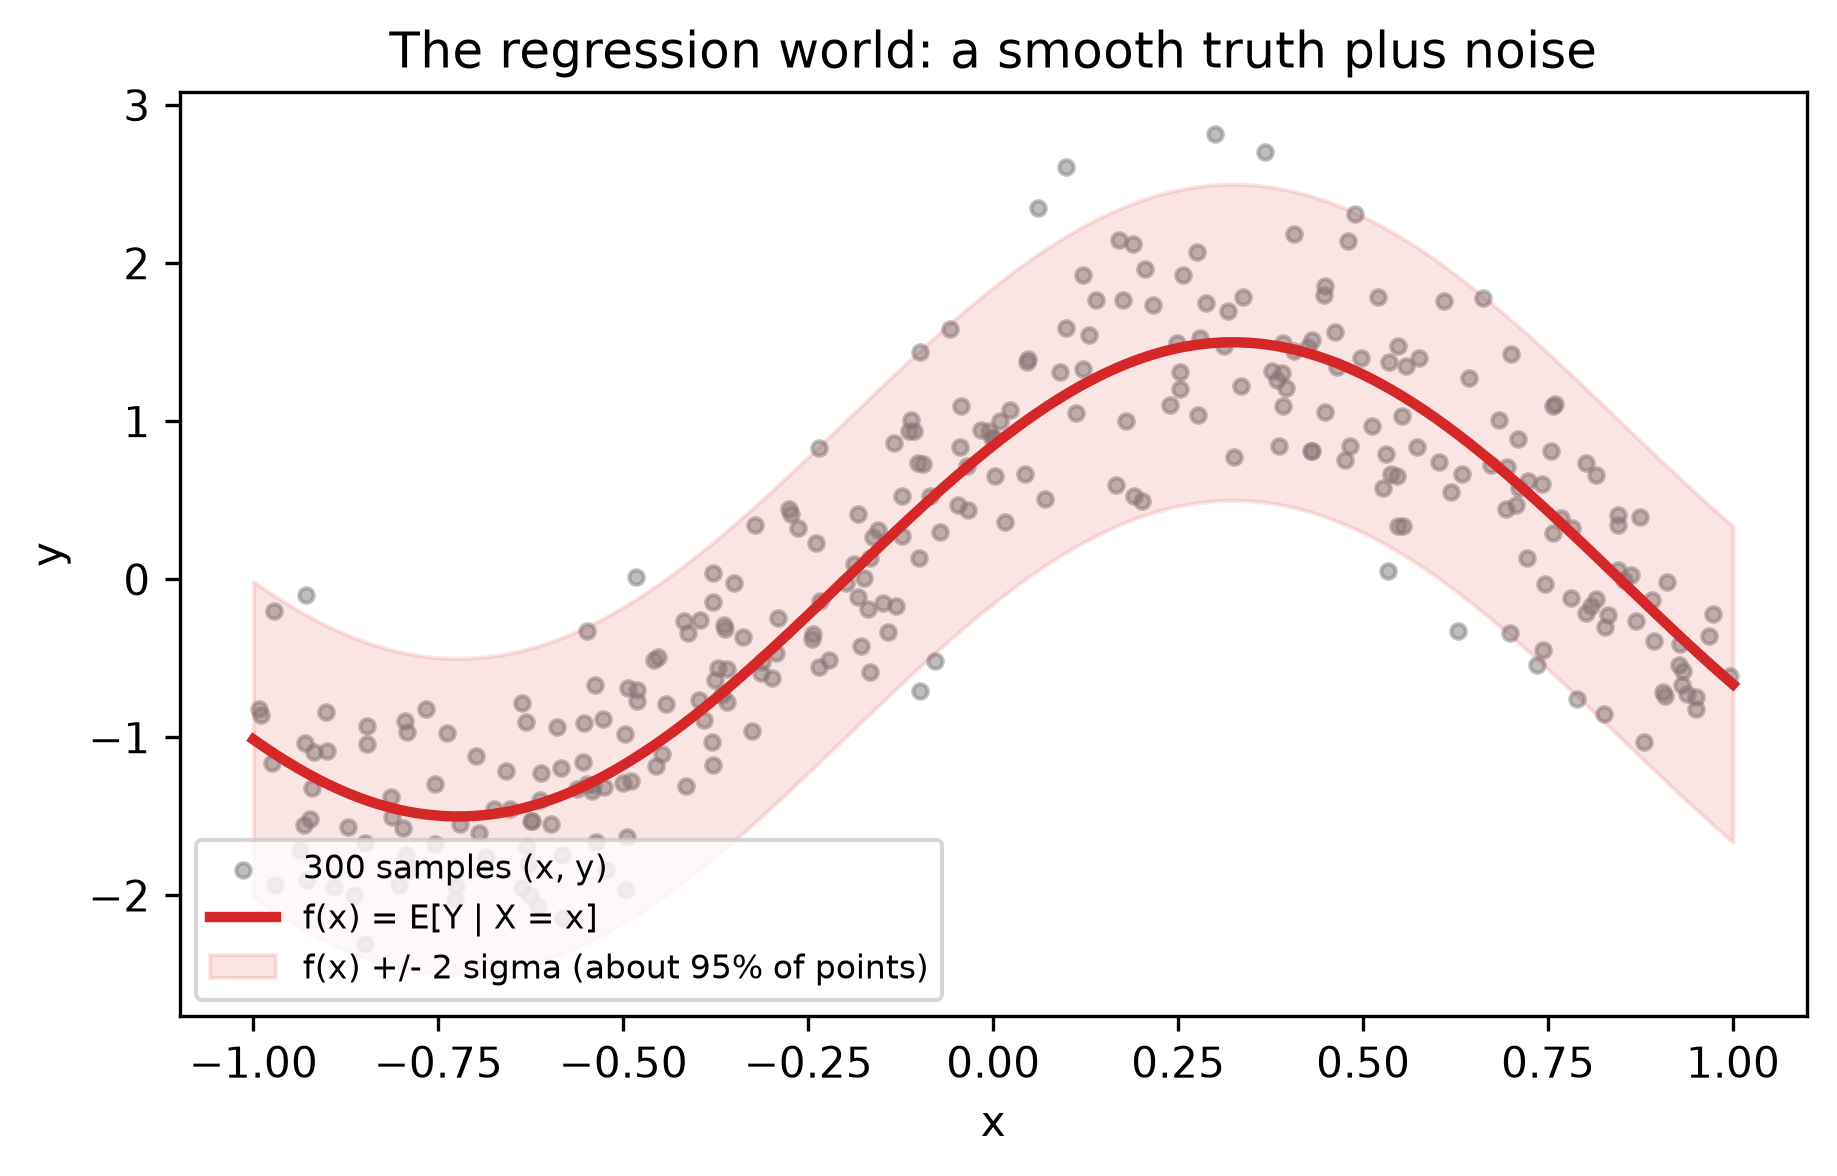

In [56]:
NOISE_SD = 0.5                                   # sigma: standard deviation of the noise
NOISE_VAR = NOISE_SD ** 2                        # sigma^2 = 0.25: the irreducible error


def f_true(x):
    '''The true regression function f(x) = E[Y | X = x]. In real life nobody gives you this.'''
    return 1.5 * np.sin(3.0 * x + 0.6)


def sample_regression(n, noise_sd=NOISE_SD):
    '''Draw n pairs (x, y): x uniform on [-1, 1], y = f(x) + Gaussian noise.'''
    x = rng.uniform(-1.0, 1.0, size=n)                     # inputs spread evenly over [-1, 1]
    y = f_true(x) + rng.normal(0.0, noise_sd, size=n)      # true value plus random error
    return x, y


x_reg, y_reg = sample_regression(300)            # a sample of 300 points, just to look at
x_line = np.linspace(-1.0, 1.0, 400)             # a fine grid for drawing smooth curves

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_reg, y_reg, s=12, alpha=0.5, color="tab:grey", label="300 samples (x, y)")
ax.plot(x_line, f_true(x_line), color="tab:red", lw=2.5, label="f(x) = E[Y | X = x]")
ax.fill_between(x_line, f_true(x_line) - 2 * NOISE_SD, f_true(x_line) + 2 * NOISE_SD,
                color="tab:red", alpha=0.12, label="f(x) +/- 2 sigma (about 95% of points)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("The regression world: a smooth truth plus noise")
ax.legend(fontsize=8, loc="lower left")
plt.show()

**Line by line**

- `NOISE_SD` and `NOISE_VAR` : the noise level. $\sigma^2 = 0.25$ will turn out to be the smallest expected
  squared error that *any* predictor can achieve, so it gets its own name.
- `f_true` : the true regression function. It is one smooth wave across the interval; the `+ 0.6` shifts it
  sideways so that it is neither symmetric nor antisymmetric around 0. (That detail matters in Part 5: a
  lopsided curve needs *both* even and odd powers of $x$, so every extra polynomial degree helps a little.)
- `rng.uniform(-1.0, 1.0, size=n)` : `n` random numbers spread evenly between -1 and 1.
- `f_true(x) + rng.normal(0.0, noise_sd, size=n)` : the generative story in one line: truth plus noise.
- `ax.fill_between(x, lower, upper)` : shades the band between two curves. For Gaussian noise about 95% of
  points fall within two standard deviations of the mean, so the band shows where the data "should" be.

**Reading the plot.** The red curve runs through the middle of the cloud at every $x$. That is what "the
conditional mean" looks like: take a thin vertical slice at any $x$, and the red curve is the average height of
the grey points in that slice.

### 4b. At one fixed x: which single number minimises the squared error?

Freeze $x$ at one value, $x_0 = 0.3$. At that point $Y$ is still random: it is $f(0.3)$ plus noise. Our
predictor must commit to one number $c$. Which $c$ gives the smallest expected squared error
$E[(Y - c)^2 \mid X = x_0]$?

A two-line piece of algebra answers it. Write $m = E[Y \mid x_0]$ and add and subtract $m$ inside the square:

$$E[(Y - c)^2] = E[(Y - m + m - c)^2] = \underbrace{E[(Y - m)^2]}_{\text{variance of } Y = \sigma^2} + 2(m - c)\underbrace{E[Y - m]}_{= 0} + (m - c)^2$$

$$\boxed{\;E[(Y - c)^2 \mid x_0] = \sigma^2 + \big(E[Y \mid x_0] - c\big)^2\;}$$

The first term does not depend on $c$ at all. The second is a square, never negative, and zero exactly when
$c = E[Y \mid x_0]$. So the best constant is the conditional mean, and the best achievable error is $\sigma^2$.
Now the experiment.

true conditional mean  E[Y | x0]     = 1.4962
sample mean of the 100 000 draws     = 1.4980
best candidate c (brute force)       = 1.4962
smallest mean squared error          = 0.2502
noise variance sigma^2               = 0.2500


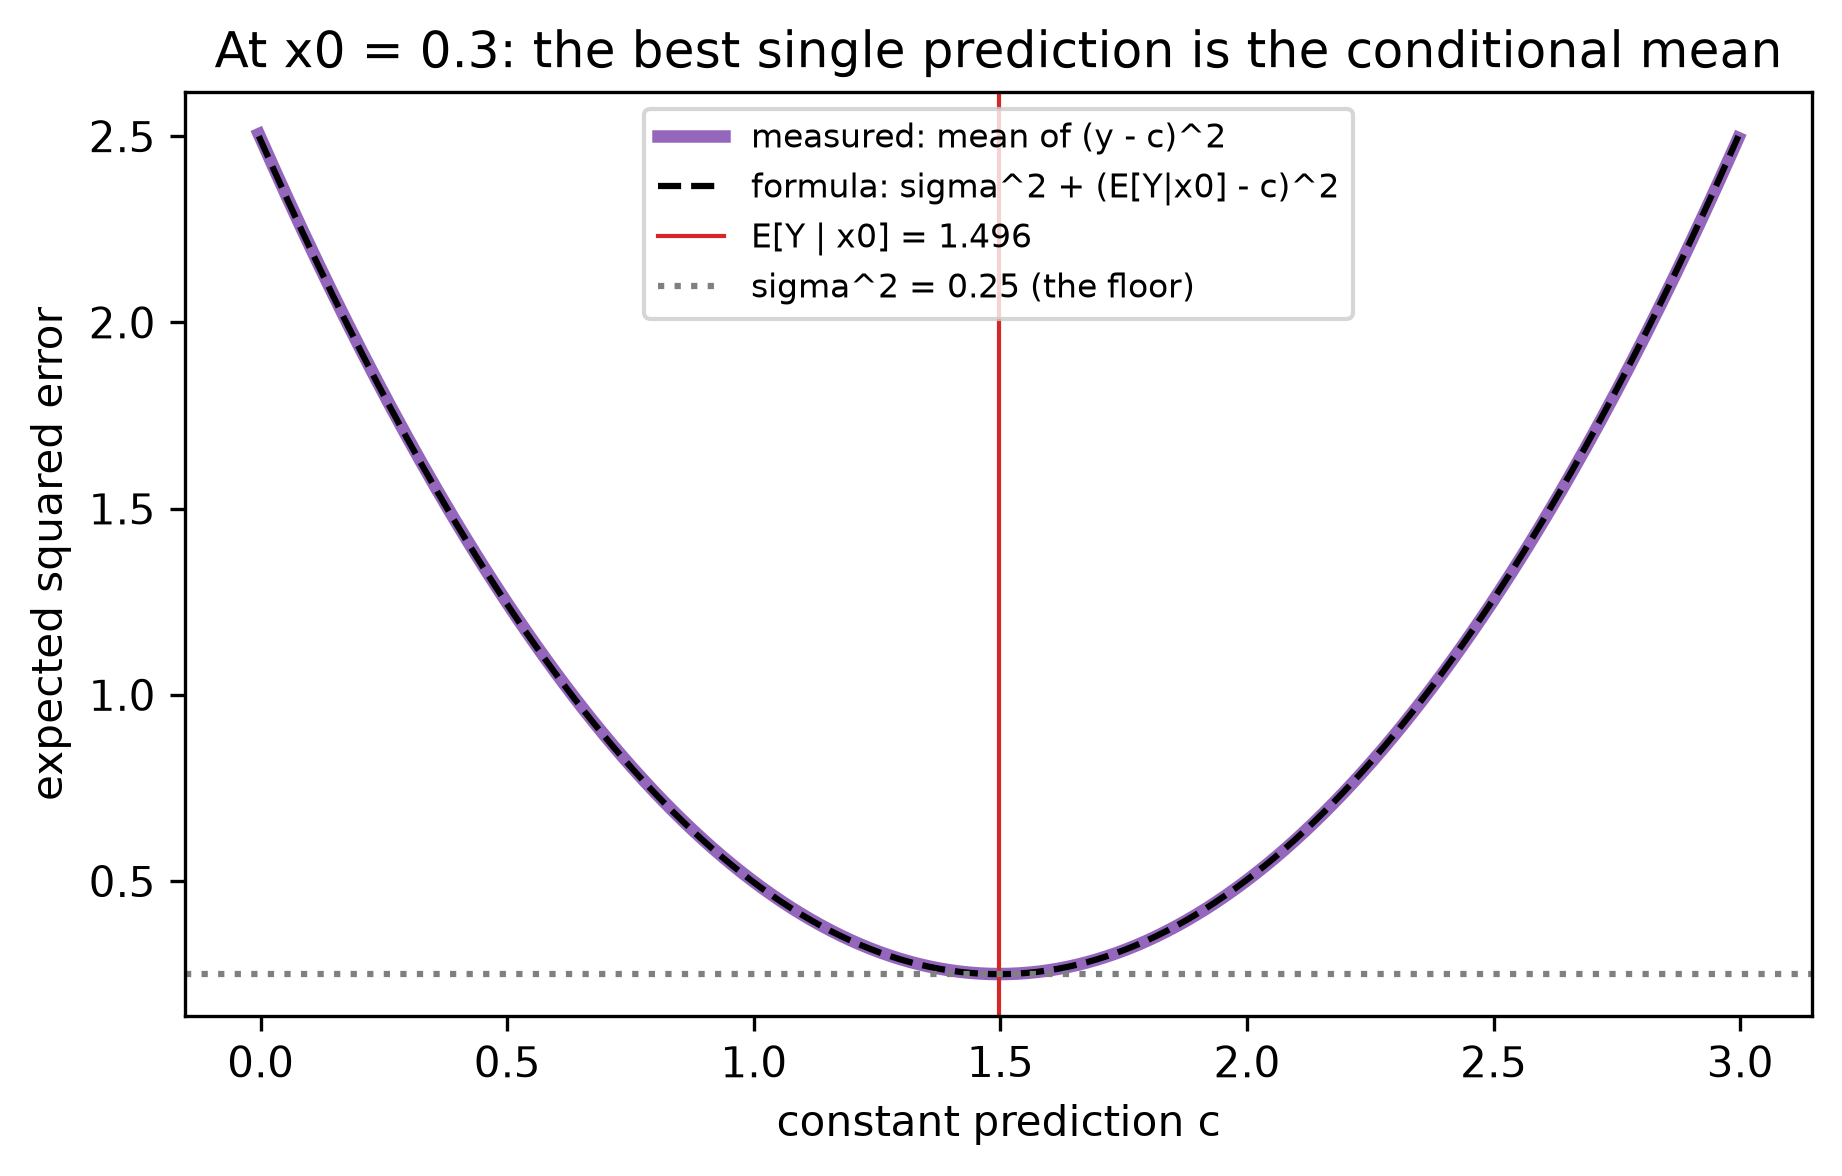

In [57]:
x0 = 0.3                                                         # the fixed input we look at
m_true = f_true(x0)                                              # the true conditional mean E[Y | x0]

y_at_x0 = m_true + rng.normal(0.0, NOISE_SD, size=100_000)       # 100 000 draws of Y at this one x

candidates = np.linspace(m_true - 1.5, m_true + 1.5, 301)        # 301 possible predictions c
mse_of_c = np.array([np.mean((y_at_x0 - c) ** 2)                 # average squared error of each c
                     for c in candidates])
theory = NOISE_VAR + (m_true - candidates) ** 2                  # the boxed formula

best_c = candidates[np.argmin(mse_of_c)]                         # the c with the smallest error

print(f"true conditional mean  E[Y | x0]     = {m_true:.4f}")
print(f"sample mean of the 100 000 draws     = {y_at_x0.mean():.4f}")
print(f"best candidate c (brute force)       = {best_c:.4f}")
print(f"smallest mean squared error          = {mse_of_c.min():.4f}")
print(f"noise variance sigma^2               = {NOISE_VAR:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(candidates, mse_of_c, color="tab:purple", lw=3, label="measured: mean of (y - c)^2")
ax.plot(candidates, theory, color="black", ls="--", lw=1.5, label="formula: sigma^2 + (E[Y|x0] - c)^2")
ax.axvline(m_true, color="tab:red", lw=1, label=f"E[Y | x0] = {m_true:.3f}")
ax.axhline(NOISE_VAR, color="grey", ls=":", label="sigma^2 = 0.25 (the floor)")
ax.set_xlabel("constant prediction c")
ax.set_ylabel("expected squared error")
ax.set_title(f"At x0 = {x0}: the best single prediction is the conditional mean")
ax.legend(fontsize=8)
plt.show()

**Line by line**

- `m_true + rng.normal(0.0, NOISE_SD, size=100_000)` : 100 000 independent draws from the distribution of $Y$
  **at this one fixed $x$**, written $p(Y \mid X = 0.3)$. In real data you almost never have more than one
  observation at exactly the same $x$; here we can have as many as we like.
- `np.linspace(m_true - 1.5, m_true + 1.5, 301)` : candidate predictions from well below to well above the truth.
- The list comprehension scores each candidate by the average of $(y - c)^2$ over the 100 000 draws, which
  is our estimate of the expected squared error for that candidate.
- `theory = NOISE_VAR + (m_true - candidates) ** 2` : the boxed formula, computed for all candidates at once.

**Reading the output and the plot.**

- The measured curve (thick purple) and the formula (dashed black) lie on top of each other: a parabola whose
  bottom sits exactly at $E[Y \mid x_0]$.
- The brute-force best candidate, the sample mean and the true conditional mean all agree to within about
  0.002. The brute-force winner is simply the grid point closest to the sample mean (the candidates are 0.01
  apart), and that is no coincidence: for any set of numbers, the constant that minimises the average squared
  distance to them is their average.
- The bottom of the parabola is at height 0.25, which is $\sigma^2$. **Even the perfect prediction has an
  expected squared error of $\sigma^2$.** That is the **irreducible error**: the part of $Y$ that has nothing to
  do with $x$ and therefore cannot be predicted from $x$ by any method.
- Moving the prediction away from the mean by an amount $d$ costs exactly $d^2$ extra. Keep this picture in
  mind: in Part 5 that extra cost will be called the **bias²**.

### 4c. Over all x: no predictor beats the conditional mean

Now let $X$ vary. The same algebra, applied at every $x$ and then averaged over $x$, says that for **any**
predictor $g$:

$$E\big[(Y - g(X))^2\big] = \sigma^2 + E\big[(f(X) - g(X))^2\big]$$

The expected error of any predictor is the noise plus **how far that predictor is from the conditional mean**,
on average. So we test several predictors on one very large sample and check two things: the conditional
mean should come out lowest, at about $\sigma^2$, and every other predictor's extra error should equal its
average squared distance from $f$.

In [58]:
x_big, y_big = sample_regression(200_000)                        # a very large sample from the world

line_coef = np.polyfit(x_big, y_big, deg=1)                      # the best straight line, by least squares

predictors = {                                                   # name -> predictions at every x_big
    "f(x): the conditional mean":        f_true(x_big),
    "f(x) + 0.3: shifted up":            f_true(x_big) + 0.3,
    "0.8 f(x): shrunk towards zero":     0.8 * f_true(x_big),
    "f(x) + 0.3 sin(15x): wiggly":       f_true(x_big) + 0.3 * np.sin(15.0 * x_big),
    "best straight line":                np.polyval(line_coef, x_big),
    "constant: overall mean of Y":       np.full(len(x_big), y_big.mean()),
}

rows = []
for name, pred in predictors.items():
    mse = np.mean((y_big - pred) ** 2)                           # expected squared error, measured
    dist = np.mean((f_true(x_big) - pred) ** 2)                  # average squared distance from f
    rows.append({"predictor": name,
                 "test MSE": mse,
                 "MSE - sigma^2": mse - NOISE_VAR,
                 "E[(f(X) - g(X))^2]": dist})

regression_table = pd.DataFrame(rows).set_index("predictor")
print(f"noise variance sigma^2 = {NOISE_VAR}\n")
regression_table

noise variance sigma^2 = 0.25



,test MSE,MSE - sigma^2,E[(f(X) - g(X))^2]
predictor,,,
f(x): the conditional mean,0.2490,-0.0010,0.0000
f(x) + 0.3: shifted up,0.3381,0.0881,0.0900
0.8 f(x): shrunk towards zero,0.2943,0.0443,0.0457
f(x) + 0.3 sin(15x): wiggly,0.2953,0.0453,0.0464
best straight line,0.8427,0.5927,0.5947
constant: overall mean of Y,1.3872,1.1372,1.1401


**Line by line**

- `np.polyfit(x, y, deg=1)` : fits a straight line by least squares and returns its two coefficients (slope
  first, then intercept). It is the same least-squares idea as Practical 1, in one convenient call.
  `np.polyval(coef, x)` evaluates that line at every `x`.
- `predictors = {...}` : a dictionary from a descriptive name to an array of 200 000 predictions. Each
  predictor is a *rule* $g(x)$ applied to every sampled $x$.
  - The **shifted** predictor is always 0.3 too high.
  - The **shrunk** predictor has the right shape but is too timid.
  - The **wiggly** predictor adds a fast oscillation on top of the truth.
  - The **best straight line** is the best possible *linear* predictor, a stand-in for a model that is too
    simple.
  - The **constant** predictor ignores $x$ entirely. `np.full(n, value)` makes an array of `n` copies of `value`.
- `mse = np.mean((y_big - pred) ** 2)` : the measured expected squared error of the predictor.
- `dist = np.mean((f_true(x_big) - pred) ** 2)` : how far the predictor is from the conditional mean, on
  average. This can only be computed because we know $f$.

**Reading the table.**

- The conditional mean's test MSE is about **0.25 = $\sigma^2$**, and it is the smallest in the column. (It
  even comes out a hair *below* 0.25, at 0.249. That is sampling noise: this particular sample of 200 000 noise
  values happens to be slightly less spread out than the theory says, and the standard error of an MSE
  estimate here is about 0.0008.)
- For every other predictor, the column "MSE − σ²" matches the column "E[(f(X) − g(X))²]" to within a few
  thousandths. The formula holds: **extra error = squared distance from the conditional mean.** The small
  differences are that same sampling noise.
- The shifted predictor pays $0.3^2 = 0.09$ extra, exactly as the parabola in 4b predicted.
- The straight line and the constant pay the most. They are not "wrong by a bit here and there"; their shape
  simply cannot follow the wave. That is **bias** again, now in regression.

The next cell draws the same table as a picture.

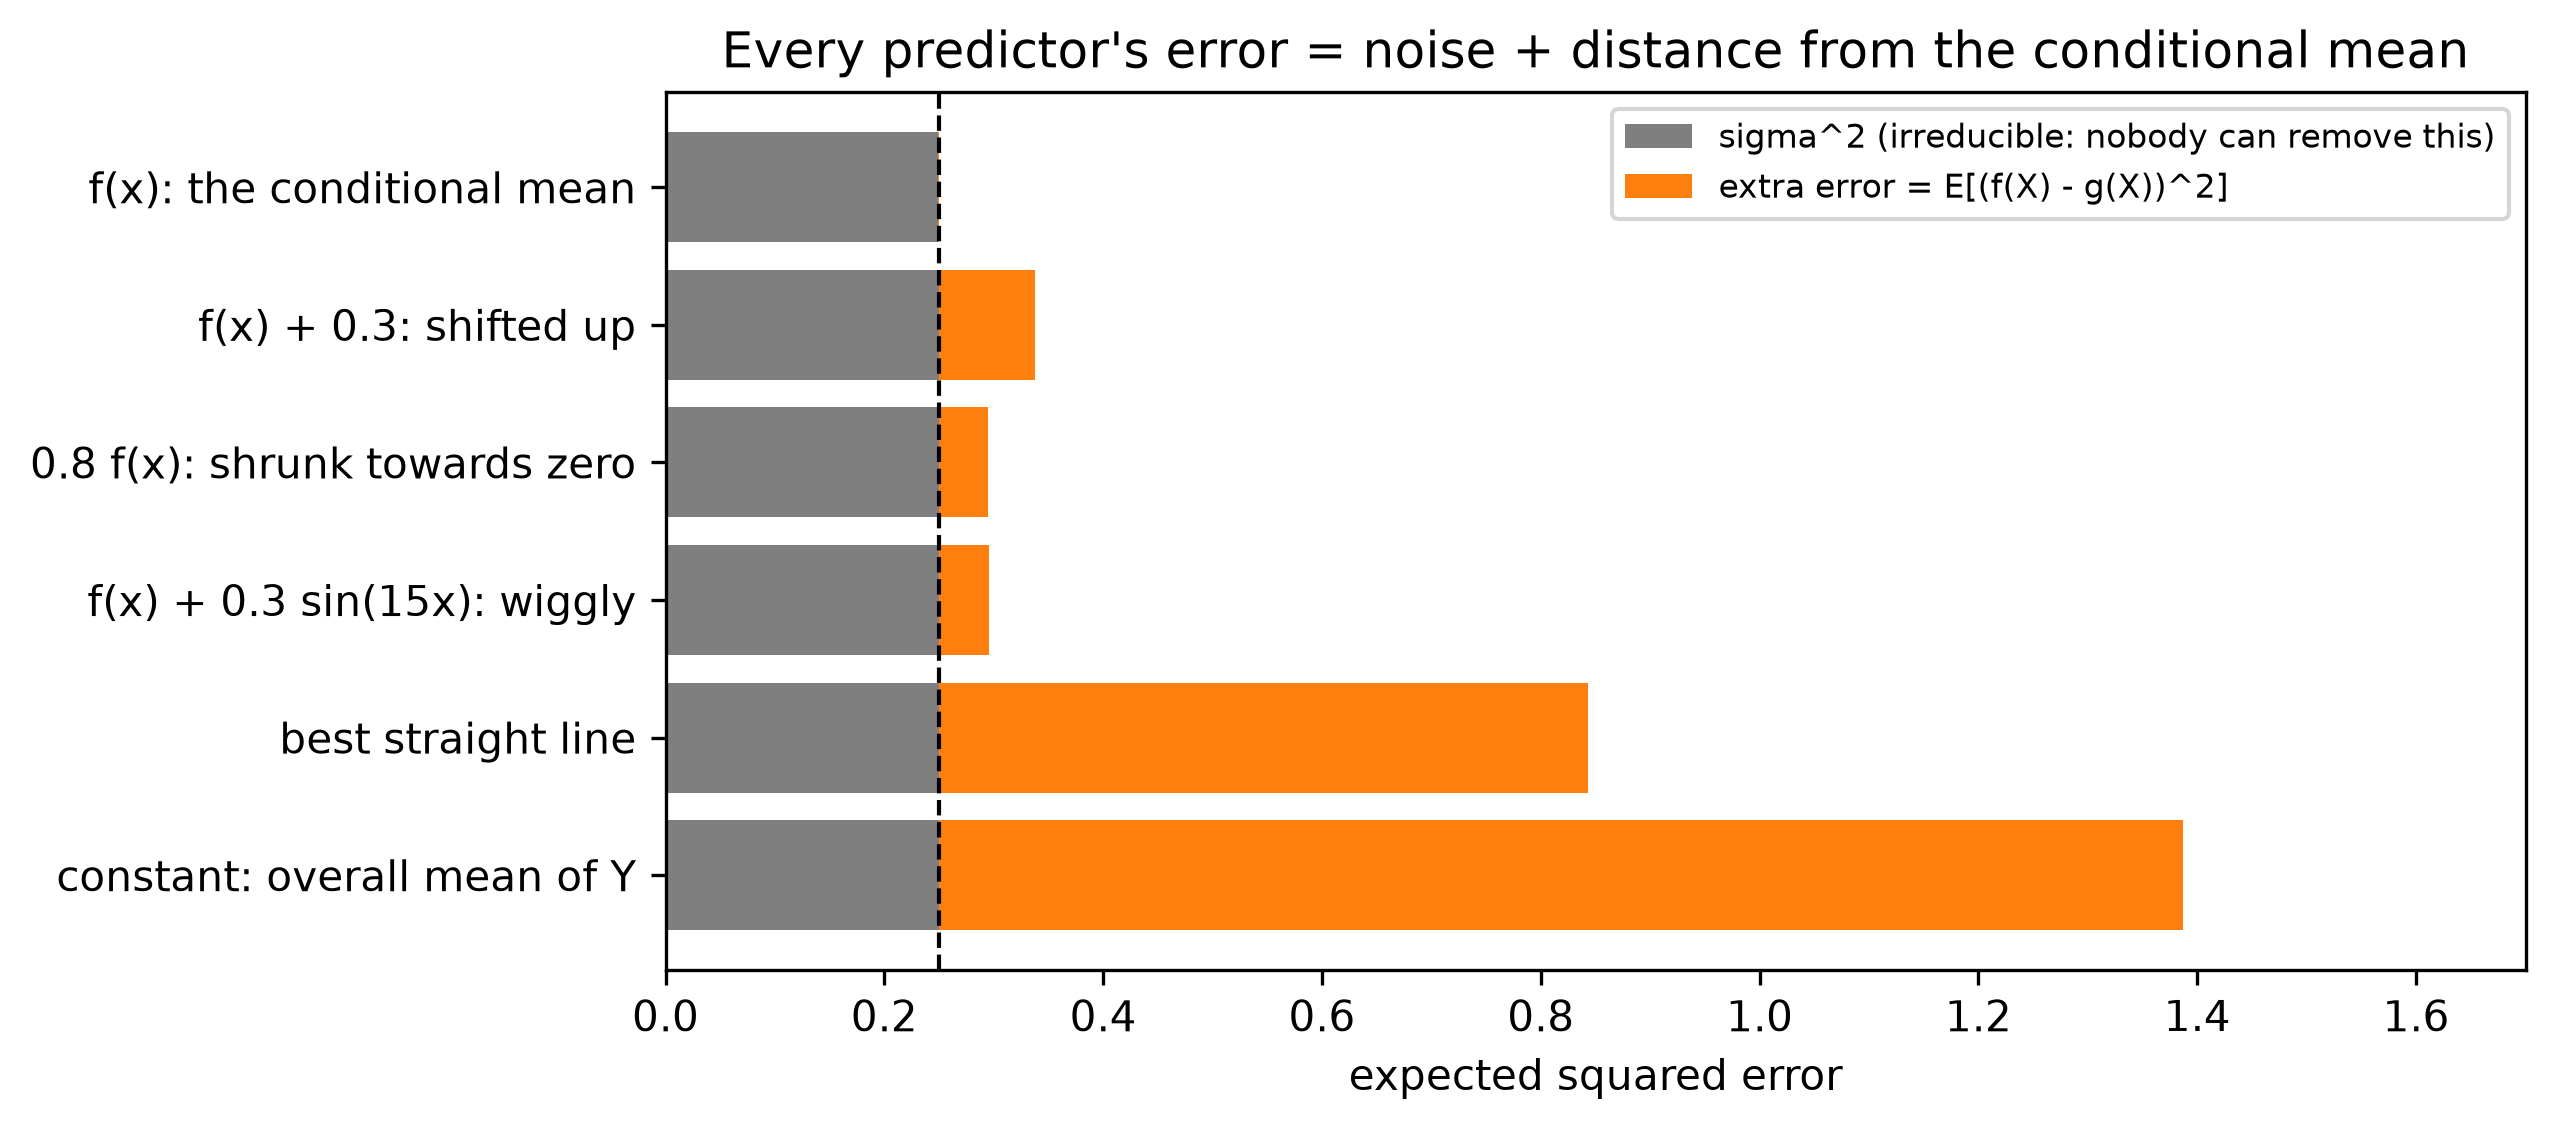

In [59]:
fig, ax = plt.subplots(figsize=(8, 3.8))
names = regression_table.index.tolist()
y_pos = np.arange(len(names))

ax.barh(y_pos, NOISE_VAR, color="tab:grey", label="sigma^2 (irreducible: nobody can remove this)")
ax.barh(y_pos, regression_table["MSE - sigma^2"], left=NOISE_VAR, color="tab:orange",
        label="extra error = E[(f(X) - g(X))^2]")
ax.axvline(NOISE_VAR, color="black", ls="--", lw=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("expected squared error")
ax.set_title("Every predictor's error = noise + distance from the conditional mean")
ax.set_xlim(0, 1.7)
ax.legend(fontsize=8, loc="upper right")
plt.show()

**Line by line**

- `ax.barh(y_pos, NOISE_VAR, ...)` : one grey bar of length $\sigma^2$ for every predictor. A single number is
  broadcast to all bars.
- `ax.barh(..., left=NOISE_VAR, ...)` : the orange bars start where the grey ones end, so each predictor's total
  bar length is its test MSE, split into the two parts of the formula. This is called a **stacked** bar chart.

**Reading the plot.** Every bar has the same grey part. Predictors differ only in their orange part, and the
conditional mean is the only one with (essentially) no orange at all. A better model can shrink the orange; no
model can touch the grey.

### 4d. The loss decides what "best" means: mean versus median

Is the answer always "the mean"? No: the optimal predictor depends on the loss.

| loss | optimal prediction at each $x$ |
|---|---|
| squared error $(y - \hat{y})^2$ | the conditional **mean** of $Y$ given $x$ |
| absolute error $\lvert y - \hat{y} \rvert$ | the conditional **median** of $Y$ given $x$ |

With Gaussian noise the mean and the median are the same number, so the difference is invisible. To see it we
switch, for this section only, to **skewed** noise: an exponential variable shifted so that its mean is zero.
It has a long right tail, which drags its mean above its median.

For an exponential variable with scale $s$, the mean is $s$ and the median is $s \ln 2$. Subtracting $s$ gives
noise with mean $0$ and median $s\ln 2 - s \approx -0.153$ for $s = 0.5$.

skewed noise: mean = -0.0005   median = -0.1545   (theory: 0 and -0.1534)

                                 mean SQUARED error  mean ABSOLUTE error
predictor                                                               
conditional mean   f(x)                      0.2503               0.3679
conditional median f(x) - 0.153              0.2734               0.3461


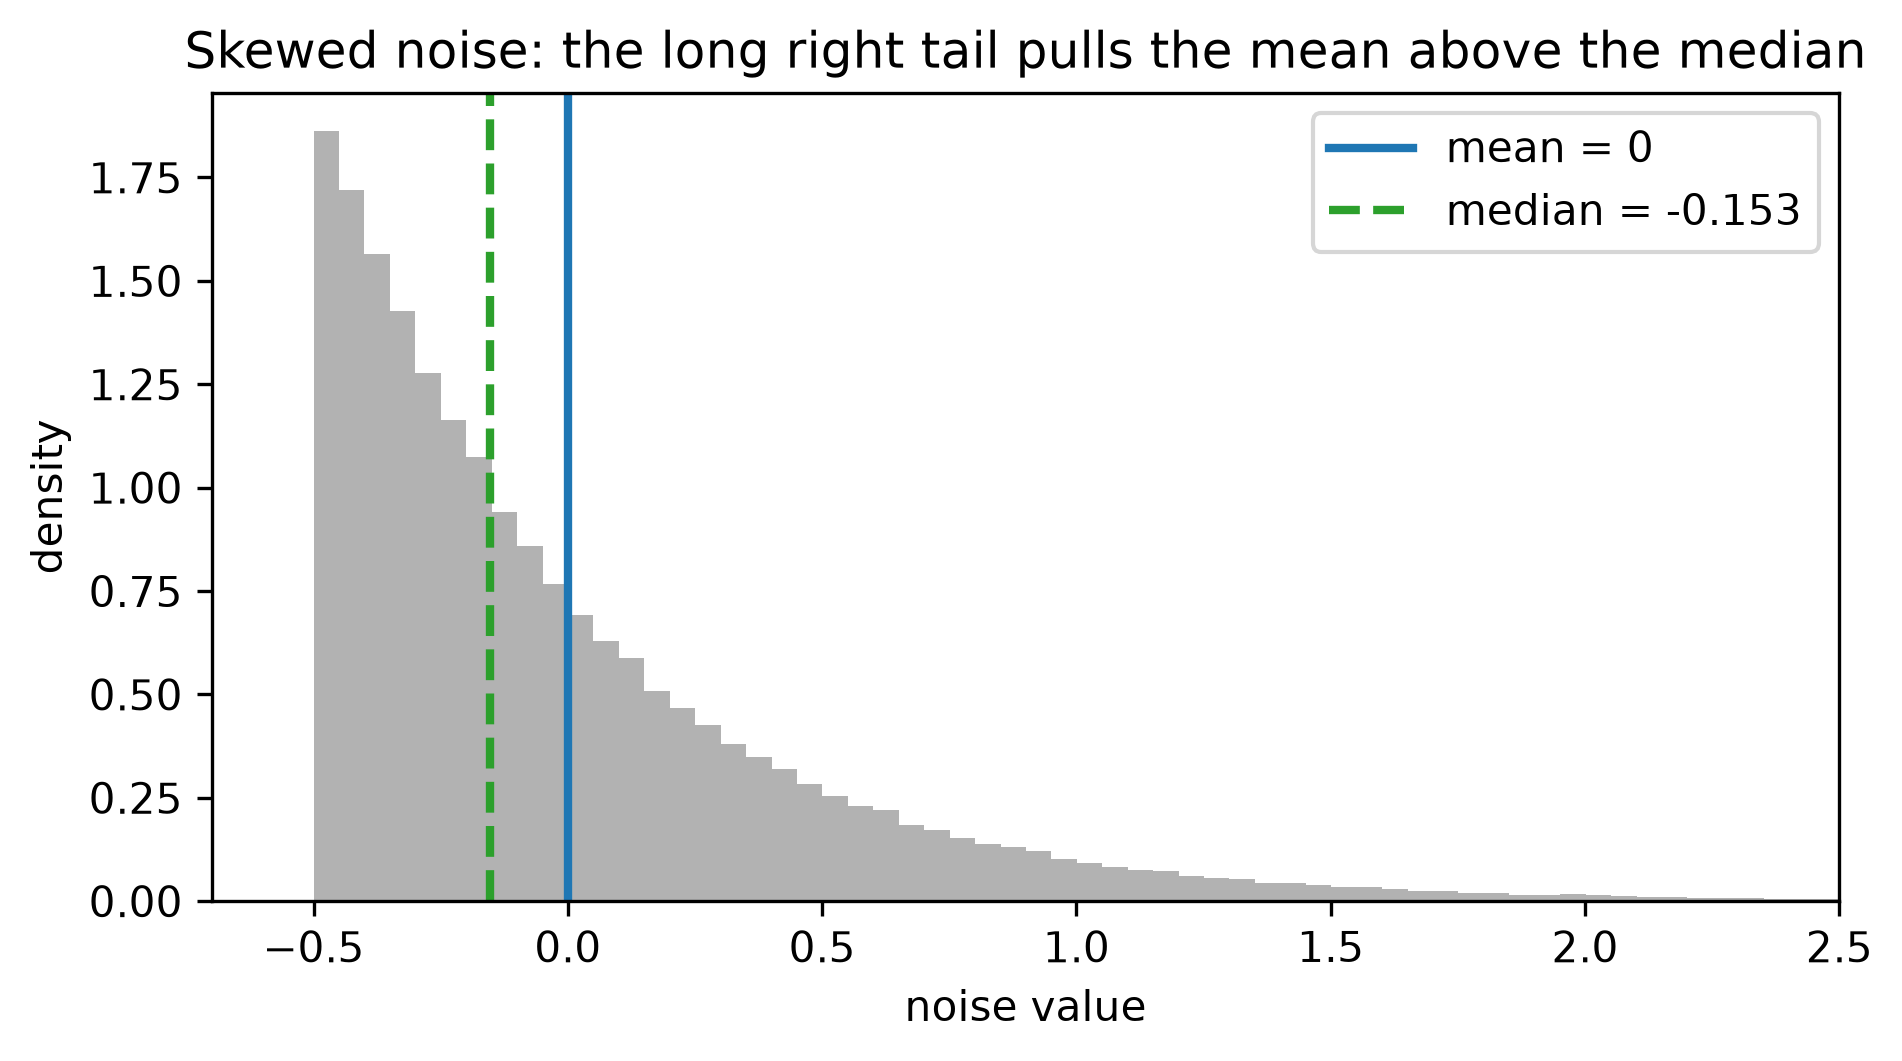

In [60]:
SKEW_SCALE = 0.5                                              # scale s of the exponential distribution
MEDIAN_SHIFT = SKEW_SCALE * np.log(2.0) - SKEW_SCALE          # median of the shifted noise: s ln2 - s


def skewed_noise(size):
    '''Noise with mean 0 and a long right tail: an exponential variable minus its own mean.'''
    return rng.exponential(scale=SKEW_SCALE, size=size) - SKEW_SCALE


noise_sample = skewed_noise(200_000)
print(f"skewed noise: mean = {noise_sample.mean():.4f}   median = {np.median(noise_sample):.4f}"
      f"   (theory: 0 and {MEDIAN_SHIFT:.4f})")

x_sk = rng.uniform(-1.0, 1.0, size=200_000)                   # inputs, as before
y_sk = f_true(x_sk) + skewed_noise(200_000)                   # outputs with skewed noise

candidates_sk = {
    "conditional mean   f(x)": f_true(x_sk),                    # E[Y | x], since the noise has mean 0
    "conditional median f(x) - 0.153": f_true(x_sk) + MEDIAN_SHIFT,   # median of Y given x
}

rows = []
for name, pred in candidates_sk.items():
    rows.append({"predictor": name,
                 "mean SQUARED error": np.mean((y_sk - pred) ** 2),
                 "mean ABSOLUTE error": np.mean(np.abs(y_sk - pred))})
print()
print(pd.DataFrame(rows).set_index("predictor").round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(noise_sample, bins=120, density=True, color="tab:grey", alpha=0.6)
ax.axvline(0.0, color="tab:blue", lw=2, label="mean = 0")
ax.axvline(MEDIAN_SHIFT, color="tab:green", lw=2, ls="--", label=f"median = {MEDIAN_SHIFT:.3f}")
ax.set_xlim(-0.7, 2.5)
ax.set_xlabel("noise value")
ax.set_ylabel("density")
ax.set_title("Skewed noise: the long right tail pulls the mean above the median")
ax.legend()
plt.show()

**Line by line**

- `rng.exponential(scale=0.5, size=...)` : draws from the exponential distribution, which is never negative
  and has a long tail to the right. Subtracting the scale (its mean) centres it at zero.
- `np.median(...)` : the middle value once the numbers are sorted: half the values are below it, half above.
- The two candidates are the true conditional mean and the true conditional median of $Y$ given $x$. They
  differ by the constant 0.153 at every $x$.
- `np.abs(y_sk - pred)` : the absolute error, the size of the miss without its sign.

**Reading the output.** The table has a crossing pattern:

- Under **squared** error, the conditional **mean** wins.
- Under **absolute** error, the conditional **median** wins.

Neither predictor is "better" in general. **The loss function defines the target**, and decision theory turns
the loss into the rule: squared loss asks for the mean, absolute loss for the median, 0–1 loss (Part 1) for the
most probable class. When you choose a loss for a real problem you are choosing which of these your model will
try to estimate.

The histogram shows why the two differ: most of the noise is small and negative, but occasional large positive
values pull the average to the right of the middle value. Squared error punishes those large misses heavily,
so it prefers a prediction nearer to them; absolute error treats all misses proportionally, so it settles on
the middle.

### 4e. Estimating E[Y | X] from data: a first look at the trade-off

In real life we cannot compute $f$; we only have a sample. The simplest way to estimate a conditional mean
from data follows directly from its definition: **chop the x-axis into bins and average the $y$ values inside
each bin.** This is the histogram idea from Practical 2, applied to $y$ instead of counts.

How many bins? Try three choices on the same sample of 300 points.

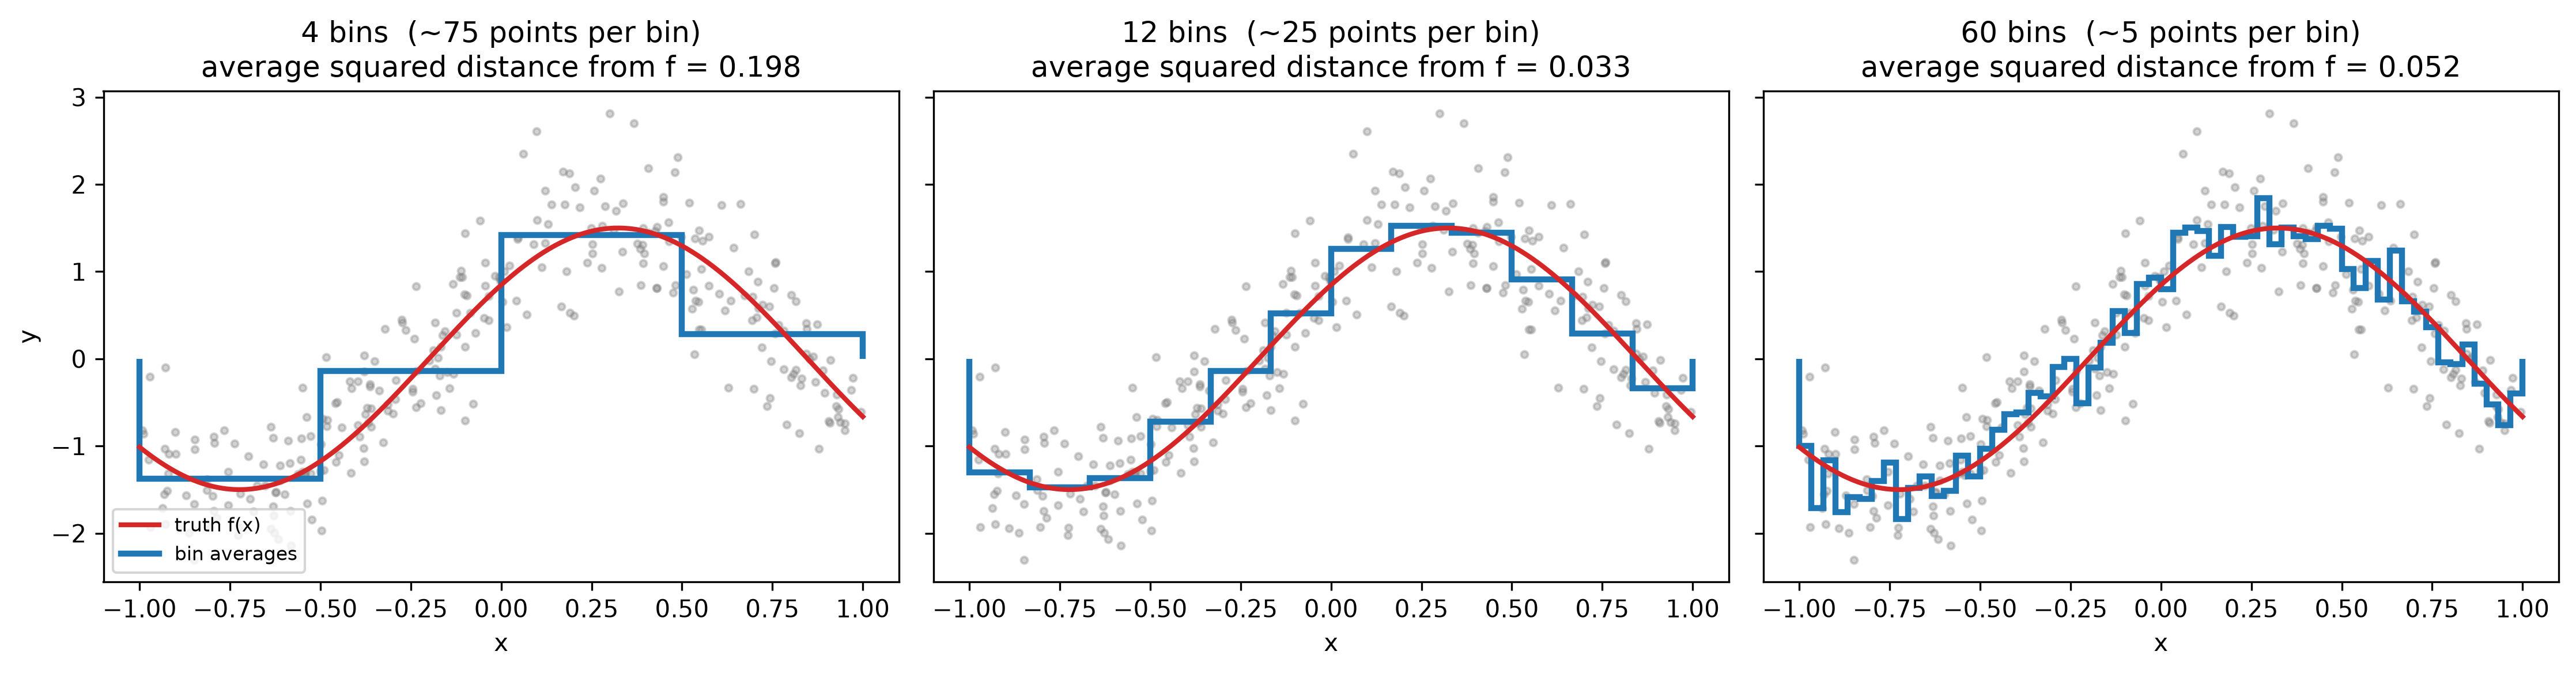

In [61]:
def bin_average_fit(x, y, n_bins):
    '''Estimate E[Y | X] by averaging y inside n_bins equal-width bins on [-1, 1].'''
    edges = np.linspace(-1.0, 1.0, n_bins + 1)                        # bin boundaries
    which = np.clip(np.digitize(x, edges) - 1, 0, n_bins - 1)         # the bin number of every point
    means = np.array([y[which == b].mean() if np.any(which == b)      # average y in each bin ...
                      else np.nan                                     # ... or NaN if the bin is empty
                      for b in range(n_bins)])
    return edges, means


def bin_average_predict(x, edges, means):
    '''Prediction of a binned estimate: the mean of whichever bin x falls into.'''
    which = np.clip(np.digitize(x, edges) - 1, 0, len(means) - 1)
    return means[which]


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, n_bins in zip(axes, [4, 12, 60]):
    edges, means = bin_average_fit(x_reg, y_reg, n_bins)             # fit on the 300-point sample
    err = np.nanmean((bin_average_predict(x_line, edges, means) - f_true(x_line)) ** 2)   # distance from f

    ax.scatter(x_reg, y_reg, s=8, alpha=0.35, color="tab:grey")
    ax.plot(x_line, f_true(x_line), color="tab:red", lw=2, label="truth f(x)")
    ax.stairs(means, edges, color="tab:blue", lw=2.5, label="bin averages")
    ax.set_title(f"{n_bins} bins  (~{300 // n_bins} points per bin)\n"
                 f"average squared distance from f = {err:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

**Line by line**

- `np.digitize(x, edges)` : for every value in `x`, returns the position of the first edge that is larger than
  it. Subtracting 1 turns that into a bin number starting from 0.
- `np.clip(..., 0, n_bins - 1)` : a point at exactly $x = 1.0$ would get bin number `n_bins`, one past the
  end; clipping puts it into the last bin.
- `y[which == b].mean() if np.any(which == b) else np.nan` : the average of the $y$ values in bin `b`. With many
  narrow bins a bin can be empty by bad luck, and the mean of nothing is undefined, so we store `np.nan`
  ("not a number") instead of crashing.
- `np.nanmean(...)` : an average that skips any `nan` values.
- `ax.stairs(values, edges)` : draws a piecewise-constant "staircase", one flat step per bin. It is the natural
  way to draw a binned estimate.
- `300 // n_bins` : `//` is integer division, giving the typical number of points per bin.

**Reading the three panels.** This is the most important picture before Part 5.

- **4 bins**: the steps are far too wide to follow the wave. Each step averages over a stretch where $f$ changes
  a lot, so the estimate is systematically wrong: badly off near the bin edges, where $f$ is rising or falling
  steeply, and the flat steps shave the top off the peak and the bottom off the trough. Collecting more data
  would not help, because the steps would still be too wide. **High bias.**
- **60 bins**: the steps are narrow enough to follow any shape, but each one averages only about 5 noisy
  points, so the staircase jumps up and down randomly. A different sample of 300 points would give a
  completely different staircase. **High variance.**
- **12 bins**: wide enough to average away much of the noise, narrow enough to follow the wave. The smallest
  distance from the truth of the three.

The number of bins is a **complexity knob**, just like $k$ in k-NN. Turning it one way trades bias for variance;
turning it the other way trades variance for bias. Part 5 measures that trade exactly, for polynomial models.

---
## Part 5: The bias–variance trade-off

### 5a. Three sources of error

Part 4 showed that the best possible predictor is $f(x) = E[Y \mid X = x]$ and that its error is $\sigma^2$. A
trained model $\hat{f}_D$ is learned from one particular training set $D$, and it will not be exactly $f$.
**Had we been given a different training set, we would have got a different model.** So the trained model is
itself random, and its expected squared error at a point $x$, averaged over training sets *and* over the noise
in the test label, splits into three pieces:

$$\underbrace{E_{D,\,\varepsilon}\big[(Y - \hat{f}_D(x))^2\big]}_{\text{expected test error}} = \underbrace{\sigma^2}_{\text{irreducible error}} + \underbrace{\big(\bar{f}(x) - f(x)\big)^2}_{\text{bias}^2} + \underbrace{E_D\big[(\hat{f}_D(x) - \bar{f}(x))^2\big]}_{\text{variance}}$$

where $\bar{f}(x) = E_D[\hat{f}_D(x)]$ is the **average model**: the prediction at $x$ averaged over all the
training sets we might have been given. (The derivation is the add-and-subtract trick from 4b, used twice.)

| term | question it answers | caused by | reduced by |
|---|---|---|---|
| **irreducible error** $\sigma^2$ | how noisy is the world? | the data itself | nothing: not more data, not a better model |
| **bias²** | if I could average my model over every possible training set, how wrong would it *still* be? | a model family too simple to represent $f$ | a more flexible model |
| **variance** | how much does my model change when the training set changes? | a model family so flexible that it fits the noise | a simpler model, or more data |

**The trade-off.** Making a model more flexible lowers its bias but raises its variance. Making it simpler
does the opposite. The total error is smallest somewhere in between, and finding that "somewhere" is what
model selection is about.

The classic picture is a dartboard. The bullseye is the truth $f(x)$. Each dart is the prediction of a model
trained on a different dataset. Bias is how far the *centre of the cluster* is from the bullseye; variance is
how *spread out* the cluster is.

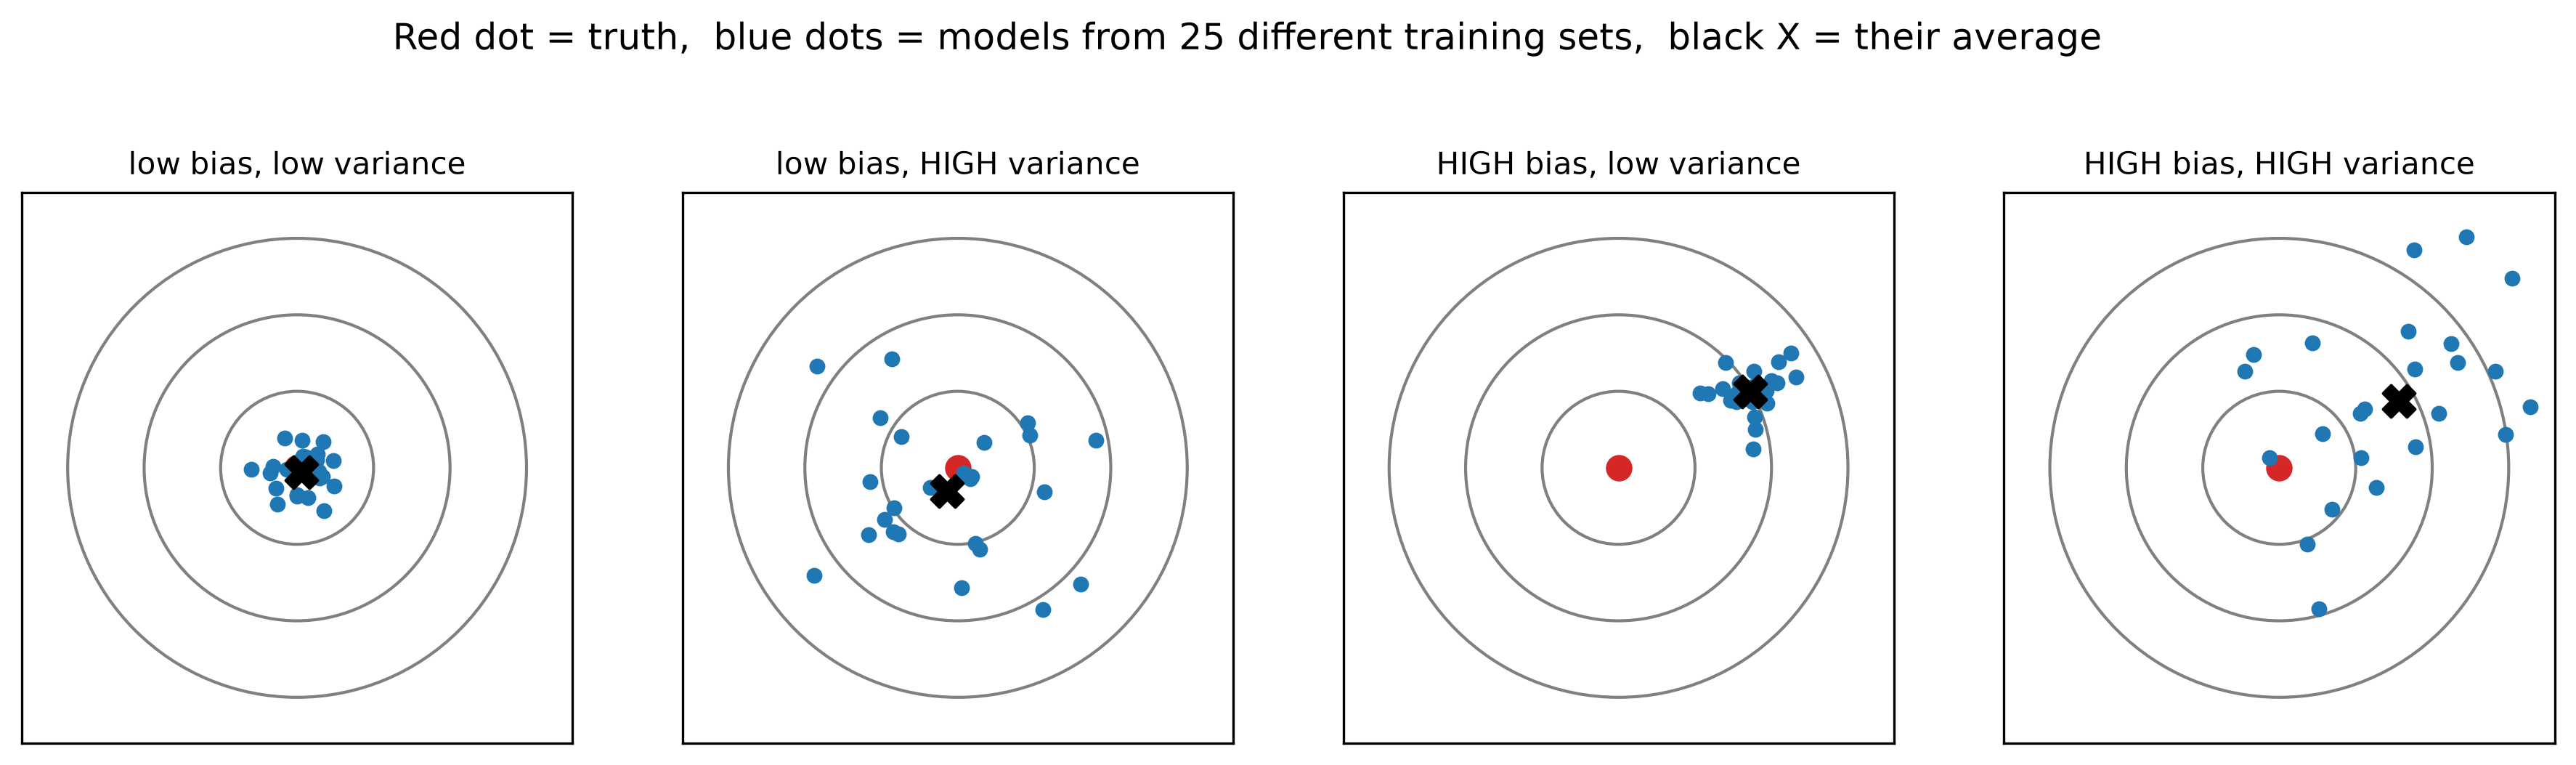

In [62]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
settings = [("low bias, low variance", 0.0, 0.15),        # (title, offset of the cluster, spread of the cluster)
            ("low bias, HIGH variance", 0.0, 0.55),
            ("HIGH bias, low variance", 0.9, 0.15),
            ("HIGH bias, HIGH variance", 0.9, 0.55)]

for ax, (title, offset, spread) in zip(axes, settings):
    for radius in (1.5, 1.0, 0.5):                                    # three rings of the dartboard
        ax.add_patch(plt.Circle((0, 0), radius, fill=False, color="grey"))
    ax.scatter([0], [0], color="tab:red", s=60, zorder=3)             # the bullseye: the truth f(x)
    darts = rng.normal(loc=[offset, offset * 0.6], scale=spread, size=(25, 2))   # 25 trained models
    ax.scatter(darts[:, 0], darts[:, 1], color="tab:blue", s=18, zorder=4)
    centre = darts.mean(axis=0)                                       # the average model f_bar(x)
    ax.scatter(*centre, marker="X", color="black", s=110, zorder=5)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Red dot = truth,  blue dots = models from 25 different training sets,  black X = their average",
             y=1.02)
plt.show()

**Line by line**

- `settings` : four combinations of two numbers, how far the cluster's centre is shifted from the bullseye
  (bias) and how spread out the cluster is (variance).
- `plt.Circle((0, 0), radius, fill=False)` creates a circle and `ax.add_patch(...)` draws it; three of them
  make the rings.
- `rng.normal(loc=[offset, offset * 0.6], scale=spread, size=(25, 2))` : 25 random 2-D points around a centre.
  Each point plays the role of one trained model's prediction.
- `darts.mean(axis=0)` : the average of the 25 darts, the black X. It stands for the average model
  $\bar{f}(x)$.
- `ax.set_xticks([])` : hides the tick marks; the numbers on the axes mean nothing here.

**Reading the picture.** Bias is the distance from the red dot to the black X. Variance is how far the blue
dots scatter around the black X. A model can be wrong in either way, or both. The good news: the two are
measured separately, and we are about to measure both for real models.

### 5b. The experiment

To *measure* bias and variance we need many training sets from the same world. Since we control the world,
we can simply draw them.

- **The model family:** polynomials of degree $0, 1, 2, \dots, 15$, fitted by least squares. A polynomial of
  degree $p$ has $p + 1$ weights, so the degree is our **complexity knob**. As Practical 1 explained, fitting a
  polynomial is still *linear* regression: the columns $1, x, x^2, \dots, x^p$ are a **basis expansion** and the
  model stays linear in the weights.
- **Each training set:** $n = 20$ points. The $x$ positions are the same 20 evenly spaced points every time;
  only the noisy $y$ values are redrawn. Every training set is a fresh sample from the same world, but the
  comparison between degrees is not muddied by some training sets happening to have no points near the edges.
  (What happens when the $x$ positions are random too is part of Exercise 4.)
- **Repeats:** 500 training sets for every degree.
- **Evaluation:** every fitted curve is evaluated on a fine grid of 201 points across $[-1, 1]$, where we know
  the truth $f$. Bias² and variance are computed at each grid point and averaged over the grid.

In [63]:
N_TRAIN = 20                                          # points in every training set
X_TRAIN_FIXED = np.linspace(-1.0, 1.0, N_TRAIN)       # the SAME 20 x positions in every training set
X_EVAL = np.linspace(-1.0, 1.0, 201)                  # where every fitted model is evaluated
F_EVAL = f_true(X_EVAL)                               # the truth at those points


def draw_training_set(x_train=X_TRAIN_FIXED, noise_sd=NOISE_SD):
    '''One fresh training set: the given x positions with brand-new noisy y values.'''
    return f_true(x_train) + rng.normal(0.0, noise_sd, size=len(x_train))


def poly_features(x, degree):
    '''Basis expansion (Practical 1): the columns 1, x, x^2, ..., x^degree.'''
    return np.vander(x, degree + 1, increasing=True)


def fit_poly(x, y, degree):
    '''Least-squares polynomial fit. Returns the weight vector w, of length degree + 1.'''
    Phi = poly_features(x, degree)                    # (n, degree + 1) design matrix
    w, *_ = np.linalg.lstsq(Phi, y, rcond=None)       # the least-squares weights
    return w


def predict_poly(x, w):
    '''Evaluate the fitted polynomial with weights w at the points x.'''
    return poly_features(x, len(w) - 1) @ w           # (m, degree + 1) @ (degree + 1,) -> (m,)


print("poly_features of x = [0.5, 2.0] up to degree 3:")
print(poly_features(np.array([0.5, 2.0]), 3))

y_example = draw_training_set()                       # one training set, to check the functions work
w_example = fit_poly(X_TRAIN_FIXED, y_example, 3)
print("\ncubic fitted to one training set, weights w0..w3:", w_example.round(3))

poly_features of x = [0.5, 2.0] up to degree 3:
[[1.    0.5   0.25  0.125]
 [1.    2.    4.    8.   ]]

cubic fitted to one training set, weights w0..w3: [ 0.578  3.486 -1.839 -3.487]


**Line by line**

- `X_TRAIN_FIXED = np.linspace(-1.0, 1.0, 20)` : the 20 input positions shared by every training set.
- `draw_training_set` : **one resample of the data**. It evaluates the truth at the fixed inputs and adds
  brand-new noise. Calling it twice gives two different training sets from the same world.
- `np.vander(x, degree + 1, increasing=True)` : builds the **Vandermonde matrix**, whose columns are
  $x^0, x^1, \dots, x^{\text{degree}}$. The printed example shows it for two points: row `[1, 0.5, 0.25, 0.125]`
  is $0.5$ raised to the powers 0, 1, 2, 3. This is exactly the design matrix $\Phi$ of Practical 1, with
  powers of $x$ as the features.
- `np.linalg.lstsq(Phi, y, rcond=None)` : the least-squares solution, the same function used in Practical 1,
  part 3f. It is preferred to solving the normal equations directly because high-degree Vandermonde matrices are
  badly conditioned (their columns look very alike). `lstsq` returns four things; `w, *_ = ...` keeps the first
  (the weights) and throws the other three away.
- `len(w) - 1` : a polynomial with `len(w)` weights has degree `len(w) - 1`, so `predict_poly` can work out the
  degree by itself.

### 5c. Seeing bias and variance

Before computing any numbers, look at what the fitted curves do. For three degrees, fit the model to the
**same** 25 training sets and draw all 25 curves, together with their average and the truth.

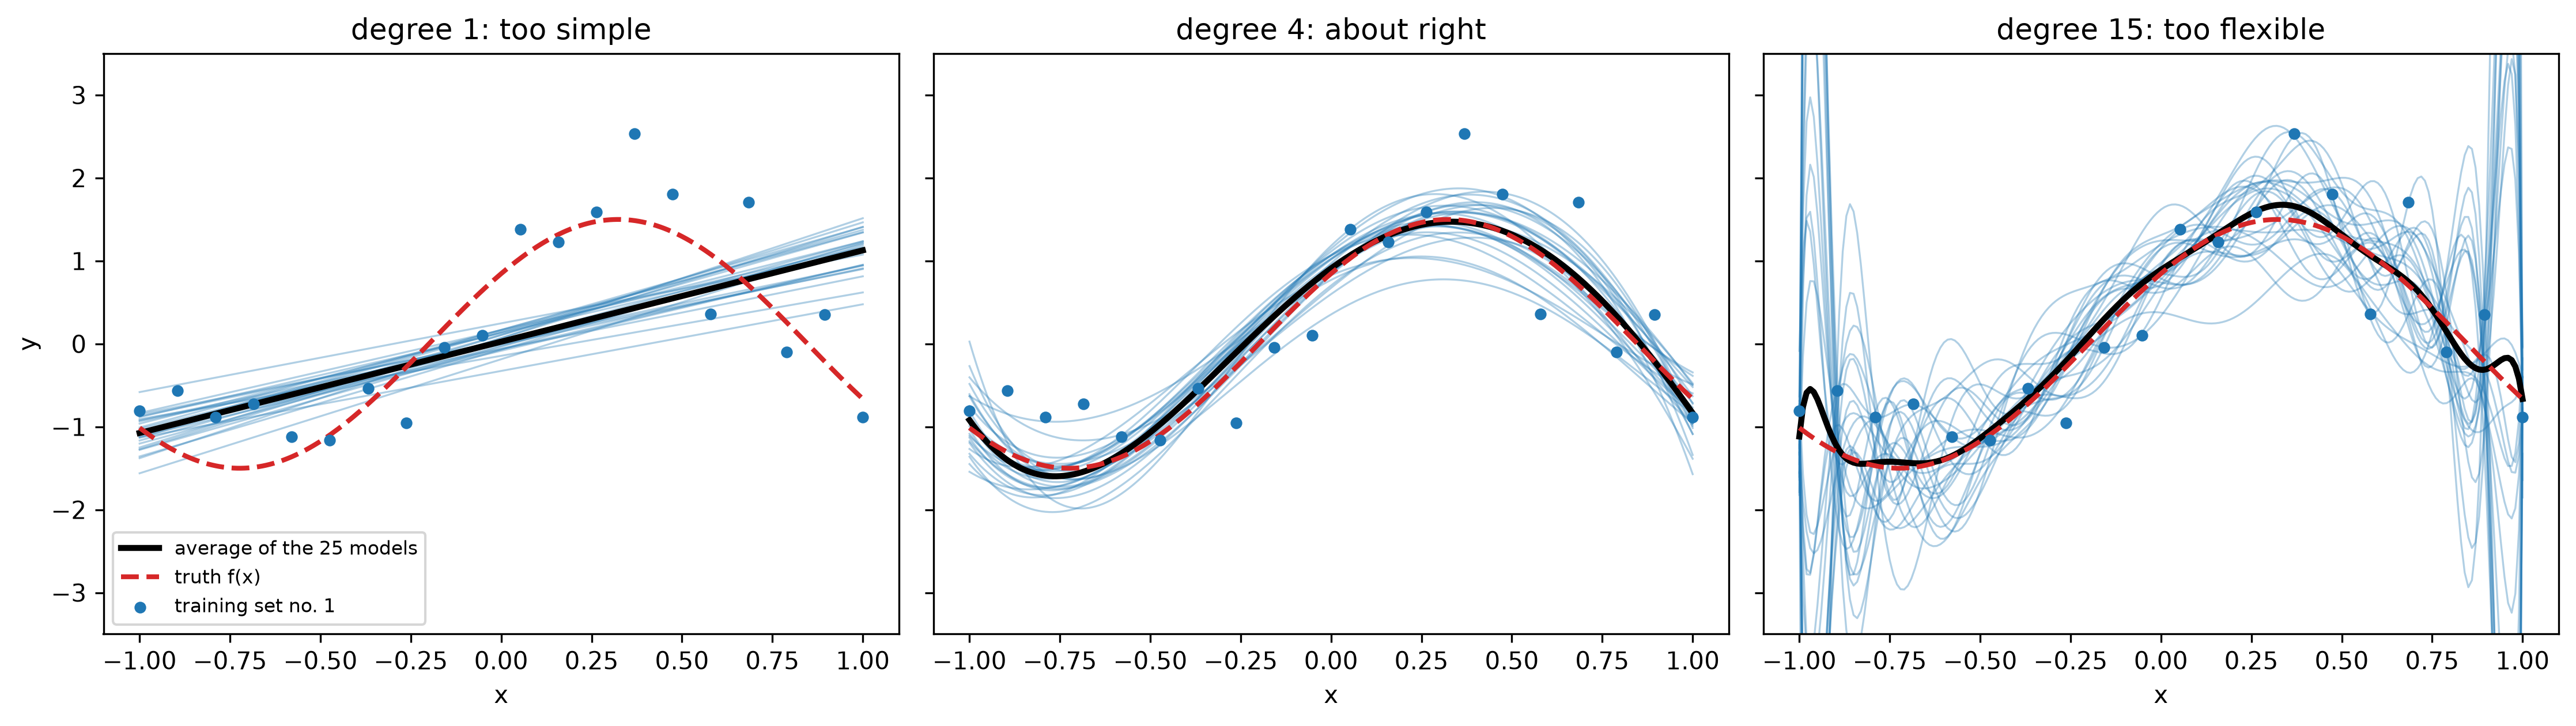

In [64]:
datasets = [draw_training_set() for _ in range(25)]          # 25 training sets, shared by all panels

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, degree, label in zip(axes, [1, 4, 15], ["too simple", "about right", "too flexible"]):
    curves = np.array([predict_poly(X_EVAL, fit_poly(X_TRAIN_FIXED, y_d, degree))    # one curve per dataset
                       for y_d in datasets])                                         # shape (25, 201)
    for curve in curves:
        ax.plot(X_EVAL, curve, color="tab:blue", lw=0.8, alpha=0.35)                 # thin: individual models
    ax.plot(X_EVAL, curves.mean(axis=0), color="black", lw=2.5, label="average of the 25 models")
    ax.plot(X_EVAL, F_EVAL, color="tab:red", lw=2, ls="--", label="truth f(x)")
    ax.scatter(X_TRAIN_FIXED, datasets[0], color="tab:blue", s=15, zorder=3, label="training set no. 1")
    ax.set_ylim(-3.5, 3.5)
    ax.set_title(f"degree {degree}: {label}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

**Line by line**

- `datasets = [draw_training_set() for _ in range(25)]` : 25 resamples of the data, drawn once so that all three
  panels are fitted to exactly the same training sets. The underscore `_` is the conventional name for a loop
  variable we do not use.
- The inner list comprehension fits one polynomial per dataset and evaluates it on the grid, giving a
  `(25, 201)` array: one row per fitted curve.
- `curves.mean(axis=0)` : averages *down the rows*, giving one value per grid point. That black curve is the
  estimate of the average model $\bar{f}(x)$.
- `ax.set_ylim(-3.5, 3.5)` : fixes the vertical range. The degree-15 curves shoot far outside it near the edges;
  without the limit they would squash everything else flat.

**Reading the three panels.** This is the bias–variance trade-off in one picture.

- **Degree 1** (a straight line): the 25 blue lines are close together, so **low variance**, but their average,
  the black line, is nowhere near the red wave, so **high bias**. Every training set gives almost the same
  wrong answer.
- **Degree 4**: the blue curves hug the truth and their average lies almost exactly on it. **Low bias, and still
  modest variance.**
- **Degree 15**: the *average* of the curves is close to the truth, so **low bias**, but the individual curves
  are wild, especially near the edges, and each one is very different from the next. **Huge variance.** A
  degree-15 polynomial has 16 weights and only 20 points to fit, so it bends to pass near every noisy point,
  and the noise is different every time. (The black average still wobbles near the edges. That is because we
  averaged only 25 extremely wild curves, so even their average is noisy; averaged over 500 curves, as in 5d,
  the wobble shrinks away.)

### 5d. Measuring bias², variance and noise

Now the numbers. For each degree, the function below draws 500 training sets, fits a polynomial to each, stores
all 500 fitted curves in an array `preds` of shape `(500, 201)`, and then reads the decomposition straight off
that array:

- **average model** $\bar{f}(x)$ = the mean of `preds` down its rows,
- **bias²** = $\big(\bar{f}(x) - f(x)\big)^2$, averaged over the 201 grid points,
- **variance** = the variance of `preds` down its rows, averaged over the 201 grid points,
- **noise** = $\sigma^2 = 0.25$, known exactly because we chose it.

As an independent check it also measures the **test error directly**: for each fitted model it draws fresh
noisy labels at the grid points and computes the mean squared error. If the decomposition is right, this
measured error must equal bias² + variance + noise.

In [65]:
def bias_variance_table(degrees, x_train=X_TRAIN_FIXED, noise_sd=NOISE_SD, n_repeats=500):
    '''Estimate bias^2, variance, noise and the test error of polynomial models of each degree.'''
    rows = []
    for degree in degrees:
        preds = np.empty((n_repeats, len(X_EVAL)))      # row r = predictions of the model fitted to dataset r
        train_mse = np.empty(n_repeats)                 # training error of each fitted model
        test_mse = np.empty(n_repeats)                  # error of each fitted model on fresh noisy labels

        for r in range(n_repeats):
            y_tr = draw_training_set(x_train, noise_sd)                     # a brand-new training set
            w = fit_poly(x_train, y_tr, degree)                             # fit the model to it
            preds[r] = predict_poly(X_EVAL, w)                              # its predictions on the grid
            train_mse[r] = np.mean((predict_poly(x_train, w) - y_tr) ** 2)  # error on its own training data
            y_new = F_EVAL + rng.normal(0.0, noise_sd, size=len(X_EVAL))    # fresh test labels at the grid
            test_mse[r] = np.mean((preds[r] - y_new) ** 2)                  # error on data it never saw

        avg_pred = preds.mean(axis=0)                                       # the average model f_bar(x)
        rows.append({
            "degree": degree,
            "bias^2": np.mean((avg_pred - F_EVAL) ** 2),                    # (f_bar(x) - f(x))^2, averaged over x
            "variance": np.mean(preds.var(axis=0)),                         # spread across datasets, averaged over x
            "noise": noise_sd ** 2,                                         # sigma^2: the irreducible error
            "measured test error": test_mse.mean(),                         # the direct measurement
            "training error": train_mse.mean(),
        })

    table = pd.DataFrame(rows).set_index("degree")
    table.insert(3, "bias^2 + variance + noise",                            # the decomposition, added up
                 table["bias^2"] + table["variance"] + table["noise"])
    return table


DEGREES = list(range(0, 16))                          # degrees 0, 1, ..., 15
bv = bias_variance_table(DEGREES)
bv

,bias^2,variance,noise,bias^2 + variance + noise,measured test error,training error
degree,,,,,,
0,1.1423,0.0113,0.25,1.4036,1.4004,1.3595
1,0.6099,0.0238,0.25,0.8837,0.8820,0.8982
2,0.2874,0.0335,0.25,0.5709,0.5703,0.5347
3,0.0284,0.0424,0.25,0.3207,0.3236,0.2330
4,0.0053,0.0536,0.25,0.3089,0.3092,0.1962
5,0.0003,0.0654,0.25,0.3157,0.3155,0.1706
6,0.0003,0.0746,0.25,0.3249,0.3239,0.1617
7,0.0002,0.0902,0.25,0.3404,0.3397,0.1525
8,0.0002,0.1012,0.25,0.3514,0.3495,0.1335


**Line by line**

- `preds = np.empty((n_repeats, len(X_EVAL)))` : a `(500, 201)` array that will hold every fitted curve. Row `r`
  is the model trained on training set `r`; column `j` is grid point `X_EVAL[j]`. **Reading down a column** shows
  how the prediction at one fixed $x$ changes from one training set to another, which is exactly what
  variance measures.
- Inside the loop, each repeat draws a new training set, fits, predicts on the grid, and records two errors:
  on its own training data, and on **fresh** labels `y_new` that it has never seen.
- `preds.mean(axis=0)` : `axis=0` collapses the rows (the datasets), leaving one average prediction per grid
  point: $\bar{f}(x)$ at 201 values of $x$.
- `np.mean((avg_pred - F_EVAL) ** 2)` : the squared distance between the average model and the truth at every
  grid point, averaged over the grid. That is bias².
- `preds.var(axis=0)` : the variance down each column, i.e. how much the prediction at that $x$ jumps around
  across the 500 training sets. Averaging over the grid gives one number per degree.
- `table.insert(3, name, values)` : adds a new column at position 3, right after the three ingredients, so the
  table reads left to right as "ingredients, their sum, the direct measurement".

**Reading the table.**

- **bias²** falls steeply from degree 0 to about degree 4 and is essentially zero from degree 5 on: a
  polynomial of degree 5 or more can represent this wave almost perfectly, *on average*.
- **variance** rises steadily with the degree, slowly at first and then very fast: from about 0.01 at degree 0
  to about 2.4 at degree 15.
- **noise** is 0.25 in every row. No choice of degree touches it.
- The column **bias² + variance + noise** and the column **measured test error** agree in every row, up to
  Monte Carlo noise. The decomposition is not just algebra on paper; it holds in the experiment.

**A small honest caveat.** The average model is computed from 500 curves rather than infinitely many, so it
carries a tiny bit of leftover randomness, and that leftover shows up inside the bias² column, adding roughly
variance / 500. At degree 15 that is about 0.005; everywhere else it is negligible.

In [66]:
gap = bv["measured test error"] - bv["bias^2 + variance + noise"]      # how well the decomposition adds up

print("measured test error  minus  (bias^2 + variance + noise), per degree:")
print(gap.round(4).to_string())
print(f"\nlargest relative gap : {np.max(np.abs(gap) / bv['measured test error']):.2%}")

best_degree = bv["measured test error"].idxmin()                       # the degree with the smallest test error
print(f"\nbest degree by measured test error : {best_degree}")
print(f"its test error                      : {bv.loc[best_degree, 'measured test error']:.4f}")
print(f"the floor (sigma^2)                 : {NOISE_VAR:.4f}")

measured test error  minus  (bias^2 + variance + noise), per degree:
degree
0    -0.0032
1    -0.0017
2    -0.0006
3     0.0029
4     0.0003
5    -0.0002
6    -0.0010
7    -0.0007
8    -0.0019
9     0.0015
10   -0.0023
11    0.0020
12   -0.0025
13    0.0040
14    0.0004
15    0.0044

largest relative gap : 0.89%

best degree by measured test error : 4
its test error                      : 0.3092
the floor (sigma^2)                 : 0.2500


**Line by line**

- `bv["measured test error"] - bv["bias^2 + variance + noise"]` : subtracting two columns of a DataFrame
  subtracts them row by row, giving one gap per degree.
- `.to_string()` : prints the whole Series without pandas' extra `Name:` and `dtype:` lines.
- `f"{value:.2%}"` : formats a fraction as a percentage with two decimals, so `0.0123` prints as `1.23%`.
- `.idxmin()` : the **index label** (here, the degree) of the smallest value in the column, not its position.
  For this table they happen to coincide, but `idxmin` is the one that always gives the degree.

**Reading the output.** The gaps are tiny, under one percent of the error, and have no pattern (some positive,
some negative): they are random noise from using 500 repeats rather than infinitely many. The best degree sits in the low single digits,
and even its test error stays above the floor of 0.25. That is expected: the best model still has *some*
variance, because 20 points is not much data.

### 5e. The picture: bias², variance and total error against complexity

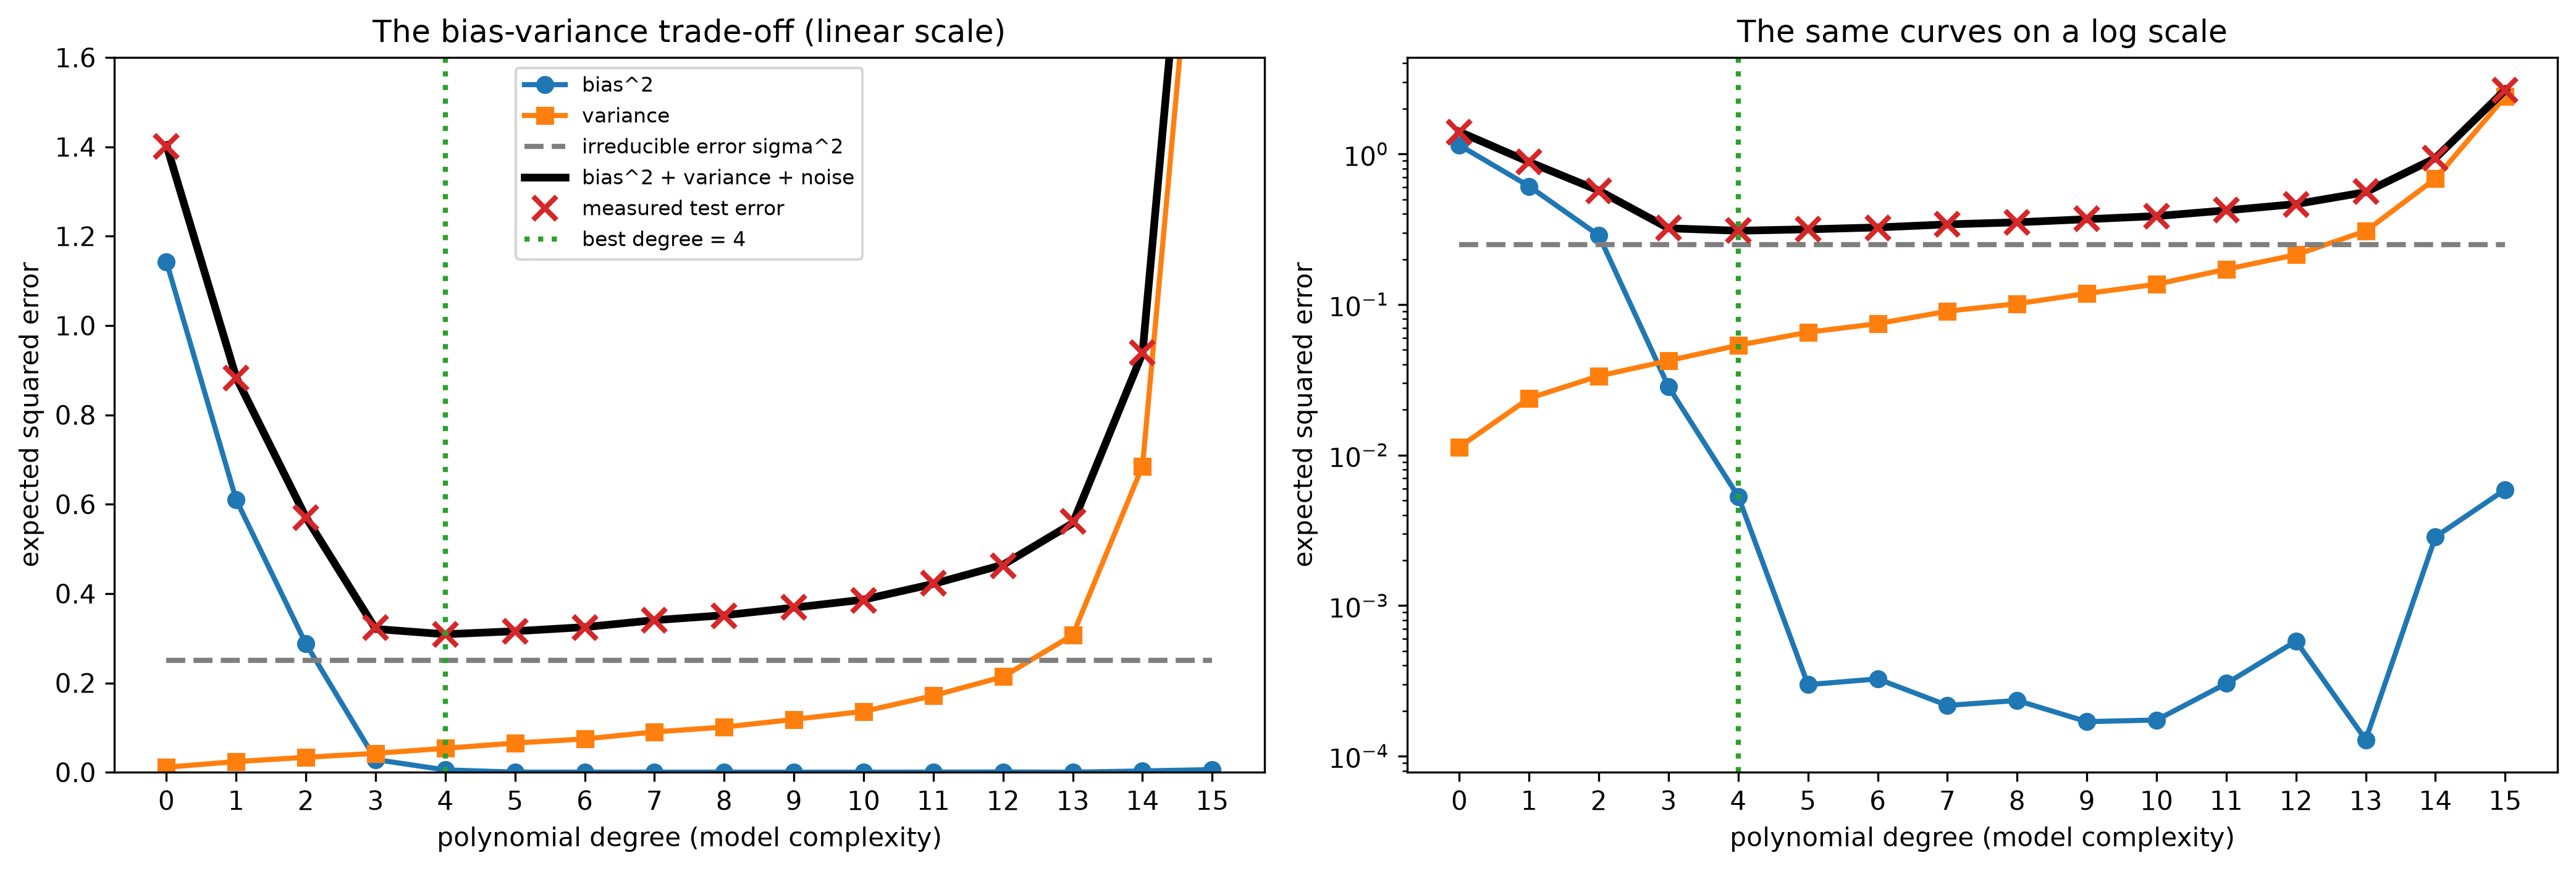

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for ax, log_scale in zip(axes, [False, True]):
    ax.plot(DEGREES, bv["bias^2"], "o-", color="tab:blue", lw=2, label="bias^2")
    ax.plot(DEGREES, bv["variance"], "s-", color="tab:orange", lw=2, label="variance")
    ax.plot(DEGREES, bv["noise"], "--", color="tab:grey", lw=2, label="irreducible error sigma^2")
    ax.plot(DEGREES, bv["bias^2 + variance + noise"], "-", color="black", lw=3,
            label="bias^2 + variance + noise")
    ax.plot(DEGREES, bv["measured test error"], "x", color="tab:red", ms=9, mew=2,
            label="measured test error")
    ax.axvline(best_degree, color="tab:green", ls=":", lw=2, label=f"best degree = {best_degree}")
    ax.set_xlabel("polynomial degree (model complexity)")
    ax.set_ylabel("expected squared error")
    ax.set_xticks(DEGREES)

axes[0].set_ylim(0, 1.6)                                    # linear scale, cut off so the U is visible
axes[0].set_title("The bias-variance trade-off (linear scale)")
axes[0].legend(fontsize=8, loc="upper center")
axes[1].set_yscale("log")                                   # log scale shows every curve in full
axes[1].set_title("The same curves on a log scale")

plt.tight_layout()
plt.show()

**Line by line**

- `zip(axes, [False, True])` : the same curves are drawn twice, once on each panel; the second panel then gets a
  log scale.
- `"o-"`, `"s-"`, `"--"`, `"x"` : format strings. A marker symbol (`o` circle, `s` square, `x` cross) and/or a line
  style (`-` solid, `--` dashed). The measured test error is drawn as crosses only, so you can see it landing on
  the black curve.
- `ms=9, mew=2` : marker size and marker edge width, to make the crosses stand out.
- `axes[0].set_ylim(0, 1.6)` : on a linear scale the variance at degree 15 (about 2.4) would squash everything
  else, so the left panel is cut off at 1.6.
- `axes[1].set_yscale("log")` : on a log scale equal *ratios* get equal space, so a curve going from 0.01 to 2.4
  and a curve going from 1.1 to almost 0 can be read on the same axes.

**Reading the plot.** This is the figure the whole practical has been building towards.

- The **blue** curve (bias²) comes down: more complex models can bend to follow the truth.
- The **orange** curve (variance) goes up: more complex models bend to follow the noise too.
- The **grey** line (noise) is flat: complexity is irrelevant to it.
- The **black** curve is their sum, and it is **U-shaped**. On the left, the total error is dominated by bias
  (underfitting); on the right, it is dominated by variance (overfitting). Its bottom, marked in green, is
  the best trade-off for this amount of data.
- The **red crosses**, measured directly on fresh data, land on the black curve at every degree.

**One thing the log scale exposes.** From degree 5 onwards the bias² curve looks bumpy, dips at 13 and climbs
at 14 and 15. Do not read anything into that: all of those values are below 0.006, and they are mostly the
leftover randomness described in the caveat of 5d (roughly variance / 500, which is why they grow exactly where
the variance grows). The true bias² for degrees 5 to 15 is essentially zero. A log scale magnifies tiny numbers,
noise included.

**The trade-off is not a law of nature about polynomials.** It is a statement about a model family *and* an
amount of data. With 200 training points instead of 20, the variance would be roughly ten times smaller at
every degree (more than that at the highest degrees), so the right-hand side of the U would flatten out and the
best degree would drift to the right. Exercise 4 lets you see this happen, and asks why it drifts less than you
might expect.

### 5f. Why the training error cannot find the bottom of the U

We measured the training error too. Plot it next to the test error.

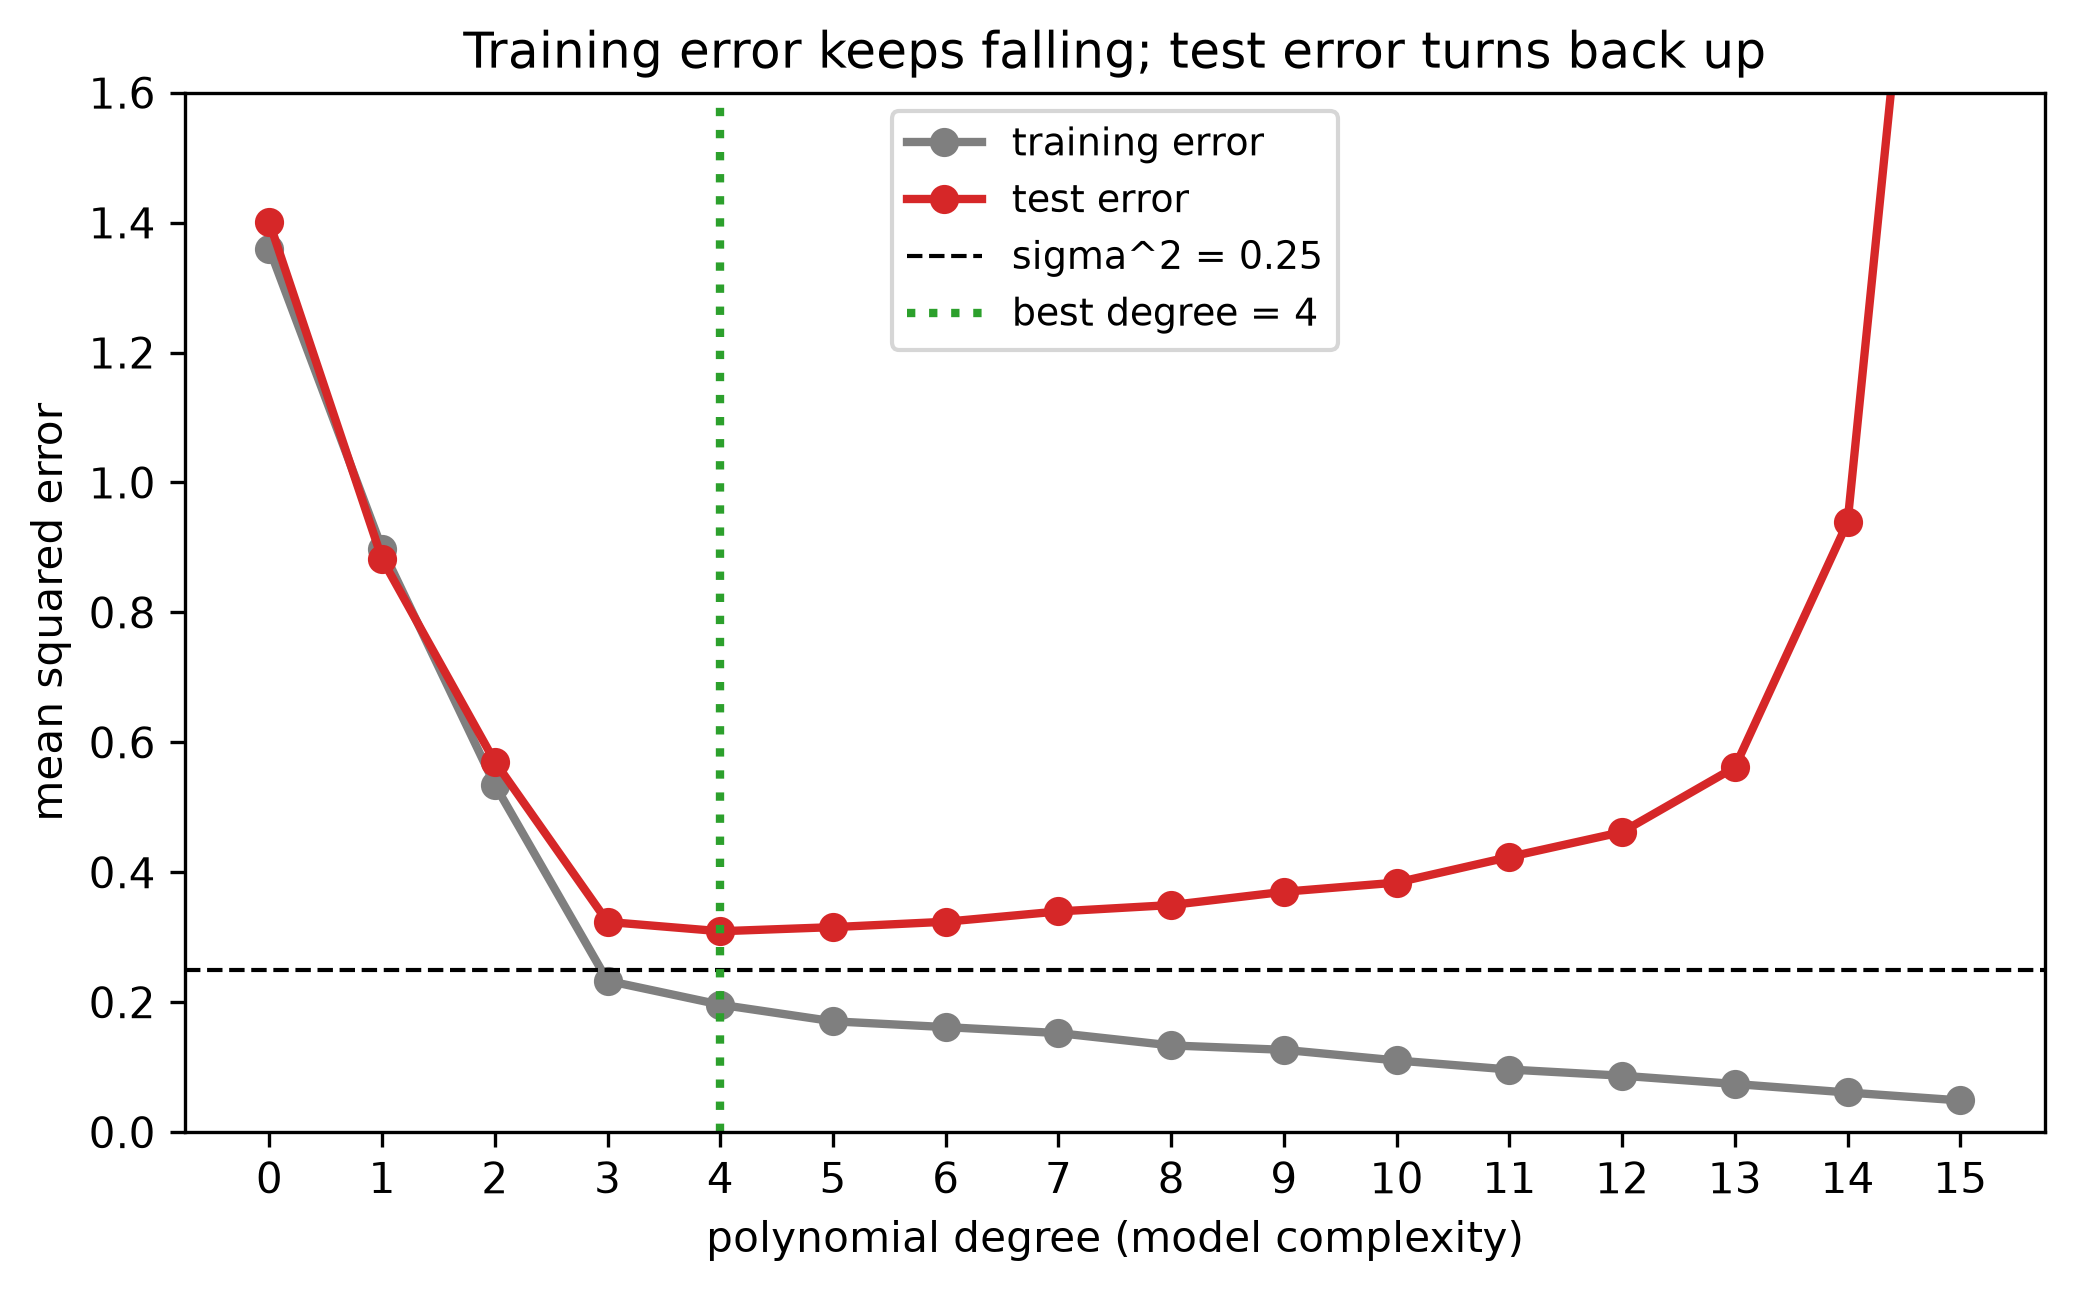

degree                   0       1       2       3       4       5       6       7       8       9       10      11      12      13      14      15
training error       1.3595  0.8982  0.5347  0.2330  0.1962  0.1706  0.1617  0.1525  0.1335  0.1267  0.1103  0.0964  0.0869  0.0741  0.0610  0.0488
measured test error  1.4004  0.8820  0.5703  0.3236  0.3092  0.3155  0.3239  0.3397  0.3495  0.3700  0.3841  0.4236  0.4620  0.5616  0.9386  2.6614


In [68]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(DEGREES, bv["training error"], "o-", color="tab:grey", lw=2, label="training error")
ax.plot(DEGREES, bv["measured test error"], "o-", color="tab:red", lw=2, label="test error")
ax.axhline(NOISE_VAR, color="black", ls="--", lw=1, label="sigma^2 = 0.25")
ax.axvline(best_degree, color="tab:green", ls=":", lw=2, label=f"best degree = {best_degree}")
ax.set_ylim(0, 1.6)
ax.set_xticks(DEGREES)
ax.set_xlabel("polynomial degree (model complexity)")
ax.set_ylabel("mean squared error")
ax.set_title("Training error keeps falling; test error turns back up")
ax.legend(fontsize=9)
plt.show()

print(bv[["training error", "measured test error"]].round(4).T.to_string())

**Line by line**

- The same kind of line plot as before, with the two error columns from the table.
- `bv[[...]]` : double brackets select several columns and return a smaller DataFrame. `.T` transposes it so the
  degrees run across the page and the output is compact.

**Reading the plot.**

- The **training error** goes down at *every* step, all the way to degree 15, and it drops **below** the noise
  floor of 0.25 from degree 3 onward. But no model can predict fresh data better than $\sigma^2$ (Part 4), so a
  training error below 0.25 is, once again, a sign of fitting noise. It is the regression version of k-NN with
  $k = 1$ scoring zero training error in Part 3.
- There is even a formula for how far below. Once a least-squares model is flexible enough to have no bias, its
  expected training error is $\sigma^2\big(1 - \frac{p+1}{n}\big)$ for a model with $p + 1$ weights fitted to
  $n$ points. At degree 15: $0.25 \times (1 - 16/20) = 0.05$, and the table shows 0.049. Every extra weight
  "absorbs" one more share of the noise, which makes the training error look better and the model worse.
- The **test error** follows the U from 5e.
- On the left the two curves are close together; on the right they separate dramatically. **The gap between
  training error and test error is the visible symptom of variance.**

Choosing the degree with the smallest training error would always choose the most complex model, the worst one
here. That is why every serious modelling workflow sets aside data the model has not seen (a test set, a
validation set, or cross-validation) to choose complexity. In this practical we could simply generate fresh
data; in real life you must hold some back.

---
## Summary

| concept | formula | code in this notebook | how we checked it |
|---|---|---|---|
| risk (expected loss) | $R(h) = E[L(Y, h(X))]$ | `conditional_risk(posterior, loss_matrix)` | smallest risk = most probable class |
| Bayes classifier | $h^*(x) = \arg\max_c P(c)\,p(x \mid c)$ with the **true** distributions | `bayes_classifier(X)` | no threshold or trained model beats it |
| Bayes threshold (1-D, equal variances) | $t^* = \frac{\mu_0+\mu_1}{2} + \frac{\sigma^2}{\mu_1-\mu_0}\ln\frac{P(0)}{P(1)}$ | `t_bayes` | brute-force search over 501 thresholds |
| Bayes error rate | $R^* = \int \min_c P(c)\,p(x \mid c)\,dx = E[1 - \max_c P(c \mid X)]$ | `bayes_error_by_integration`, counting, averaging the posterior | three methods agree |
| multivariate Gaussian | $\log p(x) = -\frac12\big(d\log 2\pi + \log\lvert\Sigma\rvert + (x-\mu)^\top\Sigma^{-1}(x-\mu)\big)$ | `log_mvn_pdf` | integrates to 1, matches 1-D formula |
| excess error | test error $- R^*$ = approximation + estimation | comparison table in 3f | plug-in → Bayes as $n$ grows; logistic plateaus |
| best regression predictor (squared loss) | $E[Y \mid X = x]$ | `f_true` | lowest MSE of all predictors, equal to $\sigma^2$ |
| error of any regression predictor | $E[(Y-g)^2] = \sigma^2 + E[(f - g)^2]$ | `regression_table` | two columns agree |
| best predictor under absolute loss | conditional median | Part 4d | mean wins squared loss, median wins absolute loss |
| bias–variance decomposition | test error $= \sigma^2 + \text{bias}^2 + \text{variance}$ | `bias_variance_table` | sum equals the directly measured test error |

**The one sentence version:** decision theory says the best possible prediction is the posterior's most probable
class under 0–1 loss and the conditional mean under squared loss, the error of that best prediction (the Bayes
error rate, or $\sigma^2$) is a floor no model can go below, and a trained model's extra error above the floor
splits into bias (too simple to reach the truth) and variance (too sensitive to the particular training set),
which complexity trades against each other.

**How this connects to the previous practicals.** Practical 1 fitted models by least squares, and even added
powers of a feature as a basis expansion, but had no way to say whether a better fit was a better model; this
practical shows that a lower training error can be a *worse* model, and why. Practical 2 built the MAP classifier
from estimated priors and likelihoods; this practical shows that the same rule with the *true* distributions is
the optimal classifier, the benchmark every estimated classifier is measured against. Along the way three
complexity knobs appeared (the number of neighbours $k$, the number of bins, and the polynomial degree), and they
all behave the same way.

---
# Exercises

Four exercises, roughly in order of difficulty. Write your code in the empty cell below each one. Every
exercise uses only functions and variables already defined above, so nothing new needs to be imported.

**Before you start, a habit worth keeping.** Whenever you compute an error rate or a mean squared error, ask
what the floor is. For classification it is the Bayes error rate, for regression it is $\sigma^2$. A result
below the floor on fresh data means there is a bug; a result below the floor on training data means the model
is fitting noise.

## Exercise 1: When mistakes have different costs

In many real problems the two kinds of mistake do not cost the same. Suppose that in the 2-D world of Part 3,
**missing a class-1 point (deciding 0 when the truth is 1) costs 5**, while a false alarm (deciding 1 when the
truth is 0) costs 1. Correct decisions cost 0.

1. Write down the new loss matrix `LOSS_COST` (row = truth, column = decision) and use `conditional_risk` to
   print the expected loss of both decisions for the posteriors $P(C=1 \mid x) \in \{0.05, 0.10, 0.15, 0.20,
   0.30, 0.50\}$. At which posterior value does the cheapest decision switch from 0 to 1?
2. Show on paper that under this loss the optimal rule is "decide 1 when $P(C=1 \mid x) > 1/6$". (Set the two
   expected losses equal and solve.) Check that your answer agrees with part 1.
3. Implement this **cost-sensitive Bayes classifier** using `scores_to_posterior` and `gaussian_class_scores`
   with the true parameters. Redraw the posterior plot of Part 3c with both boundaries on it: the 0.5 contour
   (0–1 loss) and the 1/6 contour (your new rule). Which way does the boundary move, and why?
4. On the test set, compute for **both** rules: the error rate (0–1 loss) and the **average cost** under
   `LOSS_COST`. Confirm that each rule wins on its own loss and loses on the other one's.
5. Write two or three sentences on a real situation (medical, financial, or anything you like) where you would
   choose the cost-sensitive rule even though it has a *higher* error rate.

*Hint for step 4:* the cost of one decision is `LOSS_COST[true_class, decision]`. With arrays of true classes
and decisions, `LOSS_COST[y_test, predictions]` gives all 50 000 costs at once (fancy indexing with two arrays).

In [69]:
# Your code for Exercise 1

## Exercise 2: When is a straight line good enough?

Logistic regression lost badly in Part 3 because the Bayes boundary was an ellipse. Build a world where that
excuse disappears.

1. Define a new world with the same `PRIORS` and `MEANS` but with **both classes sharing the same covariance
   matrix**, for example `COV_SHARED = np.array([[1.0, 0.3], [0.3, 1.0]])`, so `covs = [COV_SHARED, COV_SHARED]`.
   Generate a training set of 200 points and a test set of 50 000 points with `sample_world(..., covs=...)`.
2. Draw the Bayes decision boundary of the new world (the 0.5 contour of the true posterior). Confirm that it is
   a **straight line**, and explain in one or two sentences why the quadratic terms cancel when the covariance
   matrices are equal.
3. Compute the Bayes error rate of the new world with `bayes_error_by_integration` and check it by counting
   mistakes of `bayes_classifier(X, covs=...)` on the test set.
4. Train the plug-in Gaussian, logistic regression and k-NN with $k = 15$ on the new training set and build the
   same comparison table as in Part 3f. How big is logistic regression's excess error now? Compare it with the
   plug-in Gaussian's and explain the result using the words *approximation error* and *estimation error*.
5. Keep the shared covariance but move the class-1 mean along the line from $(0, 0)$ to $(3, 2)$ in 10 steps
   (for example `MEANS_k = [np.array([0.0, 0.0]), t * np.array([3.0, 2.0])]` for `t` from 0.1 to 1.0). Plot the
   Bayes error rate against the distance between the means. What happens to the Bayes error rate as the classes
   move apart, and what value does it approach when the two means coincide?

*Hint for step 5:* when the two means are identical the features carry no information at all. Think about what
the best possible classifier does then, using only the prior.

In [70]:
# Your code for Exercise 2

## Exercise 3: Bias and variance from a single dataset, using the bootstrap

In Part 5 we drew 500 brand-new training sets from the world. In real life you get **one** dataset and that is
all. The **bootstrap** creates "new" training sets by resampling the one you have: draw $n$ points from it
**with replacement**, so some points appear twice and others not at all. Resampling whole $(x, y)$ pairs like
this imitates drawing a new dataset in which the $x$ values are random too, so this exercise uses random inputs
throughout.

1. Draw a single dataset of 100 points with random inputs: `x_one, y_one = sample_regression(100)`.
2. Create $B = 400$ bootstrap resamples: in each one, choose 100 indices with
   `rng.choice(100, size=100, replace=True)` and take those $x$ and $y$ values. Fit polynomials of degrees 0 to 8
   to each resample and evaluate them on `X_EVAL`. For each degree compute the **bootstrap variance**: the
   variance of the predictions across the 400 bootstrap fits, averaged over `X_EVAL`.
3. Compute the **true variance** for comparison: draw 400 brand-new datasets with `sample_regression(100)`, fit
   each degree to each, and compute the variance across those 400 fits in the same way. (This step is only
   possible because we control the world.) Plot the bootstrap variance and the true variance against degree on a
   log scale, on the same axes.
4. Does the bootstrap get the *shape* of the variance curve right? Does it get the *size* right? Repeat steps 1
   and 2 with two or three different single datasets and describe how much the answer depends on which dataset
   you happened to get.
5. Explain in a short paragraph why the bootstrap can estimate the **variance** but cannot estimate the
   **bias²** in real life. (What quantity does bias² need that you would not have?) What would you use instead to
   choose the degree in practice?

*Hint for steps 2 and 3:* the structure is exactly the `preds` array of `bias_variance_table`: a `(400, 201)`
array with one fitted curve per row, followed by `preds.var(axis=0).mean()`. Do not compare against
`bv["variance"]` from Part 5, which was computed with 20 **fixed** inputs; the comparison is only fair when both
sides use random inputs and the same $n$.

In [71]:
# Your code for Exercise 3

## Exercise 4: Moving the sweet spot

The bottom of the U in Part 5 is not a fixed property of the problem. Find out what moves it.

1. **More data.** Rerun the experiment with `x_train = np.linspace(-1, 1, n)` for $n = 20, 50, 200$ (use degrees
   0 to 15 and `n_repeats=300` to keep it quick). For each $n$ plot bias², variance and total error against
   degree, and report the best degree. How does the variance curve change with $n$? How does the bias² curve
   change? Where does the best degree go? It moves less than you might expect: look at the bias² column and
   explain why, for this particular $f$, no amount of data will push the best degree much beyond 5.
2. **More noise.** Keep $n = 20$ and rerun with `noise_sd = 0.2` and `noise_sd = 1.0`. Which of the three
   components changes, and by roughly what factor? Where does the best degree go?
3. **A different knob: ridge regularisation.** Fix the degree at 15 and control complexity with the ridge penalty
   of Practical 1 instead: write `fit_poly_ridge(x, y, degree, lam)` that solves
   $(\Phi^\top\Phi + \lambda I)\,w = \Phi^\top y$. Copy `bias_variance_table` into a new function that loops over
   `lam` values `np.logspace(-8, 2, 11)` instead of degrees. Plot bias², variance and total error against $\lambda$
   (log x-axis). Which end of the $\lambda$ axis is "complex" and which is "simple"?
4. **Random inputs.** Go back to the original setting, but draw new random inputs for every training set:
   `x_train = np.sort(rng.uniform(-1, 1, N_TRAIN))` inside the loop, for degrees 0 to 12. Compare the variance
   column with the fixed-design one from Part 5 (use a log scale; the numbers get very large). Where does the
   variance explode, and why? (Draw a few of the fitted curves and look at what happens where a random training
   set has *no* points, especially near $x = \pm 1$.)

*Hint for step 3:* the only change to `fit_poly` is one line:
`w = np.linalg.solve(Phi.T @ Phi + lam * np.eye(Phi.shape[1]), Phi.T @ y)`. For step 4 you need to move the line
that chooses `x_train` *inside* the `for r in range(n_repeats)` loop, since `bias_variance_table` as written reuses
the same `x_train` every time.

In [72]:
# Your code for Exercise 4